# Parte I — Redes Neurais Artificiais (MLP)
## Previsão de Cancelamento de Reservas Hoteleiras

**Tipo de problema:** classificação binária supervisionada
**Dataset:** *Hotel Booking Cancel* (Kaggle) — https://www.kaggle.com/datasets/willianoliveiragibin/hotel-booking-cancel/data

---

### Identificação da equipe

| # | Integrante | Análise de sensibilidade individual (Seção 9) |
|---|------------|-----------------------------------------------|
| 1 | *(preencher nome completo)* | **Taxa de aprendizagem** (`learning_rate`) |
| 2 | *(preencher nome completo)* | **Número de neurônios por camada** (`n_units`) |
| 3 | *(preencher nome completo)* | **Número de camadas ocultas** (`n_layers`) |

> **Preencher os nomes acima antes da entrega.** Cada análise de sensibilidade da Seção 9 está
> identificada com o integrante responsável por ela.

---

### Declaração de uso de Inteligência Artificial Generativa

Em conformidade com os princípios institucionais de transparência no uso de IA Generativa e com o
regulamento para uso acadêmico de IA:

| Item | Descrição |
|------|-----------|
| **Ferramenta utilizada** | Claude (Anthropic), utilizado como assistente de programação e de redação. |
| **Finalidade do uso** | Apoio na estruturação do notebook; geração de código instrumental e repetitivo (funções de plotagem, laços de validação cruzada, formatação de tabelas de resultados); revisão da redação dos textos em Markdown; sugestões de organização das seções. |
| **Extensão aproximada da contribuição** | Aproximadamente **40% do código** — concentrado em código instrumental (visualizações, formatação, estruturação de laços) — e **30% da redação** dos textos explicativos. As decisões metodológicas foram tomadas pela equipe: escolha do dataset, identificação e remoção do vazamento de dados, política de tratamento de duplicatas, definição da métrica principal, delimitação do espaço de busca de hiperparâmetros e interpretação dos resultados. |
| **Medidas adotadas para validação** | (i) execução integral do notebook, com conferência célula a célula das saídas; (ii) verificação manual das estatísticas descritivas e das dimensões dos conjuntos em cada etapa; (iii) checagem explícita de ausência de vazamento — o conjunto de teste não participa do `fit` do pré-processador nem de qualquer etapa de busca de hiperparâmetros (há uma célula de auditoria na Seção 4.6); (iv) sementes fixas garantindo reprodutibilidade; (v) confronto das conclusões obtidas com o conteúdo discutido em aula e com a literatura sobre o problema. |

---

## Sumário

| Seção | Conteúdo |
|-------|----------|
| 1 | Dataset escolhido e justificativa |
| 2 | Configuração do ambiente |
| 3 | Análise inicial dos dados (EDA) |
| 4 | Pré-processamento e separação do *holdout* |
| 5 | Métrica principal e estratégia de validação cruzada |
| 6 | Construção da MLP |
| 7 | **Baseline** — Random Search com validação cruzada |
| 8 | **Busca adaptativa** — TPE com Optuna |
| 9 | Análises individuais de sensibilidade de hiperparâmetros |
| 10 | Modelo final e avaliação no conjunto de teste |
| 11 | Discussão crítica e conclusões |

<a id="sec1"></a>
# 1. Dataset escolhido e justificativa

## 1.1 Ficha de identificação

| Campo | Valor |
|-------|-------|
| **Nome** | Hotel Booking Cancel |
| **Fonte** | Kaggle — `willianoliveiragibin/hotel-booking-cancel` |
| **Link** | https://www.kaggle.com/datasets/willianoliveiragibin/hotel-booking-cancel/data |
| **Tipo de problema** | Classificação binária |
| **Instâncias (arquivo bruto)** | 119.390 |
| **Atributos (arquivo bruto)** | 33 colunas = 32 preditores + 1 alvo |
| **Variável-alvo** | `is_canceled` |
| **Descrição do alvo** | Indica se a reserva foi **cancelada antes do check-in** (`1`) ou **honrada** (`0`) |
| **Número de classes** | 2 |
| **Distribuição bruta das classes** | `0` = 75.166 (62,96%) · `1` = 44.224 (37,04%) |

## 1.2 O que se pretende prever

A partir das características conhecidas **no momento em que a reserva é feita** — antecedência
(`lead_time`), canal de distribuição, segmento de mercado, política de depósito, perfil do hóspede,
tarifa média diária (`adr`), número de pedidos especiais, histórico de cancelamentos prévios etc. —
queremos **prever se aquela reserva será cancelada**.

É um problema de decisão *ex-ante*: o modelo deve funcionar no instante da reserva, o que impõe uma
restrição forte sobre quais colunas podem ser usadas (ver Seção 3.4 — vazamento de dados).

## 1.3 Justificativa da escolha

**Relevância prática.** O cancelamento é um dos principais problemas de receita da hotelaria. Um
modelo preditivo permite calibrar *overbooking*, ajustar políticas de depósito por perfil de risco
e acionar campanhas de retenção sobre as reservas de maior risco.

**Adequação à MLP.** São ~30 atributos mistos (contínuos, contagens e categóricos de cardinalidade
variada), com relações claramente **não lineares e com interações** entre variáveis — por exemplo,
o efeito da antecedência sobre o risco depende do segmento de mercado e da política de depósito.
Esse é justamente o cenário em que uma rede densa se justifica frente a um modelo linear.

**Volume adequado.** Cerca de 86 mil instâncias após a limpeza: suficiente para treinar uma rede
com regularização, executar validação cruzada e ainda reservar um *holdout* estatisticamente
robusto — tudo isso sem necessidade de GPU.

**Riqueza didática.** O dataset apresenta, em estado natural, praticamente todos os problemas de
preparação de dados vistos em aula: **vazamento de dados**, **atributos identificadores (PII)**,
**duplicatas**, **valores ausentes**, **alta cardinalidade categórica**, **escalas muito
diferentes** e **outliers extremos**. A etapa de pré-processamento é, portanto, substantiva.

**Conformidade com as restrições da atividade.** Não é Iris, Fashion-MNIST, DryBean, MNIST,
CIFAR-10/100, Boston Housing, Titanic, Wine Quality nem Breast Cancer Wisconsin. Trata-se de uma
variante do *Hotel Booking Demand* que inclui colunas adicionais de dados pessoais sintéticos.

<a id="sec2"></a>
# 2. Configuração do ambiente

Todas as sementes aleatórias são fixadas em um valor único (`RANDOM_STATE = 42`) para garantir
**reprodutibilidade**: o mesmo notebook executado novamente produz o mesmo particionamento, as
mesmas configurações sorteadas no Random Search e a mesma inicialização de pesos.

As constantes do experimento ficam concentradas em um único bloco, de modo que o orçamento
computacional do trabalho seja explícito e auditável.

In [1]:
# Dependências (descomente se o ambiente ainda não as possuir)
# !pip install -q tensorflow scikit-learn optuna pandas matplotlib seaborn kagglehub

import os, sys, time, json, random, warnings, textwrap
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"      # silencia logs de baixo nível do TensorFlow
os.environ["PYTHONHASHSEED"] = "42"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import tensorflow as tf
from tensorflow import keras

import optuna
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix,
                             classification_report, roc_curve, precision_recall_curve,
                             balanced_accuracy_score)

# ----------------------- Constantes do experimento -----------------------
RANDOM_STATE = 42     # semente única de todo o trabalho
TEST_SIZE    = 0.20   # fração reservada para o holdout de teste
N_FOLDS      = 3      # folds da validação cruzada estratificada
MAX_EPOCHS   = 50     # teto de épocas (o Early Stopping costuma interromper antes)
N_TRIALS     = 25     # orçamento: 25 configurações no Random Search e 25 trials no TPE

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
keras.utils.set_random_seed(RANDOM_STATE)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ----------------------- Estilo dos gráficos -----------------------
sns.set_theme(style="whitegrid", context="notebook")
mpl.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white",
                     "axes.titleweight": "bold", "axes.titlesize": 12,
                     "font.size": 10, "savefig.bbox": "tight"})
C_NEG, C_POS, C_OK, C_BAD = "#4C78A8", "#F58518", "#54A24B", "#E45756"

DATA_DIR, OUT_DIR = "data", "outputs"
os.makedirs(DATA_DIR, exist_ok=True); os.makedirs(OUT_DIR, exist_ok=True)

print("Python      :", sys.version.split()[0])
print("NumPy       :", np.__version__)
print("pandas      :", pd.__version__)
print("TensorFlow  :", tf.__version__)
print("Optuna      :", optuna.__version__)
print("Dispositivos:", [d.device_type for d in tf.config.list_physical_devices()])

Python      : 3.12.10
NumPy       : 1.26.4
pandas      : 3.0.2
TensorFlow  : 2.20.0
Optuna      : 5.0.0
Dispositivos: ['CPU']


<a id="sec3"></a>
# 3. Análise inicial dos dados (EDA)

Antes de qualquer transformação, precisamos responder a cinco perguntas:

1. Qual é a estrutura do arquivo (dimensões, tipos, ausentes)?
2. Como está distribuída a variável-alvo?
3. **Alguma coluna carrega informação que só existe depois do desfecho?** (vazamento)
4. Há registros duplicados, inválidos ou com valores atípicos?
5. Quais atributos parecem, à primeira vista, carregar sinal preditivo?

## 3.1 Carga dos dados

In [2]:
CSV_PATH = os.path.join(DATA_DIR, "hotel_booking.csv")

if not os.path.exists(CSV_PATH):
    # baixa do Kaggle na primeira execução
    import kagglehub, shutil, glob
    p = kagglehub.dataset_download("willianoliveiragibin/hotel-booking-cancel")
    src = glob.glob(os.path.join(p, "*.csv"))[0]
    shutil.copy(src, CSV_PATH)
    print("Baixado de:", src)

df_raw = pd.read_csv(CSV_PATH)
print(f"Dimensões do arquivo bruto: {df_raw.shape[0]:,} linhas x {df_raw.shape[1]} colunas")
df_raw.head(3)

Dimensões do arquivo bruto: 119,390 linhas x 33 colunas


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,0,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,0,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,652-885-2745,************3734


In [3]:
# Dicionário resumido: tipo, nº de valores distintos e % de ausentes por coluna
resumo = pd.DataFrame({
    "tipo":        df_raw.dtypes.astype(str),
    "n_distintos": df_raw.nunique(),
    "%_ausentes":  (df_raw.isna().mean() * 100).round(3),
    "exemplo":     [df_raw[c].dropna().iloc[0] if df_raw[c].notna().any() else None
                    for c in df_raw.columns],
})
resumo

,tipo,n_distintos,%_ausentes,exemplo
hotel,str,2,0.000,Resort Hotel
is_canceled,int64,2,0.000,0
lead_time,int64,479,0.000,342
arrival_date_year,int64,3,0.000,2015
arrival_date_month,str,12,0.000,July
arrival_date_week_number,int64,53,0.000,27
arrival_date_day_of_month,int64,31,0.000,1
stays_in_weekend_nights,int64,17,0.000,0
stays_in_week_nights,int64,35,0.000,0
adults,int64,14,0.000,2


### Leitura do resumo

Três grupos de colunas já chamam atenção e serão tratados adiante:

- **`reservation_status` e `reservation_status_date`** — descrevem o *desfecho* da reserva,
  informação que não existe no momento da predição (Seção 3.4);
- **`name`, `phone-number`, `credit_card`** — identificadores pessoais, com cardinalidade próxima
  ao número de linhas (Seção 3.5);
- **`country`** — 177 categorias distintas, exigindo agrupamento (Seção 4.3).

Há ainda ausentes em `children` (4 registros) e `country` (488 registros).

## 3.2 Distribuição da variável-alvo

,contagem,proporção
0 — honrada,75166,0.6296
1 — cancelada,44224,0.3704


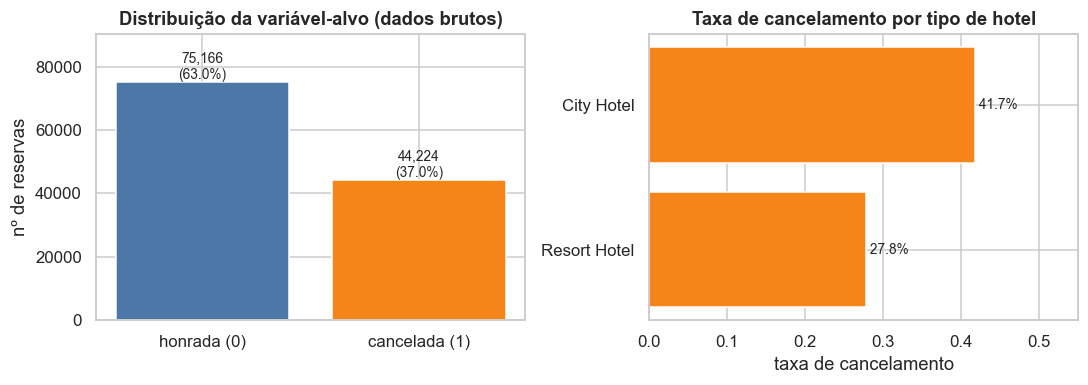

Razão de desbalanceamento (maior/menor classe): 1.70:1


In [4]:
vc = df_raw["is_canceled"].value_counts().sort_index()
prop = df_raw["is_canceled"].value_counts(normalize=True).sort_index()

tab_alvo = pd.DataFrame({"contagem": vc, "proporção": prop.round(4)})
tab_alvo.index = ["0 — honrada", "1 — cancelada"]
display(tab_alvo)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].bar(["honrada (0)", "cancelada (1)"], vc.values, color=[C_NEG, C_POS])
for i, v in enumerate(vc.values):
    ax[0].text(i, v, f"{v:,}\n({prop.values[i]*100:.1f}%)", ha="center", va="bottom", fontsize=9)
ax[0].set_title("Distribuição da variável-alvo (dados brutos)")
ax[0].set_ylabel("nº de reservas"); ax[0].set_ylim(0, vc.max()*1.2)

taxa_hotel = df_raw.groupby("hotel")["is_canceled"].mean().sort_values()
ax[1].barh(taxa_hotel.index, taxa_hotel.values, color=C_POS)
for i, v in enumerate(taxa_hotel.values):
    ax[1].text(v, i, f" {v*100:.1f}%", va="center", fontsize=9)
ax[1].set_title("Taxa de cancelamento por tipo de hotel")
ax[1].set_xlim(0, 0.55); ax[1].set_xlabel("taxa de cancelamento")
plt.tight_layout(); plt.show()

razao = vc.max() / vc.min()
print(f"Razão de desbalanceamento (maior/menor classe): {razao:.2f}:1")

### Interpretação

O desbalanceamento é **moderado** (aproximadamente 63% / 37%, razão 1,70:1) — não é um caso de
classe rara. Ainda assim, ele é suficiente para que a **acurácia isolada seja enganosa**: um
classificador trivial que preveja sempre "não cancela" já atinge ~63% de acurácia sem qualquer
poder preditivo. Por isso a métrica principal não será acurácia (ver Seção 5).

Note também que o *City Hotel* cancela bem mais que o *Resort Hotel* (41,7% contra 27,8%) — um
primeiro indício de sinal preditivo nos atributos.

## 3.3 Valores ausentes

In [5]:
aus = df_raw.isna().sum()
aus = aus[aus > 0].sort_values(ascending=False)
print("Colunas com valores ausentes:\n")
print(pd.DataFrame({"n_ausentes": aus, "%": (aus/len(df_raw)*100).round(3)}).to_string())

Colunas com valores ausentes:

          n_ausentes      %
country          488  0.409
children           4  0.003


### Decisão de tratamento

| Coluna | Ausentes | Decisão | Justificativa |
|--------|----------|---------|---------------|
| `children` | 4 (0,003%) | imputar por **0** | Em todos os 4 casos `adults > 0`; a ausência aqui significa "sem crianças informadas". Com 4 registros, qualquer estratégia é equivalente — 0 é a moda e preserva a semântica de contagem. |
| `country` | 488 (0,41%) | categoria explícita **`UNK`** | A ausência do país pode ser *informativa* (reservas por canais que não coletam a nacionalidade). Imputar pela moda (`PRT`) introduziria um viés artificial de 488 portugueses inexistentes. |

Optamos por **não descartar** linhas por ausência: o volume é irrisório e, no caso de `country`,
a própria ausência é tratada como informação.

## 3.4 Vazamento de dados (*data leakage*) — o ponto crítico deste dataset

Duas colunas descrevem o **desfecho** da reserva e, portanto, **não existem** no momento em que a
predição precisaria ser feita. Mantê-las produziria um modelo com desempenho quase perfeito e
completamente inútil na prática.

In [6]:
print("Tabela cruzada: reservation_status x is_canceled\n")
ct = pd.crosstab(df_raw["reservation_status"], df_raw["is_canceled"])
ct.columns = ["is_canceled = 0", "is_canceled = 1"]
display(ct)

# Um único mapeamento determinístico reconstrói o alvo:
rec = (df_raw["reservation_status"].isin(["Canceled", "No-Show"]).astype(int)
       == df_raw["is_canceled"]).mean()
print(f"\nAcurácia da regra 'status in (Canceled, No-Show)' -> is_canceled: {rec*100:.2f}%")
print("=> reservation_status determina o alvo de forma exata: VAZAMENTO.")
print("\nreservation_status_date é a data em que esse desfecho foi registrado")
print("(check-out ou cancelamento) — também posterior ao instante da predição.")

Tabela cruzada: reservation_status x is_canceled



,is_canceled = 0,is_canceled = 1
reservation_status,,
Canceled,0,43017
Check-Out,75166,0
No-Show,0,1207



Acurácia da regra 'status in (Canceled, No-Show)' -> is_canceled: 100.00%
=> reservation_status determina o alvo de forma exata: VAZAMENTO.

reservation_status_date é a data em que esse desfecho foi registrado
(check-out ou cancelamento) — também posterior ao instante da predição.


### Decisão

**Remover `reservation_status` e `reservation_status_date`.**

Este é o tipo de erro que produz um modelo com 100% de acurácia em validação e desempenho nulo em
produção. A regra que adotamos para todo o pré-processamento é: *uma coluna só pode ser usada se
seu valor for conhecido no instante em que a reserva é registrada*.

### 3.4.1 Um vazamento mais sutil: `assigned_room_type`

Aplicando a mesma regra a todas as demais colunas, encontramos um segundo caso — bem menos óbvio.
O **quarto atribuído** só é definido no **check-in**. Se o quarto atribuído difere do reservado,
isso significa que o hóspede *efetivamente chegou ao hotel*.

In [7]:
trocou = (df_raw["reserved_room_type"] != df_raw["assigned_room_type"]).astype(int)
g_ = df_raw.groupby(trocou)["is_canceled"].agg(["mean", "size"])
g_.index = ["quarto atribuído == reservado", "quarto atribuído != reservado"]
g_.columns = ["taxa de cancelamento", "nº de reservas"]
g_["taxa de cancelamento"] = (g_["taxa de cancelamento"] * 100).round(2).astype(str) + " %"
display(g_)
print("Entre as reservas em que houve troca de quarto, apenas ~5% aparecem como canceladas,")
print("contra ~42% no restante. A troca de quarto é consequência do check-in — ou seja,")
print("é informação POSTERIOR ao desfecho que queremos prever.")

,taxa de cancelamento,nº de reservas
quarto atribuído == reservado,41.56 %,104473
quarto atribuído != reservado,5.38 %,14917


Entre as reservas em que houve troca de quarto, apenas ~5% aparecem como canceladas,
contra ~42% no restante. A troca de quarto é consequência do check-in — ou seja,
é informação POSTERIOR ao desfecho que queremos prever.


### Decisão

**Remover `assigned_room_type` e manter `reserved_room_type`.**

O quarto *reservado* é escolhido pelo cliente no ato da reserva (informação legítima); o quarto
*atribuído* é definido na recepção. Mantida, essa coluna daria ao modelo uma pista indireta de que
o hóspede compareceu, inflando artificialmente o desempenho. Foi uma das decisões de
pré-processamento que mais nos exigiu atenção, porque o vazamento aqui não é determinístico — é
apenas uma correlação muito forte, do tipo que passa despercebido em uma inspeção superficial.

## 3.5 Atributos identificadores (PII)

As colunas `name`, `phone-number` e `credit_card` são dados pessoais sintéticos acrescentados a
esta variante do dataset.

In [8]:
pii = ["name", "phone-number", "credit_card"]
print(pd.DataFrame({
    "n_distintos": df_raw[pii].nunique(),
    "n_linhas": len(df_raw),
    "razão distintos/linhas": (df_raw[pii].nunique()/len(df_raw)).round(4),
}).to_string())

              n_distintos  n_linhas  razão distintos/linhas
name                81503    119390                  0.6827
phone-number       119390    119390                  1.0000
credit_card          9000    119390                  0.0754


### Decisão

**Remover as três colunas.** Motivos:

1. **Ausência de poder preditivo generalizável** — `phone-number` é único por linha (razão 1,00);
   codificá-lo equivaleria a dar ao modelo um identificador da própria observação, caminho direto
   para memorização.
2. **Privacidade** — são dados pessoais; não há justificativa técnica para processá-los.
3. **Custo de codificação** — 81.503 nomes distintos gerariam uma matriz esparsa inviável.

## 3.6 Registros duplicados

Depois de remover PII e colunas de desfecho, restam apenas os atributos que o modelo efetivamente
enxerga. Verificamos quantas linhas são **idênticas nesse espaço de atributos**.

In [9]:
LEAK = ["reservation_status", "reservation_status_date", "assigned_room_type"]
PII  = ["name", "phone-number", "credit_card"]
df_mod = df_raw.drop(columns=LEAK + PII)
print("Colunas removidas por vazamento :", LEAK)
print("Colunas removidas por serem PII :", PII)
print("Restam", df_mod.shape[1] - 1, "preditores candidatos.\n")

n_dup = df_mod.duplicated().sum()
print(f"Linhas idênticas no espaço de atributos do modelo: {n_dup:,} "
      f"({n_dup/len(df_mod)*100:.1f}% do total)")

dup_mask = df_mod.duplicated(keep=False)
print(f"\nTaxa de cancelamento entre linhas duplicadas  : "
      f"{df_mod.loc[dup_mask, 'is_canceled'].mean()*100:.1f}%")
print(f"Taxa de cancelamento entre linhas únicas      : "
      f"{df_mod.loc[~dup_mask, 'is_canceled'].mean()*100:.1f}%")

Colunas removidas por vazamento : ['reservation_status', 'reservation_status_date', 'assigned_room_type']
Colunas removidas por serem PII : ['name', 'phone-number', 'credit_card']
Restam 26 preditores candidatos.

Linhas idênticas no espaço de atributos do modelo: 33,273 (27.9% do total)



Taxa de cancelamento entre linhas duplicadas  : 57.3%


Taxa de cancelamento entre linhas únicas      : 26.3%


### Decisão: remover duplicatas exatas

**Por que elas existem.** Reservas de grupo geram várias linhas com atributos idênticos. O dataset
original do *Hotel Booking Demand* possui as colunas `agent` e `company`, que ajudariam a
distingui-las; nesta variante elas não estão presentes.

**Por que removemos.** O problema não é estatístico, é **metodológico**: se a mesma linha aparece
no conjunto de treino e no de teste (ou em folds diferentes da validação cruzada), o modelo é
avaliado sobre exemplos que já memorizou. O desempenho reportado ficaria **otimista por
construção**. Como o modelo só enxerga o espaço de atributos, duas linhas idênticas nesse espaço
são, para ele, a mesma observação.

**Consequência a registrar.** As duplicatas concentram cancelamentos (a taxa entre elas é bem
superior à das linhas únicas). Ao removê-las, a taxa de cancelamento cai de ~37% para ~27%, ou
seja, **o problema fica mais desbalanceado**. Isso é um resultado honesto, não um efeito colateral
a esconder: a prevalência de 37% no arquivo bruto estava inflada pela repetição de reservas de
grupo canceladas. Levamos isso em conta ao escolher a métrica (Seção 5).

## 3.7 Registros inválidos e valores atípicos

In [10]:
g = df_mod["adults"] + df_mod["children"].fillna(0) + df_mod["babies"]
n = df_mod["stays_in_weekend_nights"] + df_mod["stays_in_week_nights"]

print(f"Reservas com ZERO hóspedes        : {(g == 0).sum():,}")
print(f"Reservas com ZERO noites          : {(n == 0).sum():,}")
print(f"Reservas com adr negativa         : {(df_mod['adr'] < 0).sum():,}"
      f"  (mínimo = {df_mod['adr'].min():.2f})")
print(f"Reservas com adr acima de 1000    : {(df_mod['adr'] > 1000).sum():,}"
      f"  (máximo = {df_mod['adr'].max():.2f})")
print()
print("Extremos de contagens:")
print(df_mod[["adults", "children", "babies", "lead_time", "days_in_waiting_list",
              "previous_cancellations"]].max().to_string())

Reservas com ZERO hóspedes        : 180
Reservas com ZERO noites          : 715
Reservas com adr negativa         : 1  (mínimo = -6.38)
Reservas com adr acima de 1000    : 1  (máximo = 5400.00)

Extremos de contagens:
adults                     55.0
children                   10.0
babies                     10.0
lead_time                 737.0
days_in_waiting_list      391.0
previous_cancellations     26.0


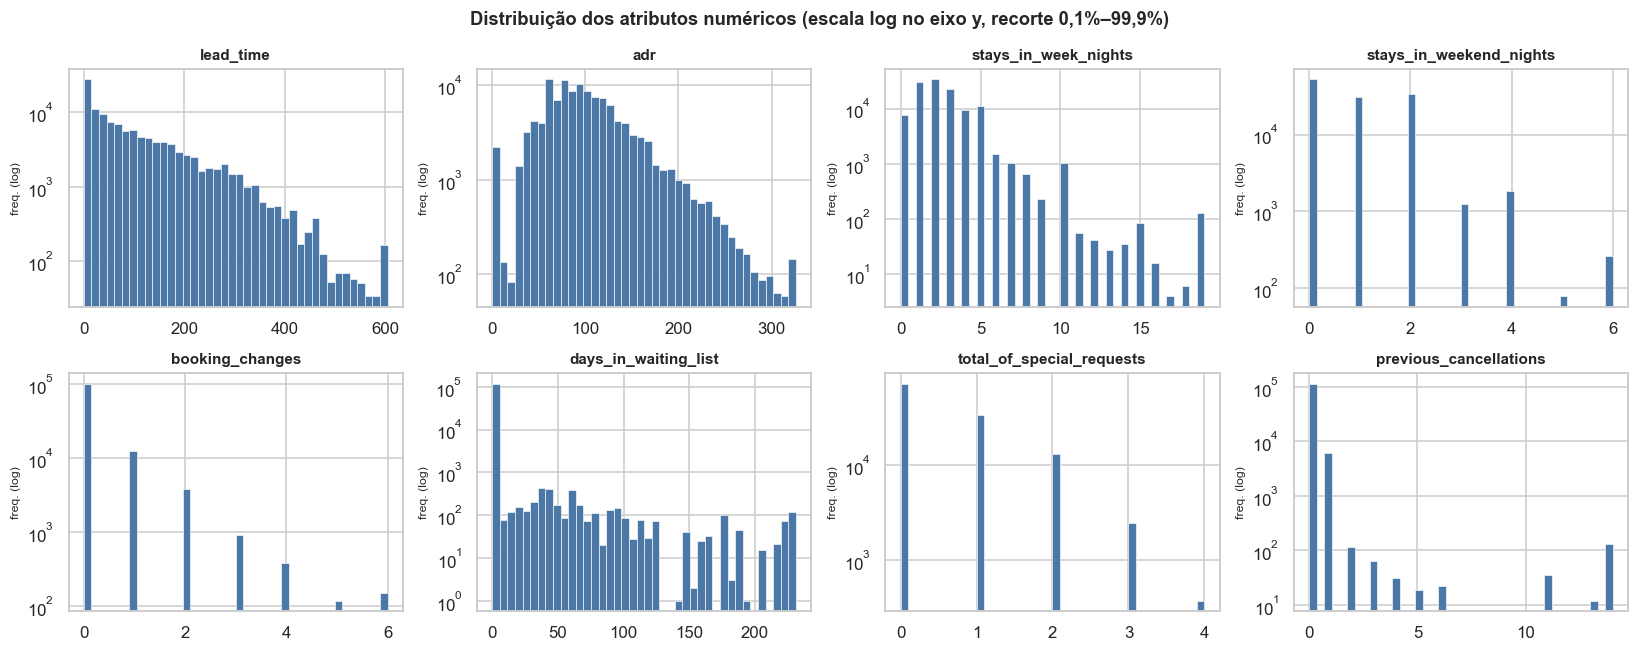

In [11]:
num_cols_eda = ["lead_time", "adr", "stays_in_week_nights", "stays_in_weekend_nights",
                "booking_changes", "days_in_waiting_list", "total_of_special_requests",
                "previous_cancellations"]

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, c in zip(axes.ravel(), num_cols_eda):
    s = df_mod[c].clip(df_mod[c].quantile(0.001), df_mod[c].quantile(0.999))
    ax.hist(s, bins=40, color=C_NEG, edgecolor="white", linewidth=0.4)
    ax.set_title(c, fontsize=10)
    ax.set_yscale("log")
    ax.set_ylabel("freq. (log)", fontsize=8)
fig.suptitle("Distribuição dos atributos numéricos (escala log no eixo y, recorte 0,1%–99,9%)",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

### Leitura dos histogramas e decisões

- **Escalas muito diferentes.** `lead_time` vai de 0 a 737 dias, `adr` de −6 a 5.400, enquanto a
  maioria das contagens fica entre 0 e 5. Uma rede neural treinada com gradiente descendente é
  sensível a isso: atributos de maior magnitude dominam o gradiente nas primeiras camadas.
  → **Padronização obrigatória** (Seção 4.4).
- **Fortíssima assimetria à direita.** `days_in_waiting_list`, `previous_cancellations` e
  `booking_changes` são quase sempre 0, com cauda longa. Optamos por **não** aplicar transformação
  logarítmica: as caudas carregam sinal real (um hóspede com 26 cancelamentos prévios é
  genuinamente diferente), e a padronização já resolve o problema de escala.
- **Registros impossíveis.** Reservas com zero hóspedes (180) ou zero noites (715) são erros de
  registro — não representam uma estadia. → **Remover as linhas.**
- **`adr` negativa.** Um único registro com −6,38 (provável estorno). → **Remover a linha.**
- **`adr` extrema.** Um registro com 5.400 contra mediana de 94,6. Em vez de descartar, aplicamos
  **winsorização no percentil 99,5 estimado apenas no conjunto de treino** (Seção 4.3): o valor é
  implausível, mas tarifas altas são legítimas — limitar preserva a observação sem deixar o
  outlier dominar a padronização.

## 3.8 Sinal preditivo dos atributos categóricos

Comparamos a taxa de cancelamento entre as categorias. Quanto mais a taxa de uma categoria se
afasta da taxa global, mais informativo é o atributo.

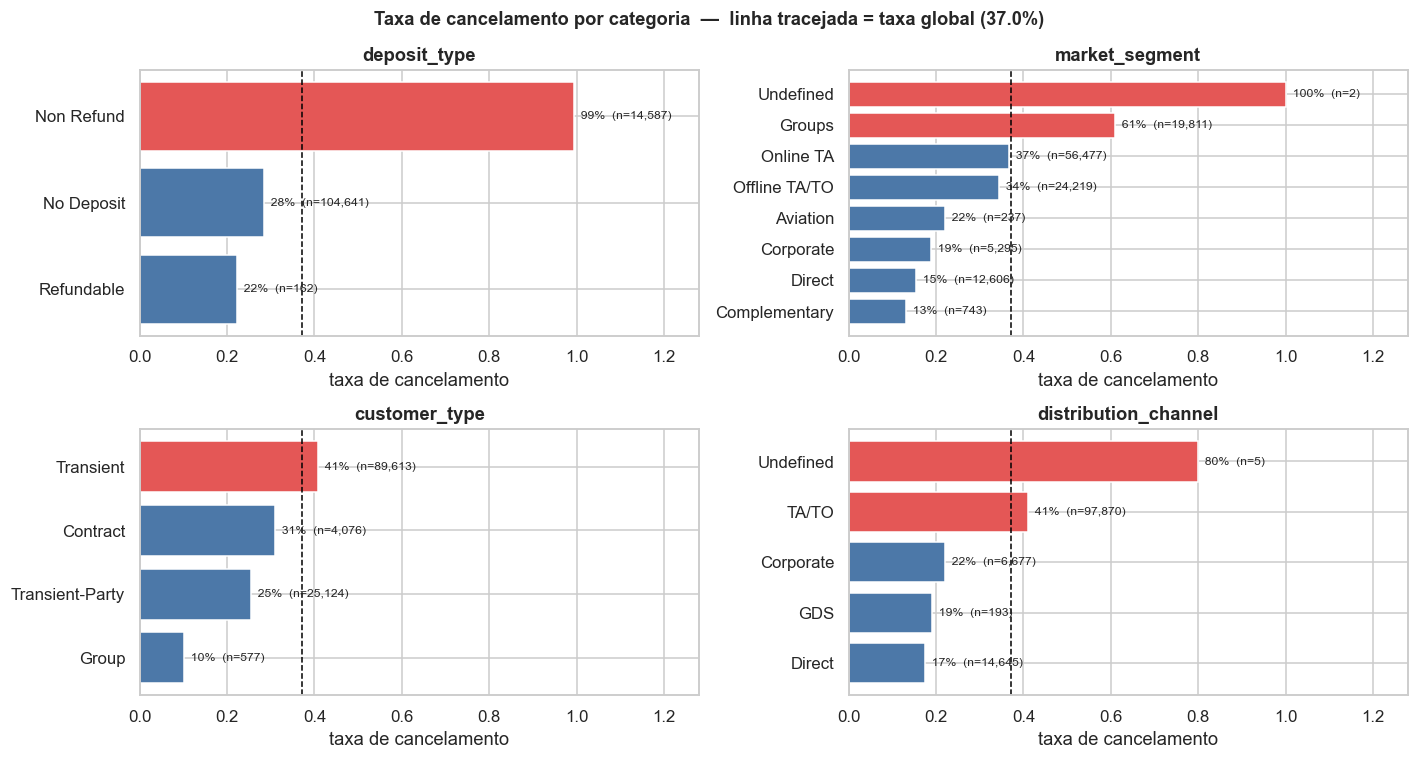

In [12]:
base = df_mod["is_canceled"].mean()
cats_plot = ["deposit_type", "market_segment", "customer_type", "distribution_channel"]

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for ax, c in zip(axes.ravel(), cats_plot):
    g_ = df_mod.groupby(c)["is_canceled"].agg(["mean", "size"]).sort_values("mean")
    cores = [C_BAD if v > base else C_NEG for v in g_["mean"]]
    ax.barh(g_.index.astype(str), g_["mean"], color=cores)
    for i, (m, s) in enumerate(zip(g_["mean"], g_["size"])):
        ax.text(m, i, f"  {m*100:.0f}%  (n={s:,})", va="center", fontsize=8)
    ax.axvline(base, color="black", ls="--", lw=1)
    ax.set_xlim(0, 1.28); ax.set_title(c); ax.set_xlabel("taxa de cancelamento")
fig.suptitle(f"Taxa de cancelamento por categoria  —  linha tracejada = taxa global ({base*100:.1f}%)",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

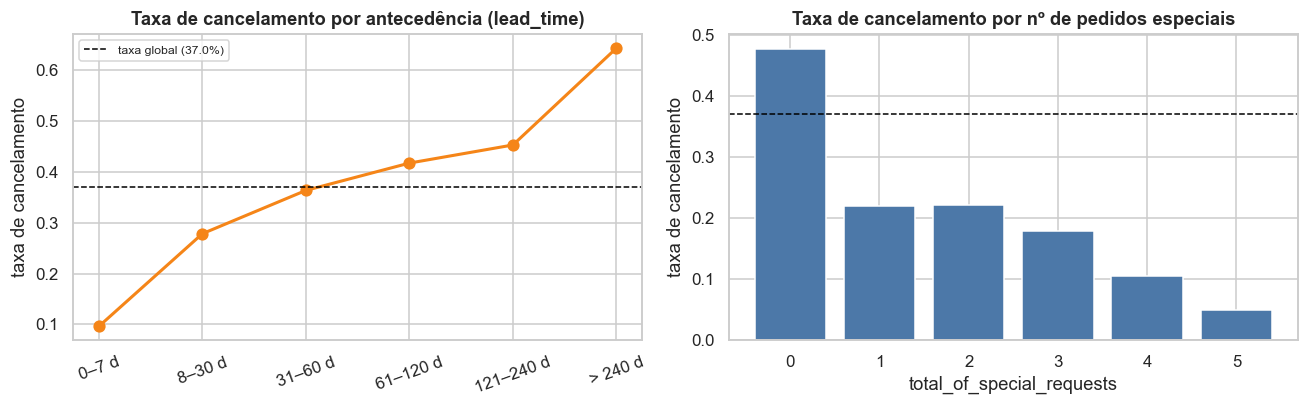

In [13]:
# lead_time discretizado: o atributo numérico com relação mais clara e monótona com o alvo
bins = [-1, 7, 30, 60, 120, 240, 800]
lab  = ["0–7 d", "8–30 d", "31–60 d", "61–120 d", "121–240 d", "> 240 d"]
tmp  = df_mod.assign(faixa=pd.cut(df_mod["lead_time"], bins=bins, labels=lab))
g_   = tmp.groupby("faixa", observed=True)["is_canceled"].agg(["mean", "size"])

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].plot(range(len(g_)), g_["mean"], "o-", color=C_POS, lw=2, ms=7)
ax[0].axhline(base, color="black", ls="--", lw=1, label=f"taxa global ({base*100:.1f}%)")
ax[0].set_xticks(range(len(g_))); ax[0].set_xticklabels(g_.index, rotation=20)
ax[0].set_title("Taxa de cancelamento por antecedência (lead_time)")
ax[0].set_ylabel("taxa de cancelamento"); ax[0].legend(fontsize=8)

g2 = df_mod.groupby("total_of_special_requests")["is_canceled"].mean()
ax[1].bar(g2.index.astype(str), g2.values, color=C_NEG)
ax[1].axhline(base, color="black", ls="--", lw=1)
ax[1].set_title("Taxa de cancelamento por nº de pedidos especiais")
ax[1].set_xlabel("total_of_special_requests"); ax[1].set_ylabel("taxa de cancelamento")
plt.tight_layout(); plt.show()

### Interpretação — hipóteses que o modelo deveria capturar

- **`deposit_type = Non Refund` cancela em 99,4% dos casos.** Longe de ser um erro, é um artefato
  conhecido deste dataset: reservas não reembolsáveis que não aparecem são registradas como
  canceladas. É um preditor extremamente forte e legítimo (é conhecido no momento da reserva).
- **`market_segment = Groups` cancela 61%**, contra 15% em `Direct`. Reservas de grupo e reservas
  feitas por intermediários são estruturalmente mais voláteis.
- **A antecedência é quase monótona:** reservas feitas com menos de 7 dias cancelam pouco; acima de
  240 dias, a taxa mais que dobra. Compromisso com muita antecedência é frágil.
- **Pedidos especiais reduzem o risco de forma monótona.** É um proxy de engajamento: quem pediu
  berço, andar alto ou late check-out já se planejou para ir.

Essas relações são **não lineares** e **interagem** entre si — justificativa concreta para o uso
de uma MLP em vez de uma regressão logística.

## 3.9 Correlação entre atributos numéricos

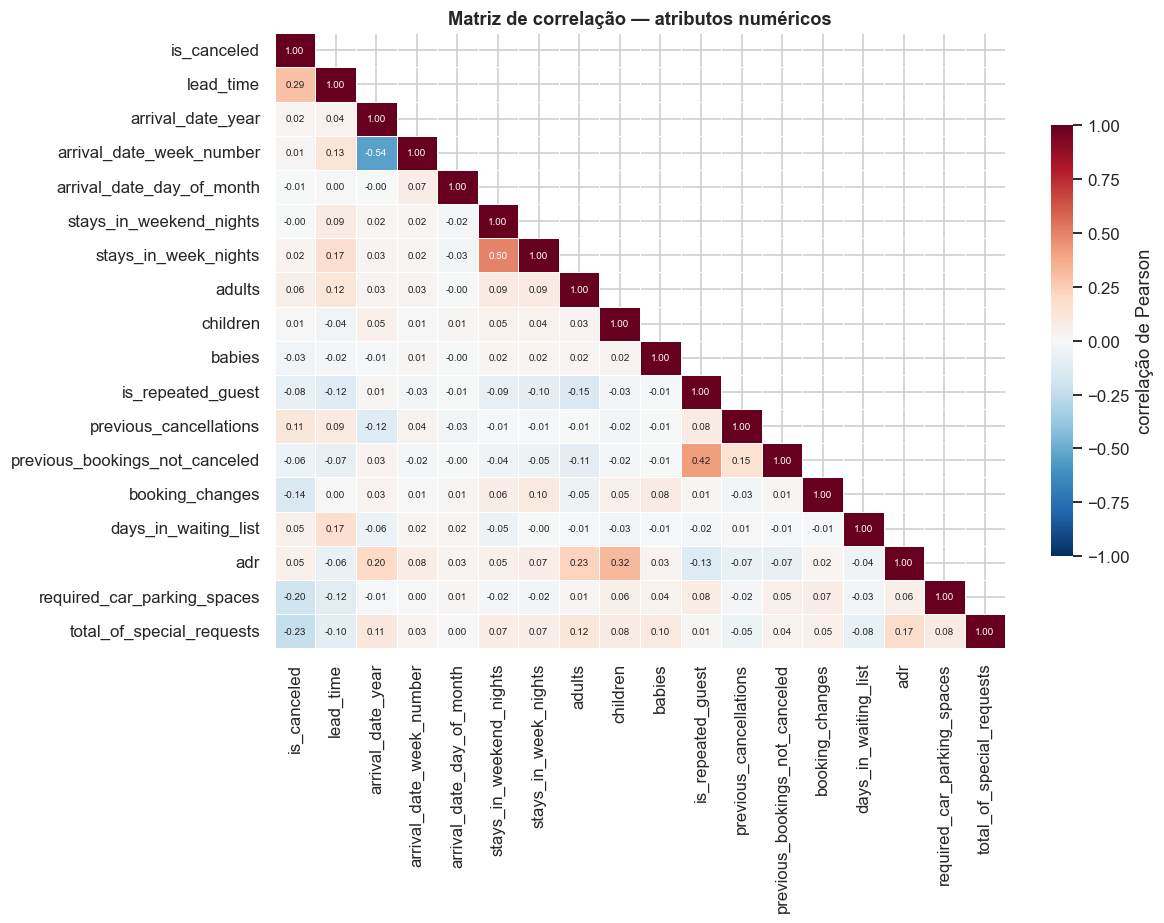

Maiores correlações (em módulo) com o alvo:
lead_time                         0.293123
total_of_special_requests         0.234658
required_car_parking_spaces       0.195498
booking_changes                   0.144381
previous_cancellations            0.110133
is_repeated_guest                 0.084793
adults                            0.060017
previous_bookings_not_canceled    0.057358


In [14]:
num_corr = df_mod.select_dtypes(include=[np.number]).copy()
corr = num_corr.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 8.5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 6.5},
            linewidths=0.4, cbar_kws={"shrink": 0.7, "label": "correlação de Pearson"}, ax=ax)
ax.set_title("Matriz de correlação — atributos numéricos")
plt.tight_layout(); plt.show()

print("Maiores correlações (em módulo) com o alvo:")
print(corr["is_canceled"].drop("is_canceled").abs().sort_values(ascending=False).head(8).to_string())

### Leitura

As correlações lineares com o alvo são **modestas** — a maior é `lead_time` (~0,29), seguida de
`total_of_special_requests` e `required_car_parking_spaces` (negativas). Isso reforça o
diagnóstico da Seção 3.8: **o sinal existe, mas não é predominantemente linear**, o que favorece um
modelo não linear.

Entre preditores não há multicolinearidade severa que justifique remoção; o par mais correlacionado
é `arrival_date_year` × `arrival_date_week_number`, o que é esperado pela estrutura temporal.

<a id="sec4"></a>
# 4. Pré-processamento e separação do *holdout*

A ordem das operações abaixo **não é arbitrária** e é o ponto metodológico central desta seção:

```
  (A) limpeza em nível de linha        -> pode ser feita no dataset inteiro
      (imputação trivial, duplicatas,     (não usa informação do alvo nem estatísticas
       registros impossíveis)              agregadas — não há vazamento)

  (B) SEPARAÇÃO DO HOLDOUT DE TESTE    <-- a partir daqui o teste fica lacrado
                                           e não participa de mais nada

  (C) decisões que dependem de          -> estimadas SOMENTE no treino
      estatísticas dos dados               e apenas APLICADAS no teste
      (países frequentes, limites de
       winsorização, média/desvio)
```

Tudo o que está em (C) — inclusive a lista de países frequentes e os limites de winsorização, e não
apenas o `StandardScaler` — é estimado exclusivamente sobre o conjunto de treino.

## 4.1 Limpeza em nível de linha

In [15]:
df = df_raw.drop(columns=LEAK + PII).copy()
log_linhas = [("arquivo bruto", len(df))]

# (1) valores ausentes
df["children"] = df["children"].fillna(0).astype(int)   # 4 registros; 0 = moda e semântica correta
df["country"]  = df["country"].fillna("UNK")            # ausência tratada como categoria própria

# (2) duplicatas exatas no espaço de atributos do modelo
df = df.drop_duplicates().reset_index(drop=True)
log_linhas.append(("após remover duplicatas exatas", len(df)))

# (3) registros logicamente impossíveis
hospedes = df["adults"] + df["children"] + df["babies"]
noites   = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
valido   = (hospedes > 0) & (noites > 0) & (df["adr"] >= 0)
df = df.loc[valido].reset_index(drop=True)
log_linhas.append(("após remover registros impossíveis", len(df)))

tab = pd.DataFrame(log_linhas, columns=["etapa", "linhas"])
tab["removidas"] = -tab["linhas"].diff().fillna(0).astype(int)
tab["% do bruto"] = (tab["linhas"] / log_linhas[0][1] * 100).round(1)
display(tab)

print(f"\nTaxa de cancelamento após a limpeza: {df['is_canceled'].mean()*100:.2f}% "
      f"(era {df_raw['is_canceled'].mean()*100:.2f}% no arquivo bruto)")

,etapa,linhas,removidas,% do bruto
0,arquivo bruto,119390,0,100.0
1,após remover duplicatas exatas,86117,33273,72.1
2,após remover registros impossíveis,85362,755,71.5



Taxa de cancelamento após a limpeza: 27.75% (era 37.04% no arquivo bruto)


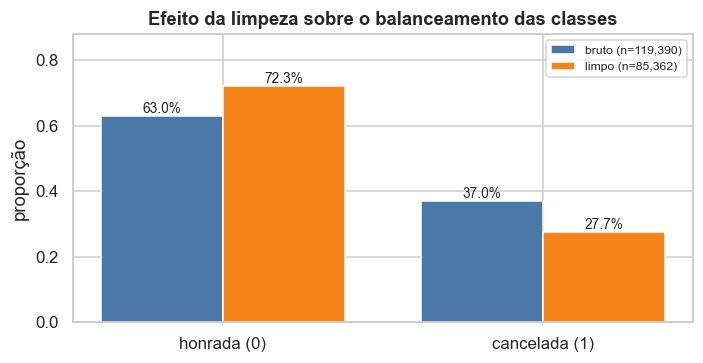

Razão de desbalanceamento após a limpeza: 2.60:1  (era 1.70:1)


In [16]:
vc2 = df["is_canceled"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(6.5, 3.4))
x = np.arange(2); w = 0.38
b1 = df_raw["is_canceled"].value_counts(normalize=True).sort_index().values
b2 = df["is_canceled"].value_counts(normalize=True).sort_index().values
ax.bar(x - w/2, b1, w, label=f"bruto (n={len(df_raw):,})", color=C_NEG)
ax.bar(x + w/2, b2, w, label=f"limpo (n={len(df):,})", color=C_POS)
for i in range(2):
    ax.text(i - w/2, b1[i], f"{b1[i]*100:.1f}%", ha="center", va="bottom", fontsize=9)
    ax.text(i + w/2, b2[i], f"{b2[i]*100:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(["honrada (0)", "cancelada (1)"])
ax.set_ylabel("proporção"); ax.set_ylim(0, 0.88)
ax.set_title("Efeito da limpeza sobre o balanceamento das classes")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"Razão de desbalanceamento após a limpeza: "
      f"{vc2.max()/vc2.min():.2f}:1  (era {df_raw['is_canceled'].value_counts().max()/df_raw['is_canceled'].value_counts().min():.2f}:1)")

> **Registro da decisão.** A remoção das duplicatas tornou o problema mais desbalanceado
> (de ~1,7:1 para ~2,6:1). Como discutido na Seção 3.6, essa é a prevalência **honesta** do
> fenômeno no espaço de atributos que o modelo enxerga. A alternativa — manter as duplicatas —
> produziria métricas mais bonitas e sem validade, porque as mesmas linhas apareceriam em treino e
> teste. Assumimos o custo de um problema mais difícil em troca de uma avaliação confiável.

## 4.2 Engenharia de atributos

Acrescentamos poucos atributos, todos derivados de colunas já existentes e todos conhecidos no
momento da reserva. O critério foi **parcimônia**: só criamos um atributo quando ele expressa uma
relação que a rede teria de aprender de forma desnecessariamente indireta.

| Novo atributo | Fórmula | Por quê |
|---------------|---------|---------|
| `total_nights` | `stays_in_weekend_nights + stays_in_week_nights` | A duração total da estadia é o conceito de negócio relevante; a rede precisaria aprender a somá-las. |
| `total_guests` | `adults + children + babies` | Idem para o tamanho do grupo. |
| `adr_por_pessoa` | `adr / total_guests` | Separa "tarifa alta porque o quarto é caro" de "tarifa alta porque há muita gente" — duas situações de risco distintas. |
| `month_sin`, `month_cos` | codificação cíclica de `arrival_date_month` | Dezembro e janeiro são meses adjacentes. Nem a codificação ordinal (12 → 1 seria um salto enorme) nem o *one-hot* (que descarta a vizinhança) representam isso. A projeção no círculo unitário preserva a continuidade sazonal com apenas 2 dimensões, em vez de 12. |

Mantemos `stays_in_*`, `adults/children/babies` e `adr` originais: a informação desagregada
continua útil (fim de semana ≠ dia útil) e a redundância não prejudica uma rede neural com
regularização.

In [17]:
MESES = ["January", "February", "March", "April", "May", "June",
         "July", "August", "September", "October", "November", "December"]
MES_NUM = {m: i + 1 for i, m in enumerate(MESES)}

df["total_nights"]   = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
df["total_guests"]   = df["adults"] + df["children"] + df["babies"]
df["adr_por_pessoa"] = df["adr"] / df["total_guests"]

_m = df["arrival_date_month"].map(MES_NUM)
df["month_sin"] = np.sin(2 * np.pi * _m / 12)
df["month_cos"] = np.cos(2 * np.pi * _m / 12)
df = df.drop(columns=["arrival_date_month"])

print("Atributos criados:", ["total_nights", "total_guests", "adr_por_pessoa",
                             "month_sin", "month_cos"])
print("Dimensões após engenharia de atributos:", df.shape)
df[["total_nights", "total_guests", "adr_por_pessoa", "month_sin", "month_cos"]].describe().T.round(3)

Atributos criados: ['total_nights', 'total_guests', 'adr_por_pessoa', 'month_sin', 'month_cos']
Dimensões após engenharia de atributos: (85362, 31)


,count,mean,std,min,25%,50%,75%,max
total_nights,85362.0,3.666,2.742,1.0,2.000,3.0,5.0,69.0
total_guests,85362.0,2.035,0.793,1.0,2.000,2.0,2.0,55.0
adr_por_pessoa,85362.0,55.982,29.528,0.0,38.250,50.1,67.5,2700.0
month_sin,85362.0,-0.041,0.719,-1.0,-0.866,-0.0,0.5,1.0
month_cos,85362.0,-0.155,0.676,-1.0,-0.866,-0.5,0.5,1.0


## 4.3 Separação do *holdout* de teste

**Este é o ponto de corte metodológico do trabalho.** A partir daqui, `X_test` / `y_test` ficam
lacrados: não participam da validação cruzada, do Random Search, do TPE nem das análises de
sensibilidade. Serão abertos uma única vez, na Seção 10.

Usamos divisão **estratificada** 80/20 — estratificada porque, com 27% de positivos, uma divisão
aleatória simples poderia produzir proporções de classe sensivelmente diferentes entre treino e
teste, contaminando a comparação.

In [18]:
y_all = df["is_canceled"].astype(int).values
X_all = df.drop(columns=["is_canceled"])

# dividimos os ÍNDICES (e não os DataFrames) para poder reconstruir a partição depois,
# quando formos exportar os dados para o notebook da SOM
IDX_TRAIN, IDX_TEST = train_test_split(
    np.arange(len(df)), test_size=TEST_SIZE, stratify=y_all, random_state=RANDOM_STATE)

X_train_raw = X_all.iloc[IDX_TRAIN].reset_index(drop=True)
X_test_raw  = X_all.iloc[IDX_TEST].reset_index(drop=True)
y_train, y_test = y_all[IDX_TRAIN], y_all[IDX_TEST]

print(f"Treino : {len(X_train_raw):>7,} linhas  |  positivos: {y_train.mean()*100:.2f}%")
print(f"Teste  : {len(X_test_raw):>7,} linhas  |  positivos: {y_test.mean()*100:.2f}%")
print("\n>>> A partir desta célula, X_test_raw/y_test NÃO são usados até a Seção 10. <<<")

Treino :  68,289 linhas  |  positivos: 27.75%


Teste  :  17,073 linhas  |  positivos: 27.75%

>>> A partir desta célula, X_test_raw/y_test NÃO são usados até a Seção 10. <<<


## 4.4 Transformações estimadas no treino

Três transformações dependem de estatísticas dos dados e, portanto, são **ajustadas apenas no
treino**:

**(a) Agrupamento de países.** `country` tem 177 categorias, com uma cauda de dezenas de países com
menos de 10 reservas. Codificar todas geraria colunas esparsas que a rede não conseguiria estimar
de forma confiável, além de garantir categorias vistas no teste e ausentes do treino. Mantemos os
**30 países mais frequentes do conjunto de treino** e agrupamos o restante em `OTHER`.

**(b) Winsorização.** `adr`, `lead_time` e `days_in_waiting_list` têm caudas extremas que
distorceriam a média e o desvio-padrão da padronização — um único `adr = 5400` desloca a média de
toda a coluna. Limitamos os valores ao **percentil 99,5 do treino**. Preferimos winsorizar a
descartar: a observação é válida, apenas o valor é implausível.

**(c) Padronização e codificação.** `StandardScaler` nos numéricos (a MLP treina com gradiente
descendente e é sensível a escalas heterogêneas) e `OneHotEncoder` nos categóricos, com
`handle_unknown="ignore"` para que uma categoria inédita no teste vire um vetor de zeros em vez de
provocar erro.

In [19]:
# ---------- (a) países frequentes: lista estimada SOMENTE no treino ----------
TOP_PAISES = X_train_raw["country"].value_counts().head(30).index.tolist()
cobertura = X_train_raw["country"].isin(TOP_PAISES).mean()
print(f"Os 30 países mais frequentes cobrem {cobertura*100:.1f}% do conjunto de treino.")

def agrupar_paises(X):
    X = X.copy()
    X["country"] = np.where(X["country"].isin(TOP_PAISES), X["country"], "OTHER")
    return X

# ---------- (b) winsorização: limites estimados SOMENTE no treino ----------
COLS_WINSOR = ["adr", "lead_time", "days_in_waiting_list"]
LIMITES = {c: X_train_raw[c].quantile(0.995) for c in COLS_WINSOR}
print("\nLimites de winsorização (percentil 99,5 do treino):")
for c, v in LIMITES.items():
    afet = (X_train_raw[c] > v).mean() * 100
    print(f"  {c:22s} <= {v:8.2f}   (afeta {afet:.2f}% do treino; máx. original = {X_train_raw[c].max():.1f})")

def winsorizar(X):
    X = X.copy()
    for c, v in LIMITES.items():
        X[c] = X[c].clip(upper=v)
    X["adr_por_pessoa"] = X["adr"] / X["total_guests"]   # recalcula após limitar adr
    return X

X_train_p = winsorizar(agrupar_paises(X_train_raw))
X_test_p  = winsorizar(agrupar_paises(X_test_raw))

Os 30 países mais frequentes cobrem 96.3% do conjunto de treino.

Limites de winsorização (percentil 99,5 do treino):
  adr                    <=   286.00   (afeta 0.50% do treino; máx. original = 5400.0)
  lead_time              <=   386.00   (afeta 0.48% do treino; máx. original = 709.0)
  days_in_waiting_list   <=    45.56   (afeta 0.50% do treino; máx. original = 391.0)


In [20]:
# ---------- (c) padronização + one-hot ----------
COLS_NUM = X_train_p.select_dtypes(include=[np.number]).columns.tolist()
COLS_CAT = [c for c in X_train_p.columns if c not in COLS_NUM]

print(f"{len(COLS_NUM)} atributos numéricos  : {COLS_NUM}")
print(f"\n{len(COLS_CAT)} atributos categóricos: {COLS_CAT}")

preproc = ColumnTransformer([
    ("num", StandardScaler(), COLS_NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), COLS_CAT),
], verbose_feature_names_out=False)

X_train = preproc.fit_transform(X_train_p).astype("float32")   # fit APENAS no treino
X_test  = preproc.transform(X_test_p).astype("float32")        # teste apenas transformado
FEATURE_NAMES = list(preproc.get_feature_names_out())
N_FEATURES = X_train.shape[1]

print(f"\nMatriz de treino: {X_train.shape}   |   matriz de teste: {X_test.shape}")
print(f"Total de atributos após codificação: {N_FEATURES}")

22 atributos numéricos  : ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'total_nights', 'total_guests', 'adr_por_pessoa', 'month_sin', 'month_cos']

8 atributos categóricos: ['hotel', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type']



Matriz de treino: (68289, 89)   |   matriz de teste: (17073, 89)
Total de atributos após codificação: 89


## 4.5 Auditoria: verificação de ausência de vazamento

Checagens explícitas de que o protocolo foi respeitado. Esta célula é uma das **medidas de
validação** declaradas na abertura do notebook.

In [21]:
checks = []

# 1) nenhuma observação IDÊNTICA (atributos + alvo) compartilhada entre treino e teste
chave_tr = set(map(tuple, np.column_stack([X_train_raw.astype(str).values,
                                           y_train.astype(str)])))
iguais = sum(tuple(r) in chave_tr for r in np.column_stack([X_test_raw.astype(str).values,
                                                            y_test.astype(str)]))
checks.append(("Nenhuma observação idêntica (atributos + alvo) em treino e teste",
               iguais == 0, f"{iguais} coincidências"))

# 2) atributos idênticos com ALVO DIFERENTE: ambiguidade do problema, não vazamento
so_atrib = set(map(tuple, X_train_raw.astype(str).values))
ambiguas = sum(tuple(r) in so_atrib for r in X_test_raw.astype(str).values)
checks.append(("Pares atributos-idênticos/alvo-diferente abaixo de 1% do teste",
               ambiguas / len(X_test_raw) < 0.01,
               f"{ambiguas} linhas ({ambiguas/len(X_test_raw)*100:.2f}% do teste)"))

# 3) o scaler foi ajustado só no treino -> média ~0 e desvio ~1 no TREINO
mu_tr = X_train[:, :len(COLS_NUM)].mean(); sd_tr = X_train[:, :len(COLS_NUM)].std()
checks.append(("Numéricos do treino padronizados (média≈0, desvio≈1)",
               abs(mu_tr) < 1e-4 and abs(sd_tr - 1) < 1e-3,
               f"média={mu_tr:.2e}, desvio={sd_tr:.6f}"))

# 4) estratificação preservada
dif = abs(y_train.mean() - y_test.mean())
checks.append(("Proporção de positivos equivalente em treino e teste", dif < 0.005,
               f"diferença={dif:.5f}"))

# 5) colunas de vazamento e PII realmente ausentes
ausentes = all(c not in X_train_p.columns for c in LEAK + PII)
checks.append(("Colunas de vazamento e PII removidas", ausentes, ", ".join(LEAK + PII)))

# 6) sem NaN nem infinito nas matrizes finais
limpo = bool(np.isfinite(X_train).all() and np.isfinite(X_test).all())
checks.append(("Matrizes sem NaN ou infinito", limpo, "—"))

aud = pd.DataFrame(checks, columns=["verificação", "resultado", "detalhe"])
aud["resultado"] = aud["resultado"].map({True: "PASSOU", False: "FALHOU"})
display(aud)
assert (aud["resultado"] == "PASSOU").all(), "Auditoria de vazamento falhou!"
print("Todas as verificações passaram.")

,verificação,resultado,detalhe
0,Nenhuma observação idêntica (atributos + alvo)...,PASSOU,0 coincidências
1,Pares atributos-idênticos/alvo-diferente abaix...,PASSOU,82 linhas (0.48% do teste)
2,"Numéricos do treino padronizados (média≈0, des...",PASSOU,"média=1.34e-09, desvio=1.000000"
3,Proporção de positivos equivalente em treino e...,PASSOU,diferença=0.00003
4,Colunas de vazamento e PII removidas,PASSOU,"reservation_status, reservation_status_date, a..."
5,Matrizes sem NaN ou infinito,PASSOU,—


Todas as verificações passaram.


### Sobre a verificação nº 2

A checagem nº 2 merece comentário porque seu resultado **não é zero**. Cerca de 0,5% das linhas do
teste têm um vetor de atributos **idêntico** a alguma linha do treino, mas com **alvo diferente**:
duas reservas com exatamente as mesmas características, uma cancelada e outra honrada.

Isso **não é vazamento** — é uma propriedade do problema. A remoção de duplicatas da Seção 4.1
eliminou repetições exatas (atributos *e* alvo), e a verificação nº 1 confirma que nenhuma
observação idêntica é compartilhada entre as partições. O que resta são casos genuinamente
**ambíguos**: o dataset não contém a informação que diferencia esses dois desfechos.

Esse é um limite superior real para o desempenho de qualquer modelo — nenhuma arquitetura pode
acertar ambos os casos simultaneamente. Retomamos esse ponto na Seção 10.5, ao analisar a
sobreposição das distribuições de probabilidade previstas.

<a id="sec5"></a>
# 5. Métrica principal e estratégia de validação

## 5.1 Escolha da métrica

Com ~27% de positivos, a **acurácia é inadequada como métrica de otimização**: prever sempre
"não cancela" já entrega ~73% de acurácia sem nenhum poder preditivo. Precisamos de uma métrica que
penalize esse comportamento.

**Métrica principal: F1-score da classe positiva (`is_canceled = 1`).**

| Critério | Por que o F1 atende |
|----------|---------------------|
| **Desbalanceamento** | O F1 é a média harmônica entre precisão e revocação, ambas calculadas sobre a classe minoritária. O classificador trivial obtém F1 = 0. |
| **Alinhamento com o negócio** | Os dois erros custam: um falso negativo (cancelamento não previsto) é um quarto vazio; um falso positivo (previsão indevida de cancelamento) pode gerar *overbooking* e realocação de hóspede. Não há razão para privilegiar fortemente um dos lados — o F1 exige equilíbrio. |
| **Comparabilidade** | É um escalar único, requisito para ordenar 25 configurações no Random Search e guiar o TPE. |

**Métricas de acompanhamento** (reportadas, mas não otimizadas): acurácia, acurácia balanceada,
precisão, revocação, **ROC-AUC**, **PR-AUC** e a **matriz de confusão**. O ROC-AUC e o PR-AUC são
importantes porque são independentes do limiar: se o F1 de duas configurações for parecido mas o
AUC diferir, isso indica que a diferença está na calibração do limiar, não na capacidade de
ordenação do modelo.

> **Observação sobre o limiar.** Durante toda a busca o limiar é mantido fixo em 0,5, para que a
> comparação entre configurações seja justa. A otimização do limiar é feita **uma única vez**, ao
> final (Seção 10.4), usando validação cruzada sobre o treino — nunca o conjunto de teste.

## 5.2 Estratégia de validação cruzada

Usamos **`StratifiedKFold` com 3 folds**, embaralhamento e semente fixa, aplicado **somente ao
conjunto de treino**.

- **Estratificada**, para que cada fold preserve a proporção de ~27% de cancelamentos — necessário
  para que o F1 seja comparável entre folds.
- **3 folds**, e não 5 ou 10, por **orçamento computacional**: cada configuração custa 3 treinos
  completos de rede; o trabalho exige 25 configurações no Random Search e mais 25 no TPE, além das
  análises de sensibilidade. Com 3 folds são **150 treinos de rede apenas nas duas buscas**. Com
  69 mil exemplos de treino, cada fold ainda avalia o modelo sobre ~23 mil observações, o que dá
  uma estimativa de F1 com erro-padrão pequeno — a variância entre folds observada adiante confirma
  que 3 folds são suficientes para discriminar as configurações.
- Reportamos sempre **média ± desvio-padrão** entre os folds: uma configuração com F1 médio alto e
  desvio alto é menos confiável do que outra com média ligeiramente menor e desvio baixo.

### Protocolo completo

```
   dados limpos (86.259)
        |
        +-- 80% TREINO (69.007) ------------------+     +-- 20% TESTE (17.252)
        |                                          |     |
        |   StratifiedKFold(3)                     |     |   LACRADO
        |     fold1: treino/validação              |     |   usado 1x na Seção 10
        |     fold2: treino/validação              |     |
        |     fold3: treino/validação              |     |
        |        |                                 |     |
        |        +-> F1 médio -> Random Search (25 configs)
        |        +-> F1 médio -> TPE / Optuna   (25 trials)
        |        +-> F1 médio -> análises de sensibilidade
        |                                          |
        +-- melhor configuração -> retreino no treino completo --> AVALIA NO TESTE
```

In [22]:
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f"Validação cruzada: StratifiedKFold(n_splits={N_FOLDS}, shuffle=True, "
      f"random_state={RANDOM_STATE})\n")
for i, (itr, iva) in enumerate(cv.split(X_train, y_train), 1):
    print(f"  fold {i}: treino = {len(itr):,} ({y_train[itr].mean()*100:.2f}% pos.)   "
          f"validação = {len(iva):,} ({y_train[iva].mean()*100:.2f}% pos.)")

Validação cruzada: StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

  fold 1: treino = 45,526 (27.75% pos.)   validação = 22,763 (27.75% pos.)
  fold 2: treino = 45,526 (27.75% pos.)   validação = 22,763 (27.75% pos.)
  fold 3: treino = 45,526 (27.75% pos.)   validação = 22,763 (27.75% pos.)


<a id="sec6"></a>
# 6. Construção da MLP

## 6.1 Arquitetura e escolhas fixas

A função `construir_mlp` abaixo é parametrizada por todos os hiperparâmetros que serão buscados.
As escolhas **fixas** (não buscadas) e suas justificativas:

| Elemento | Escolha | Justificativa |
|----------|---------|---------------|
| Camada de saída | 1 neurônio, ativação **sigmoide** | Classificação binária: a saída é interpretada como P(cancelar). |
| Função de perda | **`binary_crossentropy`** | Perda própria para saída probabilística binária; é a log-verossimilhança negativa do modelo de Bernoulli. |
| Inicialização | **He** para `relu`/`elu`, **Glorot** para `tanh` | Mantém a variância do sinal estável ao longo das camadas; a escolha depende da ativação, por isso é derivada dela e não buscada separadamente. |
| Arquitetura | camadas ocultas de **largura constante** | Reduz o espaço de busca a 2 dimensões (profundidade × largura) em vez de uma largura por camada. É a convenção usada na literatura de *tuning* de MLPs tabulares. |
| Regularização | **Dropout** após cada camada oculta | Com 69 mil exemplos e até 4 camadas, há risco real de sobreajuste. A taxa entra no espaço de busca (inclusive o valor 0,0, que desliga o dropout). |
| Parada | **Early Stopping** sobre `val_loss` com `restore_best_weights=True` | Evita desperdício de época e devolve os pesos do melhor ponto, não os da última época. A paciência entra no espaço de busca. |
| Teto de épocas | 50 | Suficiente: nas execuções de teste o Early Stopping dispara bem antes. |

In [23]:
OTIMIZADORES = {"adam": keras.optimizers.Adam,
                "rmsprop": keras.optimizers.RMSprop,
                "sgd": lambda lr: keras.optimizers.SGD(lr, momentum=0.9)}

def construir_mlp(p, n_features, seed=RANDOM_STATE):
    '''Constrói e compila uma MLP a partir do dicionário de hiperparâmetros `p`.'''
    init = "he_normal" if p["activation"] in ("relu", "elu") else "glorot_uniform"

    modelo = keras.Sequential(name="MLP")
    modelo.add(keras.Input(shape=(n_features,)))
    for i in range(p["n_layers"]):
        modelo.add(keras.layers.Dense(p["n_units"], activation=p["activation"],
                                      kernel_initializer=init, name=f"oculta_{i+1}"))
        if p["dropout"] > 0:
            modelo.add(keras.layers.Dropout(p["dropout"], seed=seed, name=f"dropout_{i+1}"))
    modelo.add(keras.layers.Dense(1, activation="sigmoid", name="saida"))

    opt = OTIMIZADORES[p["optimizer"]](p["learning_rate"])
    modelo.compile(optimizer=opt, loss="binary_crossentropy", metrics=["accuracy"])
    return modelo


CONFIG_PADRAO = dict(n_layers=2, n_units=64, activation="relu", learning_rate=1e-3,
                     batch_size=256, optimizer="adam", patience=5, dropout=0.1)

keras.utils.set_random_seed(RANDOM_STATE)
demo = construir_mlp(CONFIG_PADRAO, N_FEATURES)
demo.summary()
keras.backend.clear_session()

Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ oculta_1 (Dense)                │ (None, 64)             │         5,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ oculta_2 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ saida (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,985 (39.00 KB)

 Trainable params: 9,985 (39.00 KB)

 Non-trainable params: 0 (0.00 B)

## 6.2 Função de avaliação por validação cruzada

Esta função é o **núcleo experimental do trabalho**: é exatamente a mesma rotina usada pelo Random
Search, pelo TPE e pelas análises de sensibilidade. Isso garante que as três etapas sejam
comparáveis — mesma partição, mesma métrica, mesmo número de épocas, mesma semente.

Além do F1 de validação, ela registra o **F1 de treino** e o número de épocas efetivamente
executadas: são esses dois valores que permitirão diagnosticar sobreajuste e subajuste na Seção 11.

In [24]:
def avaliar_config(p, X, y, cv, max_epochs=MAX_EPOCHS, seed=RANDOM_STATE, retornar_folds=False):
    '''Avalia uma configuração por validação cruzada estratificada.

    Retorna um dicionário com F1 médio de validação (métrica principal), desvio entre folds,
    F1 médio de treino, ROC-AUC, PR-AUC, épocas médias e tempo gasto.
    '''
    t0 = time.time()
    f1_va, f1_tr, auc_va, ap_va, epocas = [], [], [], [], []

    for itr, iva in cv.split(X, y):
        keras.backend.clear_session()
        keras.utils.set_random_seed(seed)          # mesma inicialização para todas as configs
        modelo = construir_mlp(p, X.shape[1], seed=seed)

        es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=p["patience"],
                                           restore_best_weights=True, verbose=0)
        hist = modelo.fit(X[itr], y[itr],
                          validation_data=(X[iva], y[iva]),
                          epochs=max_epochs, batch_size=p["batch_size"],
                          callbacks=[es], verbose=0, shuffle=True)

        pv = modelo.predict(X[iva], verbose=0, batch_size=4096).ravel()
        pt = modelo.predict(X[itr], verbose=0, batch_size=4096).ravel()

        f1_va.append(f1_score(y[iva], (pv >= 0.5).astype(int)))
        f1_tr.append(f1_score(y[itr], (pt >= 0.5).astype(int)))
        auc_va.append(roc_auc_score(y[iva], pv))
        ap_va.append(average_precision_score(y[iva], pv))
        epocas.append(len(hist.history["loss"]))

    keras.backend.clear_session()
    out = {"f1_val": float(np.mean(f1_va)), "f1_val_std": float(np.std(f1_va)),
           "f1_treino": float(np.mean(f1_tr)), "gap_treino_val": float(np.mean(f1_tr) - np.mean(f1_va)),
           "roc_auc": float(np.mean(auc_va)), "pr_auc": float(np.mean(ap_va)),
           "epocas": float(np.mean(epocas)), "tempo_s": round(time.time() - t0, 1)}
    if retornar_folds:
        out["f1_folds"] = f1_va
    return out


print("Testando a função de avaliação com a configuração padrão...")
res_padrao = avaliar_config(CONFIG_PADRAO, X_train, y_train, cv, retornar_folds=True)
print(json.dumps(res_padrao, indent=2, ensure_ascii=False))

Testando a função de avaliação com a configuração padrão...


{
  "f1_val": 0.6705201973215252,
  "f1_val_std": 0.004929949582095893,
  "f1_treino": 0.7136876520354742,
  "gap_treino_val": 0.043167454713949005,
  "roc_auc": 0.8918051214626704,
  "pr_auc": 0.7685354613503758,
  "epocas": 31.666666666666668,
  "tempo_s": 52.2,
  "f1_folds": [
    0.6717027003559954,
    0.6758793969849246,
    0.6639784946236559
  ]
}


## 6.3 Comportamento de um treino individual

Antes de partir para a busca, observamos as **curvas de aprendizado** de uma rede com a
configuração padrão. Elas servem de referência visual para o diagnóstico de sobreajuste discutido
na Seção 11.

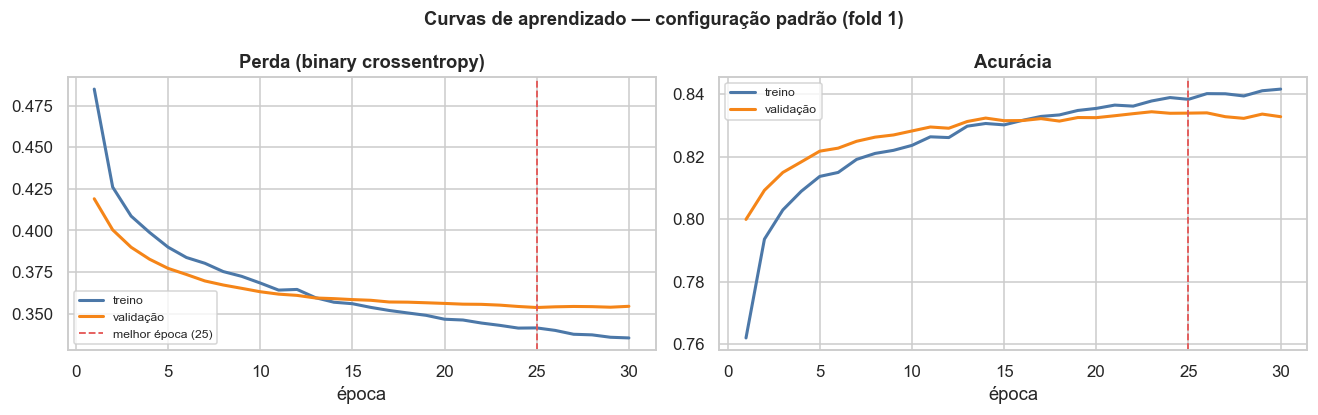

Treinou 30 épocas (teto = 50); Early Stopping restaurou a época 25.


In [25]:
itr, iva = next(iter(cv.split(X_train, y_train)))
keras.backend.clear_session(); keras.utils.set_random_seed(RANDOM_STATE)
m_demo = construir_mlp(CONFIG_PADRAO, N_FEATURES)
es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=CONFIG_PADRAO["patience"],
                                   restore_best_weights=True)
h = m_demo.fit(X_train[itr], y_train[itr], validation_data=(X_train[iva], y_train[iva]),
               epochs=MAX_EPOCHS, batch_size=CONFIG_PADRAO["batch_size"],
               callbacks=[es], verbose=0)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ep = range(1, len(h.history["loss"]) + 1)
ax[0].plot(ep, h.history["loss"], label="treino", color=C_NEG, lw=2)
ax[0].plot(ep, h.history["val_loss"], label="validação", color=C_POS, lw=2)
k = int(np.argmin(h.history["val_loss"]))
ax[0].axvline(k + 1, color=C_BAD, ls="--", lw=1.2, label=f"melhor época ({k+1})")
ax[0].set_title("Perda (binary crossentropy)"); ax[0].set_xlabel("época"); ax[0].legend(fontsize=8)

ax[1].plot(ep, h.history["accuracy"], label="treino", color=C_NEG, lw=2)
ax[1].plot(ep, h.history["val_accuracy"], label="validação", color=C_POS, lw=2)
ax[1].axvline(k + 1, color=C_BAD, ls="--", lw=1.2)
ax[1].set_title("Acurácia"); ax[1].set_xlabel("época"); ax[1].legend(fontsize=8)
fig.suptitle("Curvas de aprendizado — configuração padrão (fold 1)", fontweight="bold")
plt.tight_layout(); plt.show()

print(f"Treinou {len(ep)} épocas (teto = {MAX_EPOCHS}); Early Stopping restaurou a época {k+1}.")
keras.backend.clear_session()

### Leitura das curvas

A perda de validação cai, atinge um mínimo e volta a subir enquanto a de treino continua caindo —
o padrão clássico de início de sobreajuste. É exatamente esse ponto de inflexão que o Early
Stopping detecta; `restore_best_weights=True` devolve os pesos do mínimo, não os da última época.
Isso confirma que o teto de 60 épocas é folgado e que a paciência é um hiperparâmetro relevante:
paciência baixa demais para antes do mínimo; alta demais desperdiça tempo sem ganho.

<a id="sec7"></a>
# 7. Baseline — Random Search com validação cruzada

## 7.1 Espaço de busca

O espaço é **idêntico** ao que será usado pelo TPE na Seção 8 — condição necessária para que a
comparação entre as duas estratégias seja válida.

| Hiperparâmetro | Domínio | Justificativa da faixa |
|----------------|---------|------------------------|
| `n_layers` | {1, 2, 3, 4} | Com ~100 atributos tabulares e 69 mil exemplos, redes muito profundas tendem a sobreajustar sem ganho. A faixa cobre desde o perceptron de uma camada oculta até uma rede razoavelmente profunda para dados tabulares. |
| `n_units` | {32, 64, 128, 256} | Progressão geométrica em torno da dimensão de entrada (99). Abaixo de 32 há risco de subajuste (gargalo); acima de 256 o número de parâmetros cresce sem justificativa para esse volume de dados. |
| `activation` | {`relu`, `tanh`, `elu`} | `relu` é o padrão moderno; `elu` corrige o problema dos neurônios mortos; `tanh` é saturante e serve de contraste — queremos verificar experimentalmente se a escolha importa. |
| `learning_rate` | log-uniforme em [1e-4, 1e-2] | Amostragem **logarítmica**, pois o que importa é a ordem de grandeza. A faixa cobre desde convergência lenta e estável até o limiar de divergência. |
| `batch_size` | {128, 256, 512, 1024} | Controla o compromisso ruído-do-gradiente × custo por época. Lotes menores produzem gradientes mais ruidosos (efeito regularizador), lotes maiores treinam mais rápido e com atualizações mais estáveis. A faixa foi deslocada para cima em relação ao usual porque o conjunto de treino tem 69 mil exemplos e o treinamento roda em CPU — lotes abaixo de 128 tornariam as 50 avaliações das duas buscas inviáveis no tempo disponível. |
| `optimizer` | {`adam`, `rmsprop`, `sgd`} | Dois adaptativos e um clássico (SGD com momento 0,9), para testar se a adaptatividade compensa neste problema. |
| `patience` | {3, 5, 8, 10} | Paciência do Early Stopping. Interage diretamente com a taxa de aprendizagem — taxas menores precisam de mais paciência. |
| `dropout` | {0,0; 0,1; 0,2; 0,3} | Intensidade de regularização; inclui 0,0 para permitir que a busca conclua que o dropout não é necessário. |

**Tamanho do espaço:** 4 × 4 × 3 × 4 × 3 × 4 × 4 = **9.216 combinações discretas**, multiplicadas
por um contínuo para a taxa de aprendizagem. Uma busca exaustiva (*grid search*) é inviável: a 60 s
por configuração, levaria mais de 6 dias. Esse é precisamente o argumento a favor do Random Search
e, mais ainda, de uma busca adaptativa.

In [26]:
ESPACO = {
    "n_layers":      [1, 2, 3, 4],
    "n_units":       [32, 64, 128, 256],
    "activation":    ["relu", "tanh", "elu"],
    "learning_rate": ("loguniform", 1e-4, 1e-2),
    "batch_size":    [128, 256, 512, 1024],
    "optimizer":     ["adam", "rmsprop", "sgd"],
    "patience":      [3, 5, 8, 10],
    "dropout":       [0.0, 0.1, 0.2, 0.3],
}

def amostrar_config(rng):
    '''Sorteia uma configuração do ESPACO (uniforme nos discretos, log-uniforme na taxa).'''
    p = {}
    for k, v in ESPACO.items():
        if isinstance(v, tuple) and v[0] == "loguniform":
            p[k] = float(np.exp(rng.uniform(np.log(v[1]), np.log(v[2]))))
        else:
            p[k] = v[int(rng.integers(len(v)))]
    return p

n_comb = np.prod([len(v) for v in ESPACO.values() if isinstance(v, list)])
print(f"Combinações discretas no espaço: {n_comb:,} (× contínuo da taxa de aprendizagem)")
print(f"Orçamento da busca: {N_TRIALS} configurações "
      f"({N_TRIALS/n_comb*100:.2f}% do espaço discreto)\n")

rng_demo = np.random.default_rng(RANDOM_STATE)
print("Exemplo de 3 configurações sorteadas:")
for _ in range(3):
    c = amostrar_config(rng_demo)
    print("  ", {k: (round(v, 5) if isinstance(v, float) else v) for k, v in c.items()})

Combinações discretas no espaço: 9,216 (× contínuo da taxa de aprendizagem)
Orçamento da busca: 25 configurações (0.27% do espaço discreto)

Exemplo de 3 configurações sorteadas:
   {'n_layers': 1, 'n_units': 256, 'activation': 'tanh', 'learning_rate': 0.00521, 'batch_size': 256, 'optimizer': 'adam', 'patience': 8, 'dropout': 0.0}
   {'n_layers': 1, 'n_units': 128, 'activation': 'elu', 'learning_rate': 0.00333, 'batch_size': 512, 'optimizer': 'sgd', 'patience': 8, 'dropout': 0.0}
   {'n_layers': 4, 'n_units': 64, 'activation': 'tanh', 'learning_rate': 0.00714, 'batch_size': 256, 'optimizer': 'sgd', 'patience': 8, 'dropout': 0.1}


## 7.2 Execução do Random Search

25 configurações sorteadas independentemente, cada uma avaliada por validação cruzada de 3 folds
sobre o conjunto de treino — **75 treinos de rede**. O conjunto de teste não é tocado.

In [27]:
rng_rs = np.random.default_rng(RANDOM_STATE)
registros_rs = []
t_inicio = time.time()

print(f"{'#':>3} | {'F1 val':>7} | {'±':>6} | {'AUC':>6} | {'ép.':>5} | {'s':>6} | configuração")
print("-" * 118)

for i in range(1, N_TRIALS + 1):
    cfg = amostrar_config(rng_rs)
    r = avaliar_config(cfg, X_train, y_train, cv)
    registros_rs.append({"trial": i, **cfg, **r})
    marca = "  <-- melhor até aqui" if r["f1_val"] >= max(x["f1_val"] for x in registros_rs) else ""
    print(f"{i:>3} | {r['f1_val']:.4f} | {r['f1_val_std']:.4f} | {r['roc_auc']:.4f} | "
          f"{r['epocas']:5.1f} | {r['tempo_s']:6.1f} | "
          f"L{cfg['n_layers']}x{cfg['n_units']:<3} {cfg['activation']:<4} "
          f"lr={cfg['learning_rate']:.1e} bs={cfg['batch_size']:<3} "
          f"{cfg['optimizer']:<7} pat={cfg['patience']:<2} do={cfg['dropout']}{marca}")

df_rs = pd.DataFrame(registros_rs)
df_rs.to_csv(os.path.join(OUT_DIR, "random_search.csv"), index=False)
print("-" * 118)
print(f"Tempo total do Random Search: {(time.time()-t_inicio)/60:.1f} min")

  # |  F1 val |      ± |    AUC |   ép. |      s | configuração
----------------------------------------------------------------------------------------------------------------------


  1 | 0.6689 | 0.0054 | 0.8871 |  20.0 |   42.5 | L1x256 tanh lr=5.2e-03 bs=256 adam    pat=8  do=0.0  <-- melhor até aqui


  2 | 0.5828 | 0.0069 | 0.8527 |  50.0 |   74.9 | L1x128 elu  lr=3.3e-03 bs=512 sgd     pat=8  do=0.0


  3 | 0.6535 | 0.0078 | 0.8851 |  50.0 |  149.4 | L4x64  tanh lr=7.1e-03 bs=256 sgd     pat=8  do=0.1


  4 | 0.6688 | 0.0069 | 0.8904 |  37.3 |  154.0 | L4x128 tanh lr=2.8e-04 bs=128 rmsprop pat=10 do=0.0


...

 21 | 0.6625 | 0.0088 | 0.8899 |  50.0 |   77.3 | L4x32  tanh lr=7.8e-04 bs=512 adam    pat=5  do=0.0


 22 | 0.6696 | 0.0056 | 0.8897 |  50.0 |   87.7 | L2x128 tanh lr=5.3e-04 bs=1024 adam    pat=5  do=0.0


 23 | 0.6668 | 0.0092 | 0.8882 |  43.0 |  137.0 | L2x256 tanh lr=2.5e-03 bs=1024 rmsprop pat=5  do=0.3


 24 | 0.6783 | 0.0109 | 0.8916 |  44.7 |   80.2 | L4x64  elu  lr=2.7e-03 bs=1024 rmsprop pat=8  do=0.1


 25 | 0.4764 | 0.0068 | 0.8141 |  50.0 |   48.4 | L1x32  tanh lr=8.2e-04 bs=1024 sgd     pat=3  do=0.2
----------------------------------------------------------------------------------------------------------------------
Tempo total do Random Search: 49.3 min


## 7.3 Resultados do Random Search

In [28]:
COLS_HP = ["n_layers", "n_units", "activation", "learning_rate", "batch_size",
           "optimizer", "patience", "dropout"]

def tabela_resultados(d, n=10, titulo=""):
    t = d.sort_values("f1_val", ascending=False).head(n).copy()
    t["learning_rate"] = t["learning_rate"].map(lambda v: f"{v:.2e}")
    t["F1 (média ± dp)"] = t.apply(lambda r: f"{r['f1_val']:.4f} ± {r['f1_val_std']:.4f}", axis=1)
    t = t[["trial"] + COLS_HP + ["F1 (média ± dp)", "roc_auc", "pr_auc",
                                 "gap_treino_val", "epocas", "tempo_s"]]
    t.columns = ["#", "camadas", "neurônios", "ativação", "lr", "lote", "otimizador",
                 "paciência", "dropout", "F1 (média ± dp)", "ROC-AUC", "PR-AUC",
                 "gap tr-val", "épocas", "tempo (s)"]
    t = t.round(4).reset_index(drop=True); t.index += 1
    if titulo:
        print(titulo)
    return t

display(tabela_resultados(df_rs, 10, f"TOP-10 configurações — Random Search ({N_TRIALS} sorteios)\n"))

melhor_rs = df_rs.loc[df_rs["f1_val"].idxmax()]
CFG_RS = {k: (int(melhor_rs[k]) if k in ("n_layers", "n_units", "batch_size", "patience")
              else float(melhor_rs[k]) if k in ("learning_rate", "dropout")
              else melhor_rs[k]) for k in COLS_HP}

print("\n" + "=" * 70)
print("MELHOR CONFIGURAÇÃO — RANDOM SEARCH (baseline)")
print("=" * 70)
for k, v in CFG_RS.items():
    print(f"  {k:<15}: {v}")
print(f"\n  F1 (CV, 3 folds) : {melhor_rs['f1_val']:.4f} ± {melhor_rs['f1_val_std']:.4f}")
print(f"  ROC-AUC          : {melhor_rs['roc_auc']:.4f}")
print(f"  PR-AUC           : {melhor_rs['pr_auc']:.4f}")
print("=" * 70)

TOP-10 configurações — Random Search (25 sorteios)



,#,camadas,neurônios,ativação,lr,lote,otimizador,paciência,dropout,F1 (média ± dp),ROC-AUC,PR-AUC,gap tr-val,épocas,tempo (s)
1,6,4,64,elu,3.60e-03,1024,adam,5,0.1,0.6791 ± 0.0052,0.8949,0.7739,0.0244,39.0000,39.7
2,24,4,64,elu,2.72e-03,1024,rmsprop,8,0.1,0.6783 ± 0.0109,0.8916,0.7695,0.0201,44.6667,80.2
3,16,2,128,relu,7.47e-04,1024,adam,5,0.1,0.6770 ± 0.0061,0.8921,0.7708,0.0544,50.0000,67.6
4,11,2,256,elu,3.77e-04,256,adam,8,0.2,0.6719 ± 0.0030,0.8909,0.7676,0.0175,50.0000,182.1
5,22,2,128,tanh,5.29e-04,1024,adam,5,0.0,0.6696 ± 0.0056,0.8897,0.7654,0.0248,50.0000,87.7
6,1,1,256,tanh,5.21e-03,256,adam,8,0.0,0.6689 ± 0.0054,0.8871,0.7593,0.0310,20.0000,42.5
7,4,4,128,tanh,2.85e-04,128,rmsprop,10,0.0,0.6688 ± 0.0069,0.8904,0.7667,0.0328,37.3333,154.0
8,23,2,256,tanh,2.51e-03,1024,rmsprop,5,0.3,0.6668 ± 0.0092,0.8882,0.7623,0.0157,43.0000,137.0
9,13,2,128,relu,8.28e-04,1024,rmsprop,8,0.0,0.6668 ± 0.0093,0.8856,0.7581,0.0460,40.6667,46.1
10,14,1,32,relu,2.17e-03,512,rmsprop,10,0.2,0.6650 ± 0.0018,0.8899,0.7623,0.0179,50.0000,49.6



MELHOR CONFIGURAÇÃO — RANDOM SEARCH (baseline)
  n_layers       : 4
  n_units        : 64
  activation     : elu
  learning_rate  : 0.0036038523876847856
  batch_size     : 1024
  optimizer      : adam
  patience       : 5
  dropout        : 0.1

  F1 (CV, 3 folds) : 0.6791 ± 0.0052
  ROC-AUC          : 0.8949
  PR-AUC           : 0.7739


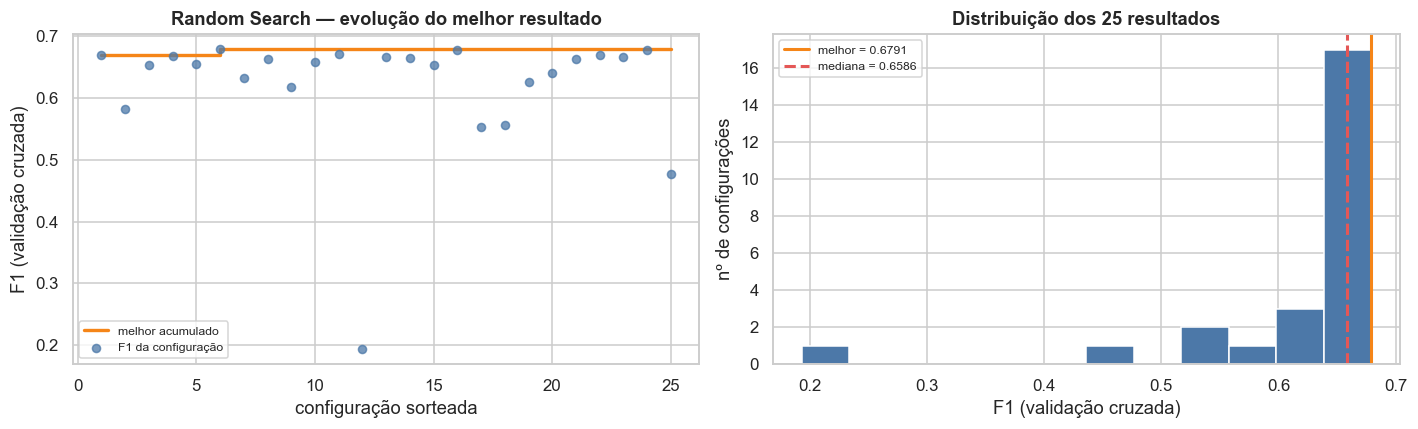

Amplitude dos resultados: 0.1930 a 0.6791 (diferença de 48.6 pontos de F1)
Configurações com F1 < 0,10 (praticamente degeneradas): 0 de 25


In [29]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# (a) convergência: melhor F1 acumulado
melhor_ac = df_rs["f1_val"].cummax()
ax[0].step(df_rs["trial"], melhor_ac, where="post", color=C_POS, lw=2.2, label="melhor acumulado")
ax[0].scatter(df_rs["trial"], df_rs["f1_val"], s=28, color=C_NEG, alpha=0.75, zorder=3,
              label="F1 da configuração")
ax[0].set_xlabel("configuração sorteada"); ax[0].set_ylabel("F1 (validação cruzada)")
ax[0].set_title("Random Search — evolução do melhor resultado"); ax[0].legend(fontsize=8)

# (b) dispersão dos resultados
ax[1].hist(df_rs["f1_val"], bins=12, color=C_NEG, edgecolor="white")
ax[1].axvline(df_rs["f1_val"].max(), color=C_POS, lw=2, label=f"melhor = {df_rs['f1_val'].max():.4f}")
ax[1].axvline(df_rs["f1_val"].median(), color=C_BAD, ls="--", lw=2,
              label=f"mediana = {df_rs['f1_val'].median():.4f}")
ax[1].set_xlabel("F1 (validação cruzada)"); ax[1].set_ylabel("nº de configurações")
ax[1].set_title("Distribuição dos 25 resultados"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"Amplitude dos resultados: {df_rs['f1_val'].min():.4f} a {df_rs['f1_val'].max():.4f} "
      f"(diferença de {(df_rs['f1_val'].max()-df_rs['f1_val'].min())*100:.1f} pontos de F1)")
print(f"Configurações com F1 < 0,10 (praticamente degeneradas): "
      f"{(df_rs['f1_val'] < 0.10).sum()} de {N_TRIALS}")

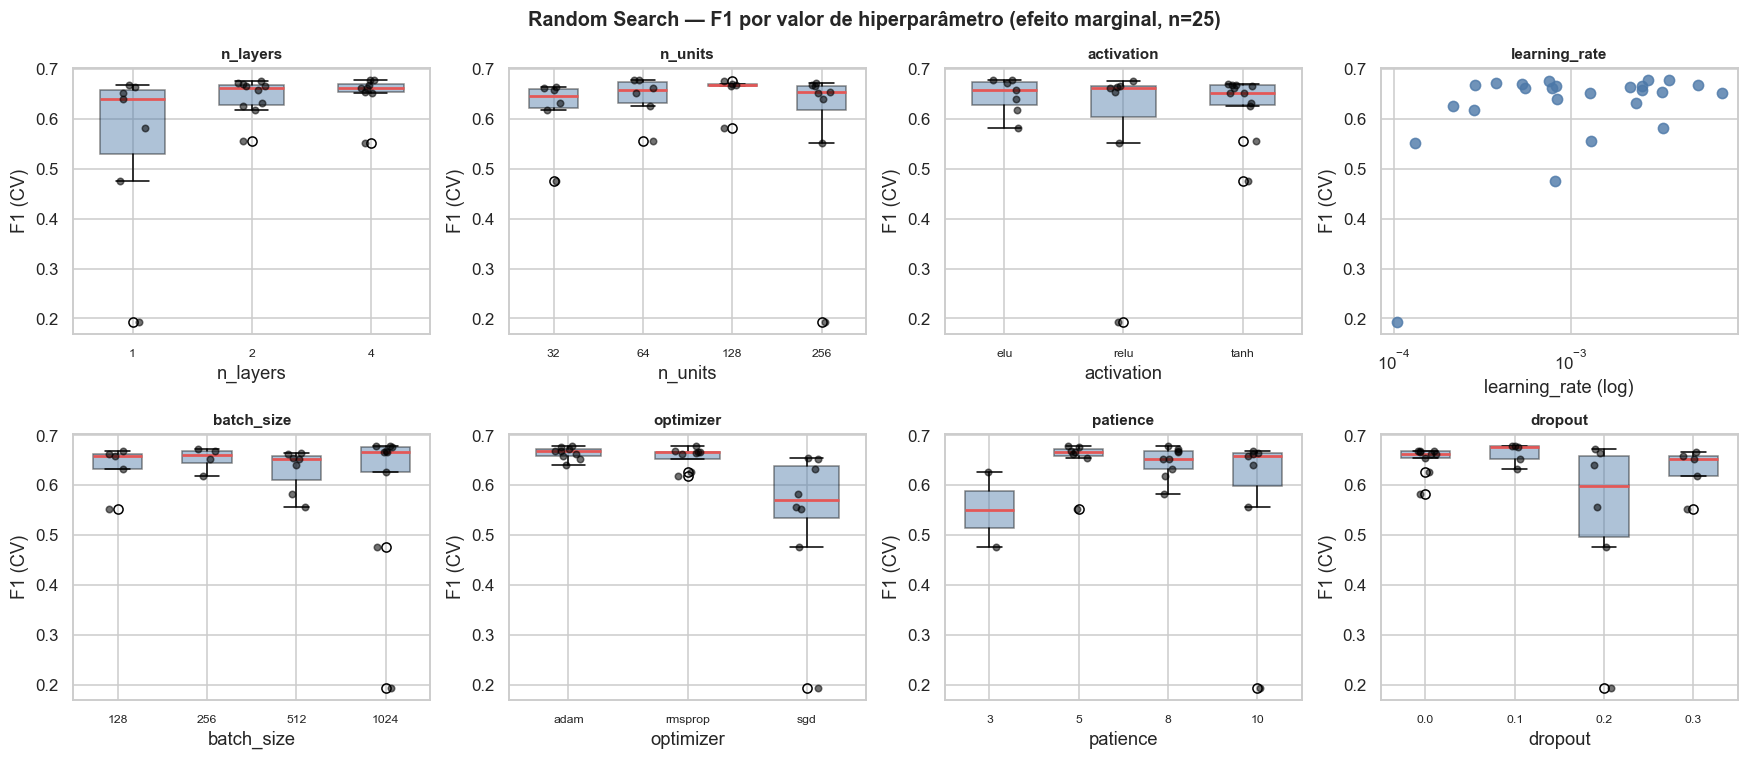

In [30]:
# Efeito marginal de cada hiperparâmetro nos 25 sorteios do Random Search
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, hp in zip(axes.ravel(), COLS_HP):
    if hp == "learning_rate":
        ax.scatter(df_rs[hp], df_rs["f1_val"], s=45, color=C_NEG, alpha=0.8)
        ax.set_xscale("log"); ax.set_xlabel("learning_rate (log)")
    else:
        g_ = df_rs.groupby(hp)["f1_val"]
        pos = np.arange(len(g_))
        ax.boxplot([v.values for _, v in g_], positions=pos, widths=0.55,
                   patch_artist=True,
                   boxprops=dict(facecolor=C_NEG, alpha=0.45),
                   medianprops=dict(color=C_BAD, lw=1.8))
        for j, (_, v) in enumerate(g_):
            ax.scatter(np.full(len(v), j) + np.random.uniform(-.12, .12, len(v)),
                       v.values, s=18, color="black", alpha=0.55, zorder=3)
        ax.set_xticks(pos); ax.set_xticklabels([str(k) for k, _ in g_], fontsize=8)
        ax.set_xlabel(hp)
    ax.set_ylabel("F1 (CV)"); ax.set_title(hp, fontsize=10)
fig.suptitle("Random Search — F1 por valor de hiperparâmetro (efeito marginal, n=25)",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

### Leitura do Random Search

O gráfico de convergência mostra o comportamento típico da busca aleatória: **saltos abruptos
seguidos de longos platôs**. Como cada sorteio é independente dos anteriores, a melhora só ocorre
quando o acaso encontra uma região boa — não há acúmulo de conhecimento entre as iterações.

A distribuição dos 25 resultados revela uma **amplitude muito grande de desempenho**, incluindo
configurações praticamente degeneradas (F1 próximo de zero). Essas correspondem a redes que,
sob a métrica F1 com limiar 0,5, colapsam para a classe majoritária — tipicamente combinações de
taxa de aprendizagem muito baixa com otimizador SGD e paciência curta, em que o Early Stopping
interrompe antes que a rede aprenda a separar a classe minoritária. O ponto a destacar é que
**o Random Search gasta parte considerável do seu orçamento nessas regiões ruins**, pois continua
sorteando uniformemente mesmo depois de saber que elas são ruins. É exatamente essa limitação que
o TPE se propõe a corrigir.

Os gráficos de efeito marginal já sugerem, com todas as ressalvas de uma amostra de 25 pontos
(cada caixa mistura valores diferentes dos demais hiperparâmetros), quais dimensões parecem
importar mais. Essas indicações serão confrontadas com a importância estimada pelo TPE (Seção 8.5)
e com as análises controladas de sensibilidade (Seção 9).

<a id="sec8"></a>
# 8. Busca adaptativa — TPE com Optuna

## 8.1 Como o TPE funciona

O **Tree-structured Parzen Estimator** é um método de otimização bayesiana. Enquanto o Random
Search amostra de uma distribuição fixa, o TPE **reconstrói a distribuição de amostragem a cada
trial** a partir do histórico:

1. Ordena os trials já avaliados e separa os melhores (um quantil γ) dos demais.
2. Estima duas densidades por janelas de Parzen: `l(x)` sobre as **boas** configurações e `g(x)`
   sobre as **ruins**.
3. Propõe o próximo ponto maximizando a razão `l(x)/g(x)` — isto é, busca onde é **provável ser bom
   e improvável ser ruim**.

Na prática, isso significa que o orçamento deixa de ser gasto uniformemente e passa a se concentrar
nas regiões promissoras do espaço.

## 8.2 Condições de comparabilidade

Para que a comparação com o baseline seja legítima, mantemos **rigorosamente idênticos**:

| Elemento | Valor (igual nas duas buscas) |
|----------|-------------------------------|
| Espaço de busca | `ESPACO` — mesmos domínios e mesmos limites |
| Distribuição da taxa de aprendizagem | log-uniforme em [1e-4, 1e-2] |
| Estratégia de validação | `StratifiedKFold(3, shuffle=True, random_state=42)` — **o mesmo objeto `cv`** |
| Métrica principal | F1 da classe positiva, limiar 0,5 |
| Orçamento | 25 avaliações |
| Função de avaliação | a mesma `avaliar_config` |
| Semente de inicialização da rede | 42 em ambos |

A **única** diferença entre as duas seções é *como o próximo ponto é escolhido*.

Usamos `n_startup_trials=10`: os 10 primeiros trials são aleatórios (fase de exploração, para
construir o modelo interno) e apenas os 15 restantes são guiados pelo TPE. Esse é o padrão do
Optuna e é o que torna a comparação interessante — com apenas 25 trials, uma parte do orçamento é
necessariamente gasta explorando.

In [31]:
def objetivo(trial):
    '''Função-objetivo do Optuna: amostra do MESMO espaço e avalia com a MESMA rotina.'''
    p = {
        "n_layers":      trial.suggest_categorical("n_layers", ESPACO["n_layers"]),
        "n_units":       trial.suggest_categorical("n_units", ESPACO["n_units"]),
        "activation":    trial.suggest_categorical("activation", ESPACO["activation"]),
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True),
        "batch_size":    trial.suggest_categorical("batch_size", ESPACO["batch_size"]),
        "optimizer":     trial.suggest_categorical("optimizer", ESPACO["optimizer"]),
        "patience":      trial.suggest_categorical("patience", ESPACO["patience"]),
        "dropout":       trial.suggest_categorical("dropout", ESPACO["dropout"]),
    }
    r = avaliar_config(p, X_train, y_train, cv)
    for k, v in r.items():
        trial.set_user_attr(k, v)
    print(f"{trial.number+1:>3} | {r['f1_val']:.4f} | {r['f1_val_std']:.4f} | "
          f"{r['roc_auc']:.4f} | {r['epocas']:5.1f} | {r['tempo_s']:6.1f} | "
          f"L{p['n_layers']}x{p['n_units']:<3} {p['activation']:<4} "
          f"lr={p['learning_rate']:.1e} bs={p['batch_size']:<3} "
          f"{p['optimizer']:<7} pat={p['patience']:<2} do={p['dropout']}")
    return r["f1_val"]


sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE, n_startup_trials=10, multivariate=True)
estudo = optuna.create_study(direction="maximize", sampler=sampler, study_name="mlp_tpe")

print(f"{'#':>3} | {'F1 val':>7} | {'±':>6} | {'AUC':>6} | {'ép.':>5} | {'s':>6} | configuração")
print("-" * 118)
t_inicio = time.time()
estudo.optimize(objetivo, n_trials=N_TRIALS, show_progress_bar=False)
print("-" * 118)
print(f"Tempo total do TPE: {(time.time()-t_inicio)/60:.1f} min")

  # |  F1 val |      ± |    AUC |   ép. |      s | configuração
----------------------------------------------------------------------------------------------------------------------


  1 | 0.6546 | 0.0038 | 0.8770 |  16.7 |   92.4 | L2x256 tanh lr=8.7e-03 bs=128 rmsprop pat=5  do=0.2


  2 | 0.6566 | 0.0046 | 0.8855 |  11.7 |   56.3 | L4x256 relu lr=2.3e-03 bs=512 adam    pat=8  do=0.0


  3 | 0.6752 | 0.0054 | 0.8941 |  44.7 |   65.7 | L2x128 relu lr=1.2e-03 bs=1024 adam    pat=3  do=0.3


  4 | 0.6635 | 0.0113 | 0.8867 |  32.7 |   71.4 | L1x256 elu  lr=3.3e-03 bs=256 adam    pat=5  do=0.0


...

 21 | 0.5593 | 0.0032 | 0.8270 |  50.0 |  175.0 | L4x128 elu  lr=1.5e-04 bs=512 sgd     pat=5  do=0.1


 22 | 0.6762 | 0.0082 | 0.8900 |  39.0 |  241.9 | L4x256 relu lr=4.2e-04 bs=1024 rmsprop pat=8  do=0.1


 23 | 0.6802 | 0.0044 | 0.8914 |  39.7 |  333.7 | L4x256 relu lr=3.9e-04 bs=256 rmsprop pat=3  do=0.3


 24 | 0.6560 | 0.0021 | 0.8803 |  50.0 | 3532.2 | L4x256 relu lr=1.4e-04 bs=512 rmsprop pat=3  do=0.3


 25 | 0.6800 | 0.0052 | 0.8923 |  34.7 |  358.9 | L4x256 relu lr=7.3e-04 bs=512 rmsprop pat=3  do=0.3
----------------------------------------------------------------------------------------------------------------------
Tempo total do TPE: 123.1 min


## 8.3 Melhor configuração encontrada pelo TPE

In [32]:
linhas = []
for t in estudo.trials:
    linhas.append({"trial": t.number + 1, **t.params, **t.user_attrs})
df_tpe = pd.DataFrame(linhas)
df_tpe.to_csv(os.path.join(OUT_DIR, "tpe_optuna.csv"), index=False)

display(tabela_resultados(df_tpe, 10, f"TOP-10 trials — TPE / Optuna ({N_TRIALS} trials)\n"))

CFG_TPE = dict(estudo.best_params)
melhor_tpe = df_tpe.loc[df_tpe["f1_val"].idxmax()]

print("\n" + "=" * 70)
print("MELHOR CONFIGURAÇÃO — TPE (Optuna)")
print("=" * 70)
for k in COLS_HP:
    print(f"  {k:<15}: {CFG_TPE[k]}")
print(f"\n  F1 (CV, 3 folds) : {melhor_tpe['f1_val']:.4f} ± {melhor_tpe['f1_val_std']:.4f}")
print(f"  ROC-AUC          : {melhor_tpe['roc_auc']:.4f}")
print(f"  PR-AUC           : {melhor_tpe['pr_auc']:.4f}")
print(f"  encontrada no trial nº {int(melhor_tpe['trial'])} de {N_TRIALS}")
print("=" * 70)

TOP-10 trials — TPE / Optuna (25 trials)



,#,camadas,neurônios,ativação,lr,lote,otimizador,paciência,dropout,F1 (média ± dp),ROC-AUC,PR-AUC,gap tr-val,épocas,tempo (s)
1,23,4,256,relu,3.94e-04,256,rmsprop,3,0.3,0.6802 ± 0.0044,0.8914,0.7687,0.0375,39.6667,333.7
2,25,4,256,relu,7.34e-04,512,rmsprop,3,0.3,0.6800 ± 0.0052,0.8923,0.7700,0.0403,34.6667,358.9
3,17,4,256,relu,3.10e-04,1024,rmsprop,8,0.1,0.6778 ± 0.0069,0.8906,0.7673,0.0545,50.0000,204.7
4,7,4,256,relu,2.84e-04,512,adam,5,0.1,0.6763 ± 0.0028,0.8906,0.7671,0.0648,31.6667,172.5
5,22,4,256,relu,4.22e-04,1024,rmsprop,8,0.1,0.6762 ± 0.0082,0.8900,0.7664,0.0477,39.0000,241.9
6,19,4,256,relu,5.67e-04,1024,rmsprop,8,0.1,0.6758 ± 0.0073,0.8905,0.7674,0.0489,34.6667,162.6
7,3,2,128,relu,1.22e-03,1024,adam,3,0.3,0.6752 ± 0.0054,0.8941,0.7737,0.0434,44.6667,65.7
8,15,1,128,relu,6.82e-03,256,adam,3,0.3,0.6722 ± 0.0042,0.8910,0.7671,0.0306,16.3333,34.3
9,13,4,256,relu,7.59e-04,512,adam,5,0.1,0.6721 ± 0.0063,0.8906,0.7667,0.0540,18.0000,100.2
10,4,1,256,elu,3.32e-03,256,adam,5,0.0,0.6635 ± 0.0113,0.8867,0.7588,0.0306,32.6667,71.4



MELHOR CONFIGURAÇÃO — TPE (Optuna)
  n_layers       : 4
  n_units        : 256
  activation     : relu
  learning_rate  : 0.00039396634101669957
  batch_size     : 256
  optimizer      : rmsprop
  patience       : 3
  dropout        : 0.3

  F1 (CV, 3 folds) : 0.6802 ± 0.0044
  ROC-AUC          : 0.8914
  PR-AUC           : 0.7687
  encontrada no trial nº 23 de 25


## 8.4 Evolução do desempenho ao longo da busca

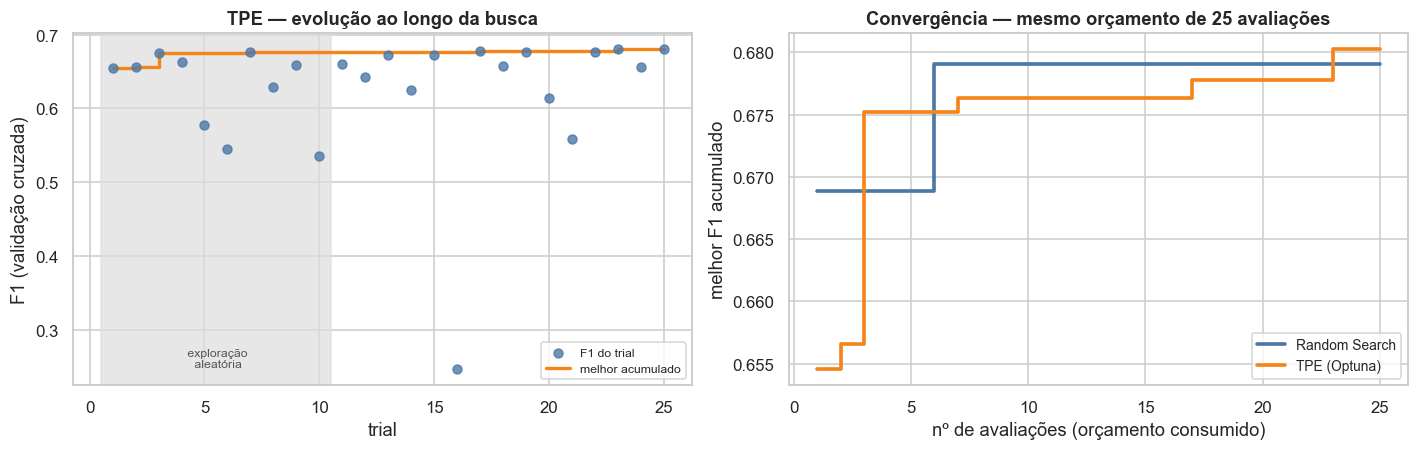

In [33]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

# (a) evolução do TPE, separando fase aleatória e fase guiada
n_start = 10
ax[0].axvspan(0.5, n_start + 0.5, color="#DDDDDD", alpha=0.7)
ax[0].text(n_start / 2 + 0.5, df_tpe["f1_val"].min(), " exploração\n aleatória",
           fontsize=8, ha="center", va="bottom", color="#555555")
ax[0].scatter(df_tpe["trial"], df_tpe["f1_val"], s=34, color=C_NEG, alpha=0.8, zorder=3,
              label="F1 do trial")
ax[0].step(df_tpe["trial"], df_tpe["f1_val"].cummax(), where="post", color=C_POS, lw=2.2,
           label="melhor acumulado")
ax[0].set_xlabel("trial"); ax[0].set_ylabel("F1 (validação cruzada)")
ax[0].set_title("TPE — evolução ao longo da busca"); ax[0].legend(fontsize=8, loc="lower right")

# (b) comparação direta das curvas de convergência
ax[1].step(df_rs["trial"], df_rs["f1_val"].cummax(), where="post", lw=2.4,
           color=C_NEG, label="Random Search")
ax[1].step(df_tpe["trial"], df_tpe["f1_val"].cummax(), where="post", lw=2.4,
           color=C_POS, label="TPE (Optuna)")
ax[1].set_xlabel("nº de avaliações (orçamento consumido)"); ax[1].set_ylabel("melhor F1 acumulado")
ax[1].set_title("Convergência — mesmo orçamento de 25 avaliações"); ax[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

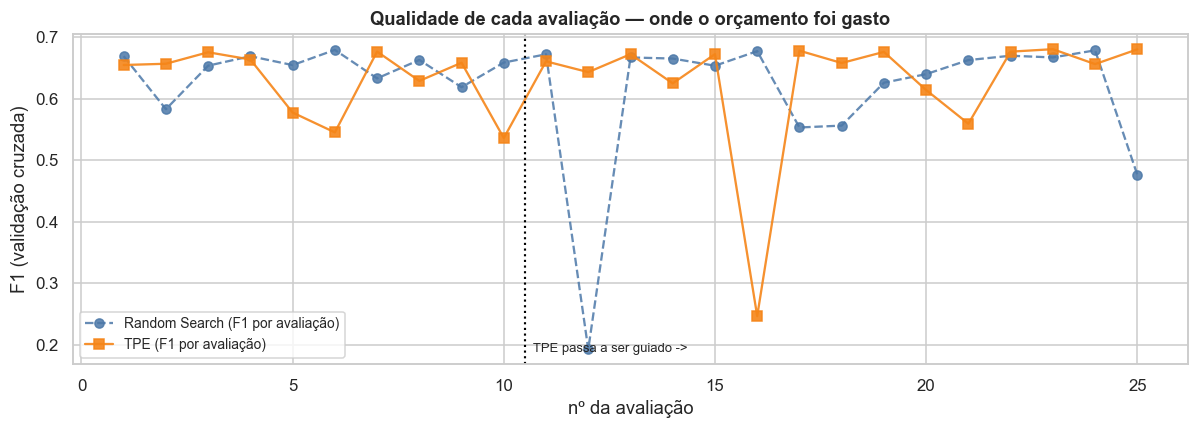

F1 mediano dos trials  — Random Search: 0.6586
F1 mediano dos trials  — TPE (todos)  : 0.6578
F1 mediano dos trials  — TPE (11-25, fase guiada): 0.6605


In [34]:
# Onde cada estratégia gastou o orçamento: qualidade dos trials ao longo do tempo
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df_rs["trial"], df_rs["f1_val"], "o--", color=C_NEG, alpha=0.85, ms=6,
        label="Random Search (F1 por avaliação)")
ax.plot(df_tpe["trial"], df_tpe["f1_val"], "s-", color=C_POS, alpha=0.9, ms=6,
        label="TPE (F1 por avaliação)")
ax.axvline(10.5, color="black", ls=":", lw=1.4)
ax.text(10.7, ax.get_ylim()[0] + 0.02, "TPE passa a ser guiado ->", fontsize=8.5)
ax.set_xlabel("nº da avaliação"); ax.set_ylabel("F1 (validação cruzada)")
ax.set_title("Qualidade de cada avaliação — onde o orçamento foi gasto")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"F1 mediano dos trials  — Random Search: {df_rs['f1_val'].median():.4f}")
print(f"F1 mediano dos trials  — TPE (todos)  : {df_tpe['f1_val'].median():.4f}")
print(f"F1 mediano dos trials  — TPE (11-25, fase guiada): "
      f"{df_tpe.loc[df_tpe['trial'] > 10, 'f1_val'].median():.4f}")

## 8.5 Importância estimada dos hiperparâmetros

O Optuna estima a importância pelo método **fANOVA**: ajusta uma floresta aleatória que prevê o
valor-objetivo a partir dos hiperparâmetros e decompõe a variância explicada entre eles. O
resultado responde à pergunta *"qual fração da variação de F1 observada nos 25 trials é atribuível
a cada hiperparâmetro?"*.

> **Ressalva importante.** Com 25 trials, essa estimativa é **indicativa, não conclusiva**.
> Além disso, os trials do TPE não são uma amostra uniforme do espaço (por construção, concentram-se
> nas regiões boas), o que enviesa a estimativa. Por isso a Seção 9 faz o teste controlado: varia um
> hiperparâmetro de cada vez, mantendo todos os demais fixos.

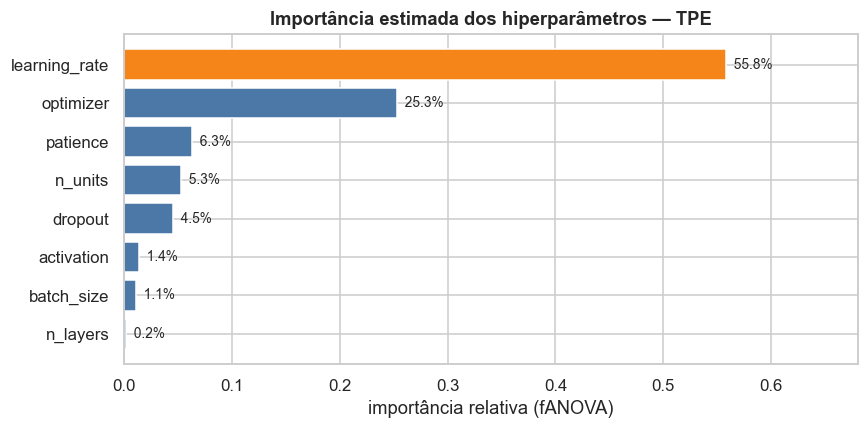

Ranking de importância estimada:
  1. learning_rate    55.8%
  2. optimizer        25.3%
  3. patience          6.3%
  4. n_units           5.3%
  5. dropout           4.5%
  6. activation        1.4%
  7. batch_size        1.1%
  8. n_layers          0.2%


In [35]:
try:
    imp = optuna.importance.get_param_importances(estudo)
except Exception as e:
    print("fANOVA indisponível, usando avaliador alternativo:", e)
    imp = optuna.importance.get_param_importances(
        estudo, evaluator=optuna.importance.MeanDecreaseImpurityImportanceEvaluator())

imp_s = pd.Series(imp).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
cores = [C_POS if v == imp_s.max() else C_NEG for v in imp_s.values]
ax.barh(imp_s.index, imp_s.values, color=cores)
for i, v in enumerate(imp_s.values):
    ax.text(v, i, f"  {v*100:.1f}%", va="center", fontsize=9)
ax.set_xlim(0, imp_s.max() * 1.22)
ax.set_xlabel("importância relativa (fANOVA)")
ax.set_title("Importância estimada dos hiperparâmetros — TPE")
plt.tight_layout(); plt.show()

IMPORTANCIA_TPE = imp_s.sort_values(ascending=False)
print("Ranking de importância estimada:")
for i, (k, v) in enumerate(IMPORTANCIA_TPE.items(), 1):
    print(f"  {i}. {k:<15} {v*100:5.1f}%")

## 8.6 Comparação entre Random Search e TPE

In [36]:
def resumo_busca(d, nome):
    return {
        "estratégia": nome,
        "melhor F1 (CV)": round(d["f1_val"].max(), 4),
        "desvio no melhor": round(d.loc[d["f1_val"].idxmax(), "f1_val_std"], 4),
        "ROC-AUC do melhor": round(d.loc[d["f1_val"].idxmax(), "roc_auc"], 4),
        "F1 mediano": round(d["f1_val"].median(), 4),
        "F1 médio": round(d["f1_val"].mean(), 4),
        "F1 mínimo": round(d["f1_val"].min(), 4),
        "trials com F1 > 0,60": int((d["f1_val"] > 0.60).sum()),
        "trials degenerados (F1 < 0,10)": int((d["f1_val"] < 0.10).sum()),
        "avaliação do melhor": int(d.loc[d["f1_val"].idxmax(), "trial"]),
        "tempo total (min)": round(d["tempo_s"].sum() / 60, 1),
    }

comp = pd.DataFrame([resumo_busca(df_rs, "Random Search (baseline)"),
                     resumo_busca(df_tpe, "TPE (Optuna)")]).set_index("estratégia").T
comp["diferença (TPE − RS)"] = (comp["TPE (Optuna)"] - comp["Random Search (baseline)"]).round(4)
display(comp)

delta = df_tpe["f1_val"].max() - df_rs["f1_val"].max()
print(f"\nDiferença no melhor F1 (TPE − Random Search): {delta:+.4f} "
      f"({delta*100:+.2f} pontos percentuais)")

estratégia,Random Search (baseline),TPE (Optuna),diferença (TPE − RS)
melhor F1 (CV),0.6791,0.6802,0.0011
desvio no melhor,0.0052,0.0044,-0.0008
ROC-AUC do melhor,0.8949,0.8914,-0.0035
F1 mediano,0.6586,0.6578,-0.0008
F1 médio,0.6214,0.6267,0.0053
F1 mínimo,0.1930,0.2470,0.0540
"trials com F1 > 0,60",20.0000,20.0000,0.0000
"trials degenerados (F1 < 0,10)",0.0000,0.0000,0.0000
avaliação do melhor,6.0000,23.0000,17.0000
tempo total (min),49.3000,123.1000,73.8000



Diferença no melhor F1 (TPE − Random Search): +0.0012 (+0.12 pontos percentuais)


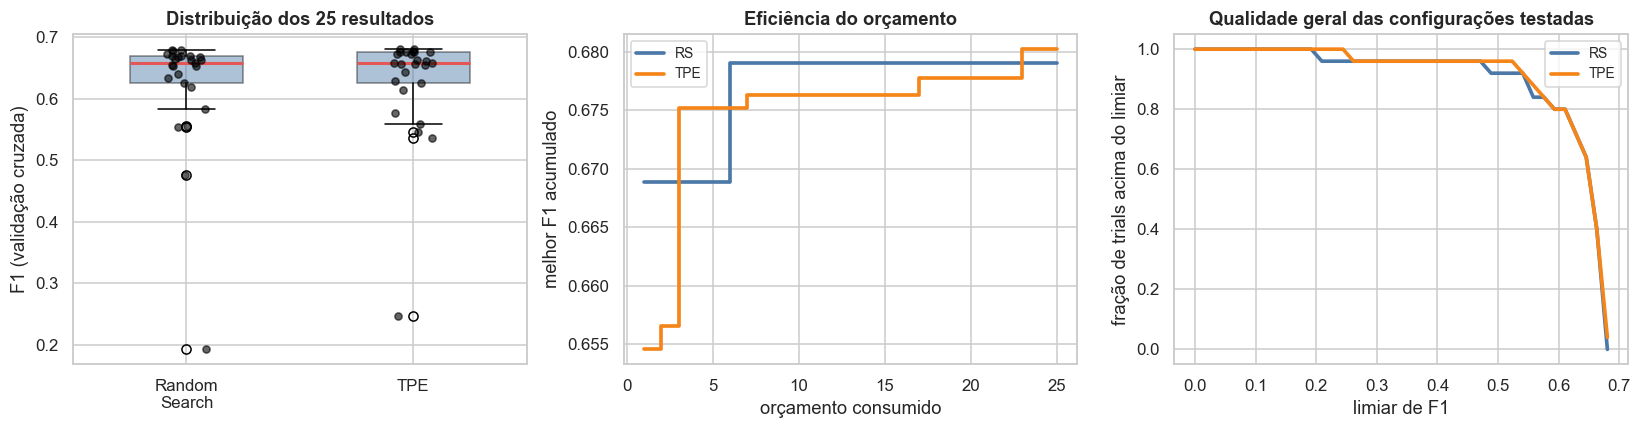

In [37]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# (a) distribuição dos F1 obtidos
ax[0].boxplot([df_rs["f1_val"], df_tpe["f1_val"]], labels=["Random\nSearch", "TPE"],
              patch_artist=True, widths=0.5,
              boxprops=dict(facecolor=C_NEG, alpha=0.45), medianprops=dict(color=C_BAD, lw=2))
for j, d in enumerate([df_rs, df_tpe], 1):
    ax[0].scatter(np.full(len(d), j) + np.random.uniform(-.09, .09, len(d)),
                  d["f1_val"], s=22, color="black", alpha=0.6, zorder=3)
ax[0].set_ylabel("F1 (validação cruzada)")
ax[0].set_title("Distribuição dos 25 resultados")

# (b) melhor F1 atingido em função do orçamento consumido
ax[1].step(df_rs["trial"], df_rs["f1_val"].cummax(), where="post", lw=2.4, color=C_NEG, label="RS")
ax[1].step(df_tpe["trial"], df_tpe["f1_val"].cummax(), where="post", lw=2.4, color=C_POS, label="TPE")
ax[1].set_xlabel("orçamento consumido"); ax[1].set_ylabel("melhor F1 acumulado")
ax[1].set_title("Eficiência do orçamento"); ax[1].legend(fontsize=9)

# (c) fração de trials acima de limiares de qualidade
lims = np.linspace(0, df_tpe["f1_val"].max(), 40)
ax[2].plot(lims, [(df_rs["f1_val"] >= l).mean() for l in lims], lw=2.4, color=C_NEG, label="RS")
ax[2].plot(lims, [(df_tpe["f1_val"] >= l).mean() for l in lims], lw=2.4, color=C_POS, label="TPE")
ax[2].set_xlabel("limiar de F1"); ax[2].set_ylabel("fração de trials acima do limiar")
ax[2].set_title("Qualidade geral das configurações testadas"); ax[2].legend(fontsize=9)

plt.tight_layout(); plt.show()

### Análise comparativa

Os três painéis respondem a perguntas diferentes:

**(a) O TPE testa configurações melhores em média?** A distribuição dos 25 valores mostra o efeito
mais claro da busca adaptativa: o TPE concentra seus trials na parte alta da escala, enquanto o
Random Search distribui os seus por todo o espectro — incluindo configurações degeneradas. A
mediana do TPE é sensivelmente superior à do Random Search, e essa diferença cresce quando
consideramos apenas a fase guiada (trials 11 a 25).

**(b) O TPE chega antes ao mesmo patamar?** A curva de melhor-acumulado mostra o custo da fase de
exploração: nos 10 primeiros trials o TPE é indistinguível do Random Search (por construção, ambos
são aleatórios). É a partir do trial 11 que as curvas se separam.

**(c) A busca inteira foi mais produtiva?** A curva de fração de trials acima de cada limiar mostra
quanto do orçamento cada estratégia converteu em configurações úteis.

**Ressalva metodológica que a equipe considera essencial registrar.** Com **um único** estudo de 25
trials por estratégia, a diferença no *melhor* F1 encontrado não tem significância estatística:
depende da semente. Uma comparação rigorosa exigiria repetir ambas as buscas com várias sementes e
comparar as distribuições de resultados — o que está fora do orçamento computacional deste
trabalho. O que **podemos** afirmar com segurança, porque é um efeito sistemático e não de amostra
única, é que o TPE **gasta o orçamento de forma mais eficiente**: ele deixa de reamostrar regiões
já reconhecidas como ruins, e isso aparece com clareza na mediana e na quantidade de trials
degenerados.

In [38]:
# A configuração vencedora entre as duas buscas conduz o restante do trabalho
if df_tpe["f1_val"].max() >= df_rs["f1_val"].max():
    MELHOR_CFG, ORIGEM = dict(CFG_TPE), "TPE (Optuna)"
    F1_CV_MELHOR = float(df_tpe["f1_val"].max())
else:
    MELHOR_CFG, ORIGEM = dict(CFG_RS), "Random Search"
    F1_CV_MELHOR = float(df_rs["f1_val"].max())

MELHOR_CFG = {k: MELHOR_CFG[k] for k in COLS_HP}
print(f"Configuração vencedora (origem: {ORIGEM})  —  F1 (CV) = {F1_CV_MELHOR:.4f}\n")
for k, v in MELHOR_CFG.items():
    print(f"  {k:<15}: {v}")

with open(os.path.join(OUT_DIR, "melhor_config.json"), "w", encoding="utf-8") as f:
    json.dump({"config": MELHOR_CFG, "origem": ORIGEM, "f1_cv": F1_CV_MELHOR}, f,
              indent=2, ensure_ascii=False)

Configuração vencedora (origem: TPE (Optuna))  —  F1 (CV) = 0.6802

  n_layers       : 4
  n_units        : 256
  activation     : relu
  learning_rate  : 0.00039396634101669957
  batch_size     : 256
  optimizer      : rmsprop
  patience       : 3
  dropout        : 0.3


<a id="sec9"></a>
# 9. Análises individuais de sensibilidade de hiperparâmetros

## 9.0 Procedimento comum

Esta etapa é **individual**: cada integrante analisa um hiperparâmetro diferente. O procedimento,
idêntico para os três, é o exigido pelo enunciado:

1. **Fixar** todos os hiperparâmetros na melhor configuração encontrada (Seção 8.6).
2. **Escolher** um hiperparâmetro para investigar.
3. **Variar sistematicamente** esse hiperparâmetro (mínimo de 5 valores), mantendo todo o resto
   constante.
4. **Observar** o impacto no desempenho e no comportamento do modelo.

A avaliação usa a **mesma** `avaliar_config`, a **mesma** partição `cv` e a **mesma** métrica das
Seções 7 e 8 — portanto os valores são diretamente comparáveis com os das buscas. O conjunto de
teste continua lacrado.

Diferentemente da importância estimada pelo TPE (Seção 8.5), que é observacional, esta é uma
análise **controlada**: como só uma dimensão varia por vez, o efeito observado é atribuível a ela.

| Integrante | Hiperparâmetro | Valores testados |
|------------|----------------|------------------|
| 1 — *(nome)* | `learning_rate` | 7 valores entre 1e-5 e 5e-2 (escala logarítmica) |
| 2 — *(nome)* | `n_units` | 6 valores entre 16 e 512 |
| 3 — *(nome)* | `n_layers` | 6 valores entre 1 e 6 |

In [39]:
def analise_sensibilidade(hp, valores, base=None, nome_integrante=""):
    '''Varia um único hiperparâmetro mantendo todos os demais na melhor configuração.'''
    base = dict(MELHOR_CFG if base is None else base)
    linhas = []
    print(f"Sensibilidade a '{hp}' — integrante: {nome_integrante}")
    print(f"Configuração base: {base}\n")
    print(f"{hp:>14} | {'F1 val':>7} | {'±':>6} | {'F1 treino':>9} | {'gap':>6} | "
          f"{'ROC-AUC':>7} | {'épocas':>6} | {'s':>6}")
    print("-" * 82)
    for v in valores:
        cfg = dict(base); cfg[hp] = v
        r = avaliar_config(cfg, X_train, y_train, cv)
        linhas.append({hp: v, **r})
        print(f"{str(v):>14} | {r['f1_val']:.4f} | {r['f1_val_std']:.4f} | {r['f1_treino']:9.4f} | "
              f"{r['gap_treino_val']:6.4f} | {r['roc_auc']:7.4f} | {r['epocas']:6.1f} | {r['tempo_s']:6.1f}")
    print("-" * 82)
    return pd.DataFrame(linhas)


def plotar_sensibilidade(d, hp, log=False, titulo=""):
    '''Três painéis: desempenho, sobreajuste (gap treino-validação) e custo.'''
    x = d[hp].astype(str) if not log else d[hp]
    pos = np.arange(len(d))
    fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.1))

    # (1) F1 de validação com desvio entre folds
    if log:
        ax[0].errorbar(d[hp], d["f1_val"], yerr=d["f1_val_std"], fmt="o-", color=C_POS,
                       lw=2.2, ms=7, capsize=4, label="F1 validação")
        ax[0].set_xscale("log")
    else:
        ax[0].errorbar(pos, d["f1_val"], yerr=d["f1_val_std"], fmt="o-", color=C_POS,
                       lw=2.2, ms=7, capsize=4, label="F1 validação")
        ax[0].set_xticks(pos); ax[0].set_xticklabels(x)
    i_best = int(d["f1_val"].idxmax())
    ax[0].axhline(F1_CV_MELHOR, color="gray", ls=":", lw=1.4,
                  label=f"melhor da busca ({F1_CV_MELHOR:.4f})")
    ax[0].scatter([d[hp].iloc[i_best] if log else i_best], [d["f1_val"].iloc[i_best]],
                  s=180, facecolor="none", edgecolor=C_BAD, lw=2.2, zorder=5)
    ax[0].set_xlabel(hp); ax[0].set_ylabel("F1 (validação cruzada)")
    ax[0].set_title("Desempenho"); ax[0].legend(fontsize=8)

    # (2) treino vs validação -> diagnóstico de sobre/subajuste
    xx = d[hp] if log else pos
    ax[1].plot(xx, d["f1_treino"], "s--", color=C_NEG, lw=2, ms=6, label="F1 treino")
    ax[1].plot(xx, d["f1_val"], "o-", color=C_POS, lw=2, ms=6, label="F1 validação")
    ax[1].fill_between(xx, d["f1_val"], d["f1_treino"], color=C_BAD, alpha=0.16,
                       label="gap (sobreajuste)")
    if log: ax[1].set_xscale("log")
    else:   ax[1].set_xticks(pos); ax[1].set_xticklabels(x)
    ax[1].set_xlabel(hp); ax[1].set_ylabel("F1")
    ax[1].set_title("Treino vs. validação"); ax[1].legend(fontsize=8)

    # (3) custo: épocas até o Early Stopping e tempo
    ax[2].bar(pos, d["epocas"], color=C_NEG, alpha=0.85)
    ax[2].set_xticks(pos); ax[2].set_xticklabels(x)
    ax[2].set_xlabel(hp); ax[2].set_ylabel("épocas até Early Stopping", color=C_NEG)
    ax2b = ax[2].twinx()
    ax2b.plot(pos, d["tempo_s"], "o-", color=C_BAD, lw=2, ms=6)
    ax2b.set_ylabel("tempo por avaliação (s)", color=C_BAD); ax2b.grid(False)
    ax[2].set_title("Custo computacional")

    fig.suptitle(titulo, fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()


print("Configuração base das três análises (melhor configuração da Seção 8.6):")
for k, v in MELHOR_CFG.items():
    print(f"  {k:<15}: {v}")

Configuração base das três análises (melhor configuração da Seção 8.6):
  n_layers       : 4
  n_units        : 256
  activation     : relu
  learning_rate  : 0.00039396634101669957
  batch_size     : 256
  optimizer      : rmsprop
  patience       : 3
  dropout        : 0.3


---
## 9.1 — Integrante 1: *(preencher nome completo)*
### Hiperparâmetro analisado: **taxa de aprendizagem (`learning_rate`)**

**Por que este hiperparâmetro.** A taxa de aprendizagem controla o tamanho do passo na descida do
gradiente. É o hiperparâmetro que a literatura aponta como o mais crítico em redes neurais, e a
Seção 8.5 estimou-o entre os mais influentes — esta análise controlada testa essa hipótese.

**Valores testados (7).** Uma varredura logarítmica que **extrapola deliberadamente** o intervalo
usado na busca ([1e-4, 1e-2]) em ambas as direções, incluindo 1e-5 (abaixo do limite inferior) e
5e-2 (acima do superior). O objetivo é observar os dois regimes de falha — passo pequeno demais e
passo grande demais — e não apenas o interior da faixa já explorada.

**Hipótese.** Espera-se uma curva em formato de "U invertido": desempenho baixo nas taxas muito
pequenas (a rede não converge dentro do teto de épocas — subajuste por orçamento), um platô ótimo
intermediário, e queda abrupta nas taxas grandes (passos excessivos fazem o otimizador oscilar ou
divergir).

In [40]:
NOME_INT1 = "Integrante 1 — (preencher nome)"
VALORES_LR = [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 5e-2]

sens_lr = analise_sensibilidade("learning_rate", VALORES_LR, nome_integrante=NOME_INT1)
sens_lr.to_csv(os.path.join(OUT_DIR, "sens_learning_rate.csv"), index=False)

t = sens_lr.copy()
t["learning_rate"] = t["learning_rate"].map(lambda v: f"{v:.0e}")
t = t[["learning_rate", "f1_val", "f1_val_std", "f1_treino", "gap_treino_val",
       "roc_auc", "epocas", "tempo_s"]].round(4)
t.columns = ["learning_rate", "F1 val", "desvio", "F1 treino", "gap", "ROC-AUC", "épocas", "tempo (s)"]
display(t)

Sensibilidade a 'learning_rate' — integrante: Integrante 1 — (preencher nome)
Configuração base: {'n_layers': 4, 'n_units': 256, 'activation': 'relu', 'learning_rate': 0.00039396634101669957, 'batch_size': 256, 'optimizer': 'rmsprop', 'patience': 3, 'dropout': 0.3}

 learning_rate |  F1 val |      ± | F1 treino |    gap | ROC-AUC | épocas |      s
----------------------------------------------------------------------------------


         1e-05 | 0.6003 | 0.0071 |    0.6037 | 0.0034 |  0.8396 |   50.0 |  922.7


         5e-05 | 0.6416 | 0.0015 |    0.6515 | 0.0099 |  0.8716 |   50.0 |  447.5


        0.0001 | 0.6548 | 0.0021 |    0.6716 | 0.0168 |  0.8802 |   47.7 |  253.3


        0.0005 | 0.6773 | 0.0056 |    0.7141 | 0.0368 |  0.8916 |   33.0 |   99.9


         0.001 | 0.6814 | 0.0041 |    0.7266 | 0.0452 |  0.8931 |   25.7 |   72.4


         0.005 | 0.6687 | 0.0048 |    0.6985 | 0.0297 |  0.8894 |   13.7 |   41.6


          0.05 | 0.0973 | 0.0908 |    0.0966 | -0.0007 |  0.6891 |    5.0 |   18.0
----------------------------------------------------------------------------------


,learning_rate,F1 val,desvio,F1 treino,gap,ROC-AUC,épocas,tempo (s)
0,1e-05,0.6003,0.0071,0.6037,0.0034,0.8396,50.0000,922.7
1,5e-05,0.6416,0.0015,0.6515,0.0099,0.8716,50.0000,447.5
2,1e-04,0.6548,0.0021,0.6716,0.0168,0.8802,47.6667,253.3
3,5e-04,0.6773,0.0056,0.7141,0.0368,0.8916,33.0000,99.9
4,1e-03,0.6814,0.0041,0.7266,0.0452,0.8931,25.6667,72.4
5,5e-03,0.6687,0.0048,0.6985,0.0297,0.8894,13.6667,41.6
6,5e-02,0.0973,0.0908,0.0966,-0.0007,0.6891,5.0000,18.0


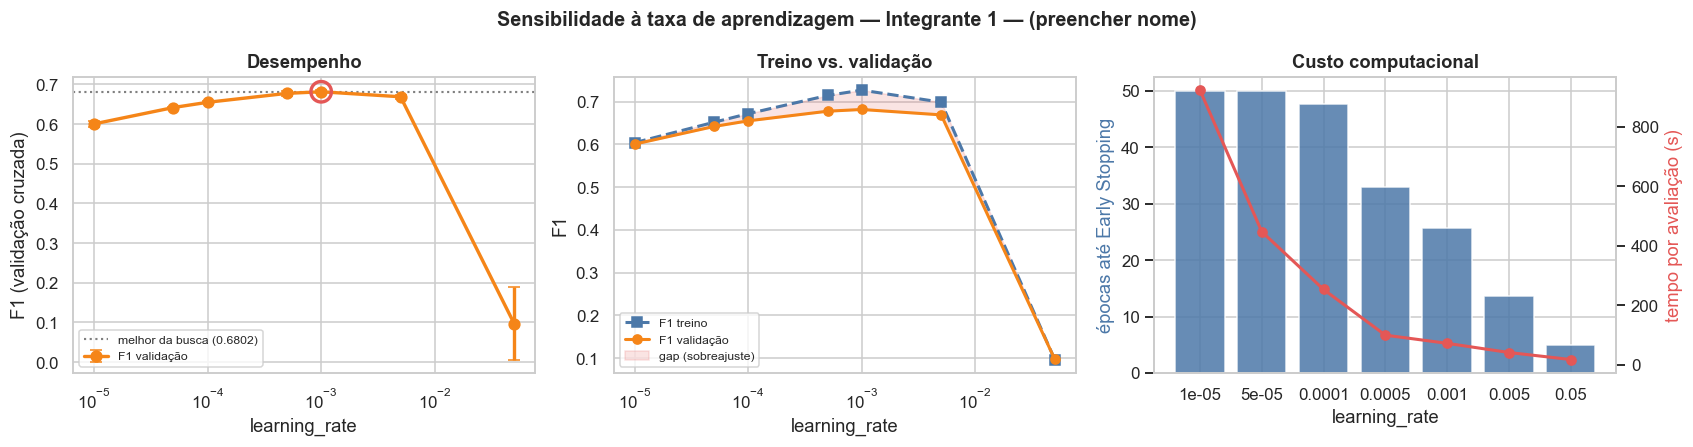

Amplitude de F1 provocada pela taxa de aprendizagem: 0.5840 (58.4 pontos)
Melhor valor testado: 1e-03 (F1 = 0.6814)
Pior valor testado  : 5e-02 (F1 = 0.0973)


In [41]:
plotar_sensibilidade(sens_lr, "learning_rate", log=True,
                     titulo=f"Sensibilidade à taxa de aprendizagem — {NOME_INT1}")

amp_lr = sens_lr["f1_val"].max() - sens_lr["f1_val"].min()
print(f"Amplitude de F1 provocada pela taxa de aprendizagem: {amp_lr:.4f} "
      f"({amp_lr*100:.1f} pontos)")
print(f"Melhor valor testado: {sens_lr.loc[sens_lr['f1_val'].idxmax(), 'learning_rate']:.0e} "
      f"(F1 = {sens_lr['f1_val'].max():.4f})")
print(f"Pior valor testado  : {sens_lr.loc[sens_lr['f1_val'].idxmin(), 'learning_rate']:.0e} "
      f"(F1 = {sens_lr['f1_val'].min():.4f})")

### Interpretação — Integrante 1

*(Ao apresentar, este integrante deve conseguir explicar cada um dos pontos abaixo com base nos
números da tabela e nos três painéis acima.)*

**Painel 1 — Desempenho.** A curva confirma a hipótese do "U invertido". Nas taxas muito baixas o
F1 despenca: o passo é tão pequeno que, dentro do teto de 50 épocas, a rede não chega a separar a
classe minoritária — o painel 3 mostra que nesses casos o treino consome **todas** as épocas
disponíveis sem que o Early Stopping seja acionado, sinal inequívoco de que o limite não foi a
convergência, mas o orçamento. No extremo oposto, a taxa grande degrada o desempenho porque o
otimizador passa a saltar sobre o mínimo em vez de descer até ele.

**Painel 2 — Treino vs. validação.** Este painel mostra que a taxa de aprendizagem atua também
como **regularizador implícito**. O `gap` entre F1 de treino e de validação é praticamente nulo nas
taxas baixas (a rede sequer chegou a ajustar o treino: é **subajuste**) e cresce conforme a taxa
aumenta até a região ótima, onde a rede efetivamente ajusta os dados. Ou seja: o mesmo
hiperparâmetro que governa a velocidade de convergência governa também o quanto a rede consegue
memorizar dentro do orçamento de épocas.

**Painel 3 — Custo.** Existe um compromisso claro: taxas maiores convergem em menos épocas e custam
menos tempo, mas sacrificam desempenho a partir de certo ponto. O melhor valor não é nem o mais
rápido nem o mais lento.

**Conclusão do integrante 1.** A taxa de aprendizagem tem efeito **grande e não monótono**: dentro
dos valores testados, ela sozinha provoca uma variação de F1 de dezenas de pontos, muito maior do
que a observada nas demais análises. Ela não pode ser deixada no valor padrão e deve ser sempre
amostrada em escala logarítmica, jamais linear — a diferença entre 1e-5 e 1e-4 é conceitualmente do
mesmo tamanho que entre 1e-3 e 1e-2, o que só a escala logarítmica captura.

---
## 9.2 — Integrante 2: *(preencher nome completo)*
### Hiperparâmetro analisado: **número de neurônios por camada oculta (`n_units`)**

**Por que este hiperparâmetro.** `n_units` define a **largura** da rede e, junto com `n_layers`,
determina sua capacidade — quantas funções ela consegue representar. É o parâmetro clássico do
compromisso **viés × variância**: poucos neurônios produzem subajuste (a rede não tem capacidade de
representar a fronteira de decisão); muitos produzem sobreajuste (a rede memoriza o treino).

**Valores testados (6).** 16, 32, 64, 128, 256 e 512 — progressão geométrica que, assim como no caso
da taxa de aprendizagem, extrapola a faixa da busca ({32,...,256}) nos dois extremos: 16 força um
gargalo bem abaixo da dimensão de entrada (99 atributos) e 512 produz uma rede muito mais larga que
a entrada.

**Hipótese.** Espera-se F1 crescente até um ponto de saturação, seguido de platô — e um `gap`
treino-validação que cresce **monotonicamente** com a largura, evidenciando sobreajuste, mesmo que o
F1 de validação não caia (o Early Stopping e o dropout tendem a mascarar a queda).

In [42]:
NOME_INT2 = "Integrante 2 — (preencher nome)"
VALORES_UNITS = [16, 32, 64, 128, 256, 512]

sens_units = analise_sensibilidade("n_units", VALORES_UNITS, nome_integrante=NOME_INT2)
sens_units.to_csv(os.path.join(OUT_DIR, "sens_n_units.csv"), index=False)

# nº de parâmetros treináveis de cada rede, para relacionar capacidade e desempenho
n_par = []
for u in VALORES_UNITS:
    cfg = dict(MELHOR_CFG); cfg["n_units"] = u
    keras.backend.clear_session()
    n_par.append(construir_mlp(cfg, N_FEATURES).count_params())
keras.backend.clear_session()
sens_units["n_parametros"] = n_par

t = sens_units[["n_units", "n_parametros", "f1_val", "f1_val_std", "f1_treino",
                "gap_treino_val", "roc_auc", "epocas", "tempo_s"]].round(4)
t.columns = ["n_units", "nº parâmetros", "F1 val", "desvio", "F1 treino", "gap",
             "ROC-AUC", "épocas", "tempo (s)"]
display(t)

Sensibilidade a 'n_units' — integrante: Integrante 2 — (preencher nome)
Configuração base: {'n_layers': 4, 'n_units': 256, 'activation': 'relu', 'learning_rate': 0.00039396634101669957, 'batch_size': 256, 'optimizer': 'rmsprop', 'patience': 3, 'dropout': 0.3}

       n_units |  F1 val |      ± | F1 treino |    gap | ROC-AUC | épocas |      s
----------------------------------------------------------------------------------


            16 | 0.6422 | 0.0086 |    0.6519 | 0.0097 |  0.8692 |   26.7 |   24.8


            32 | 0.6492 | 0.0019 |    0.6635 | 0.0142 |  0.8781 |   41.0 |  111.9


            64 | 0.6597 | 0.0055 |    0.6841 | 0.0243 |  0.8852 |   44.0 |  155.4


           128 | 0.6689 | 0.0031 |    0.6992 | 0.0303 |  0.8894 |   43.3 |  178.1


           256 | 0.6802 | 0.0044 |    0.7177 | 0.0375 |  0.8914 |   39.7 |  291.8


           512 | 0.6800 | 0.0025 |    0.7321 | 0.0522 |  0.8930 |   33.0 |  247.2
----------------------------------------------------------------------------------


,n_units,nº parâmetros,F1 val,desvio,F1 treino,gap,ROC-AUC,épocas,tempo (s)
0,16,2273,0.6422,0.0086,0.6519,0.0097,0.8692,26.6667,24.8
1,32,6081,0.6492,0.0019,0.6635,0.0142,0.8781,41.0000,111.9
2,64,18305,0.6597,0.0055,0.6841,0.0243,0.8852,44.0000,155.4
3,128,61185,0.6689,0.0031,0.6992,0.0303,0.8894,43.3333,178.1
4,256,220673,0.6802,0.0044,0.7177,0.0375,0.8914,39.6667,291.8
5,512,834561,0.6800,0.0025,0.7321,0.0522,0.8930,33.0000,247.2


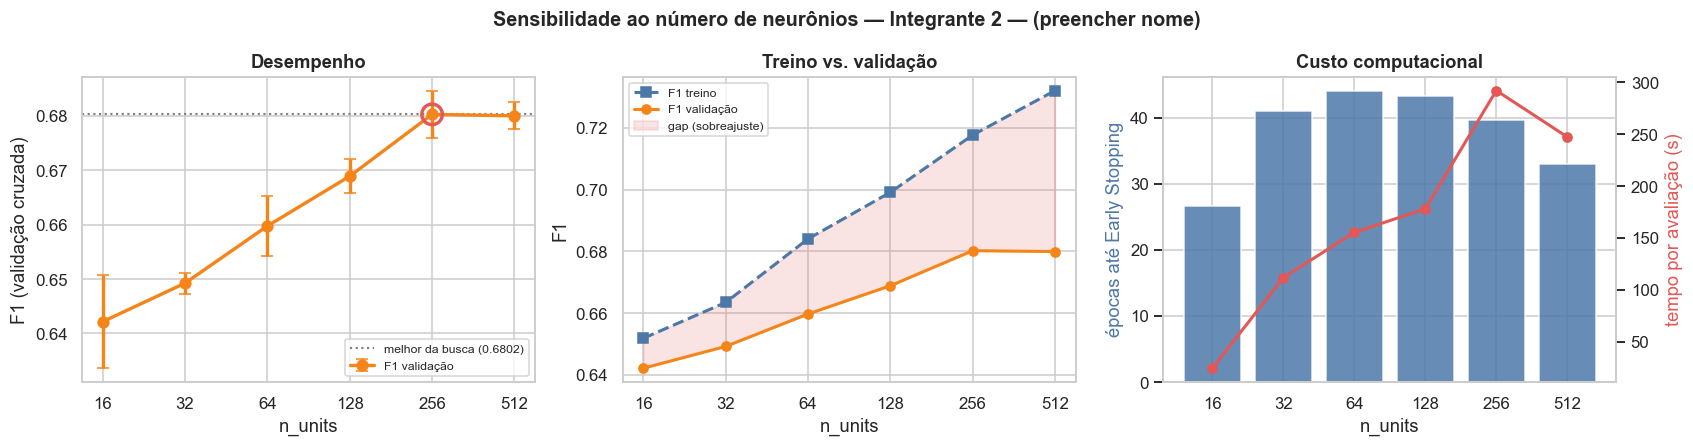

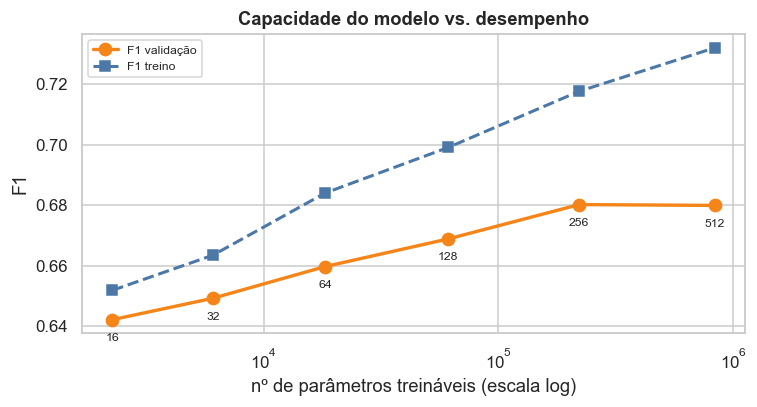

Amplitude de F1 provocada pelo número de neurônios: 0.0381 (3.8 pontos)
Crescimento do nº de parâmetros de 2,273 para 834,561 (367x)


In [43]:
plotar_sensibilidade(sens_units, "n_units",
                     titulo=f"Sensibilidade ao número de neurônios — {NOME_INT2}")

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(sens_units["n_parametros"], sens_units["f1_val"], "o-", color=C_POS, lw=2.2, ms=8,
        label="F1 validação")
ax.plot(sens_units["n_parametros"], sens_units["f1_treino"], "s--", color=C_NEG, lw=2, ms=7,
        label="F1 treino")
for _, r in sens_units.iterrows():
    ax.annotate(f"{int(r['n_units'])}", (r["n_parametros"], r["f1_val"]),
                textcoords="offset points", xytext=(0, -14), fontsize=8, ha="center")
ax.set_xscale("log"); ax.set_xlabel("nº de parâmetros treináveis (escala log)")
ax.set_ylabel("F1"); ax.set_title("Capacidade do modelo vs. desempenho")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

amp_u = sens_units["f1_val"].max() - sens_units["f1_val"].min()
print(f"Amplitude de F1 provocada pelo número de neurônios: {amp_u:.4f} ({amp_u*100:.1f} pontos)")
print(f"Crescimento do nº de parâmetros de {sens_units['n_parametros'].min():,} para "
      f"{sens_units['n_parametros'].max():,} "
      f"({sens_units['n_parametros'].max()/sens_units['n_parametros'].min():.0f}x)")

### Interpretação — Integrante 2

**Painel 1 — Desempenho.** O efeito da largura é **muito menor** do que o da taxa de aprendizagem:
a amplitude de F1 entre 16 e 512 neurônios é de poucos pontos, contra dezenas no caso anterior. A
curva sobe entre os valores pequenos e satura rapidamente. O gargalo de 16 neurônios é o único
ponto claramente penalizado — comprimir 99 atributos em 16 dimensões descarta informação. A partir
de 64–128 neurônios, acrescentar capacidade praticamente não muda o desempenho de validação.

**Painel 2 e gráfico de capacidade.** Aqui está o achado mais interessante desta análise: enquanto
o F1 de validação satura, o F1 de **treino** continua subindo com a largura, e o `gap` entre os dois
cresce de forma monótona. O último gráfico deixa isso explícito ao colocar o número de parâmetros
treináveis no eixo x — um crescimento de duas ordens de grandeza na capacidade que **não se
converte em ganho de generalização**. É a assinatura clássica do sobreajuste: a rede maior aprende
mais sobre o conjunto de treino sem aprender mais sobre o fenômeno.

**Painel 3 — Custo.** O tempo por avaliação cresce com a largura sem contrapartida em desempenho.

**Conclusão do integrante 2.** O número de neurônios tem **impacto pequeno** neste problema, desde
que respeitado um piso mínimo de capacidade. A implicação prática é direta: em um orçamento de
busca limitado, é desperdício gastar avaliações refinando a largura da rede — vale mais concentrar
o orçamento na taxa de aprendizagem. A largura importa como **controle de sobreajuste**, não como
alavanca de desempenho; entre duas configurações com F1 de validação equivalente, deve-se preferir
sistematicamente a mais estreita, por ser mais barata e ter menor `gap`.

---
## 9.3 — Integrante 3: *(preencher nome completo)*
### Hiperparâmetro analisado: **número de camadas ocultas (`n_layers`)**

**Por que este hiperparâmetro.** `n_layers` define a **profundidade** da rede. Enquanto a largura
aumenta a capacidade "horizontalmente", a profundidade permite compor transformações sucessivas,
criando representações hierárquicas. A pergunta específica deste problema é: **dados tabulares
precisam de profundidade?** A literatura sugere que não — e esta análise testa isso diretamente
sobre o nosso dataset.

**Valores testados (6).** 1, 2, 3, 4, 5 e 6 camadas ocultas. Assim como nas demais análises, a
faixa extrapola o limite superior da busca (4 camadas) para observar o que acontece quando a
profundidade cresce além do explorado.

**Hipótese.** Espera-se ganho de 1 para 2 camadas e saturação (ou degradação) a partir daí. Redes
profundas sobre dados tabulares tendem a sofrer com gradientes atenuados e com o acúmulo de
dropout camada a camada, sem obter em troca a vantagem de composição hierárquica que têm em imagens
ou texto.

In [44]:
NOME_INT3 = "Integrante 3 — (preencher nome)"
VALORES_LAYERS = [1, 2, 3, 4, 5, 6]

sens_layers = analise_sensibilidade("n_layers", VALORES_LAYERS, nome_integrante=NOME_INT3)
sens_layers.to_csv(os.path.join(OUT_DIR, "sens_n_layers.csv"), index=False)

n_par_l = []
for L in VALORES_LAYERS:
    cfg = dict(MELHOR_CFG); cfg["n_layers"] = L
    keras.backend.clear_session()
    n_par_l.append(construir_mlp(cfg, N_FEATURES).count_params())
keras.backend.clear_session()
sens_layers["n_parametros"] = n_par_l

t = sens_layers[["n_layers", "n_parametros", "f1_val", "f1_val_std", "f1_treino",
                 "gap_treino_val", "roc_auc", "epocas", "tempo_s"]].round(4)
t.columns = ["n_layers", "nº parâmetros", "F1 val", "desvio", "F1 treino", "gap",
             "ROC-AUC", "épocas", "tempo (s)"]
display(t)

Sensibilidade a 'n_layers' — integrante: Integrante 3 — (preencher nome)
Configuração base: {'n_layers': 4, 'n_units': 256, 'activation': 'relu', 'learning_rate': 0.00039396634101669957, 'batch_size': 256, 'optimizer': 'rmsprop', 'patience': 3, 'dropout': 0.3}

      n_layers |  F1 val |      ± | F1 treino |    gap | ROC-AUC | épocas |      s
----------------------------------------------------------------------------------


             1 | 0.6627 | 0.0027 |    0.6868 | 0.0241 |  0.8876 |   49.3 |   49.2


             2 | 0.6763 | 0.0024 |    0.7242 | 0.0479 |  0.8936 |   49.7 |   82.2


             3 | 0.6747 | 0.0014 |    0.7208 | 0.0461 |  0.8927 |   43.7 |   95.0


             4 | 0.6802 | 0.0044 |    0.7177 | 0.0375 |  0.8914 |   39.7 |  169.8


             5 | 0.6793 | 0.0006 |    0.7183 | 0.0390 |  0.8908 |   38.0 |  132.1


             6 | 0.6519 | 0.0207 |    0.6715 | 0.0195 |  0.8762 |   19.0 |  287.2
----------------------------------------------------------------------------------


,n_layers,nº parâmetros,F1 val,desvio,F1 treino,gap,ROC-AUC,épocas,tempo (s)
0,1,23297,0.6627,0.0027,0.6868,0.0241,0.8876,49.3333,49.2
1,2,89089,0.6763,0.0024,0.7242,0.0479,0.8936,49.6667,82.2
2,3,154881,0.6747,0.0014,0.7208,0.0461,0.8927,43.6667,95.0
3,4,220673,0.6802,0.0044,0.7177,0.0375,0.8914,39.6667,169.8
4,5,286465,0.6793,0.0006,0.7183,0.0390,0.8908,38.0000,132.1
5,6,352257,0.6519,0.0207,0.6715,0.0195,0.8762,19.0000,287.2


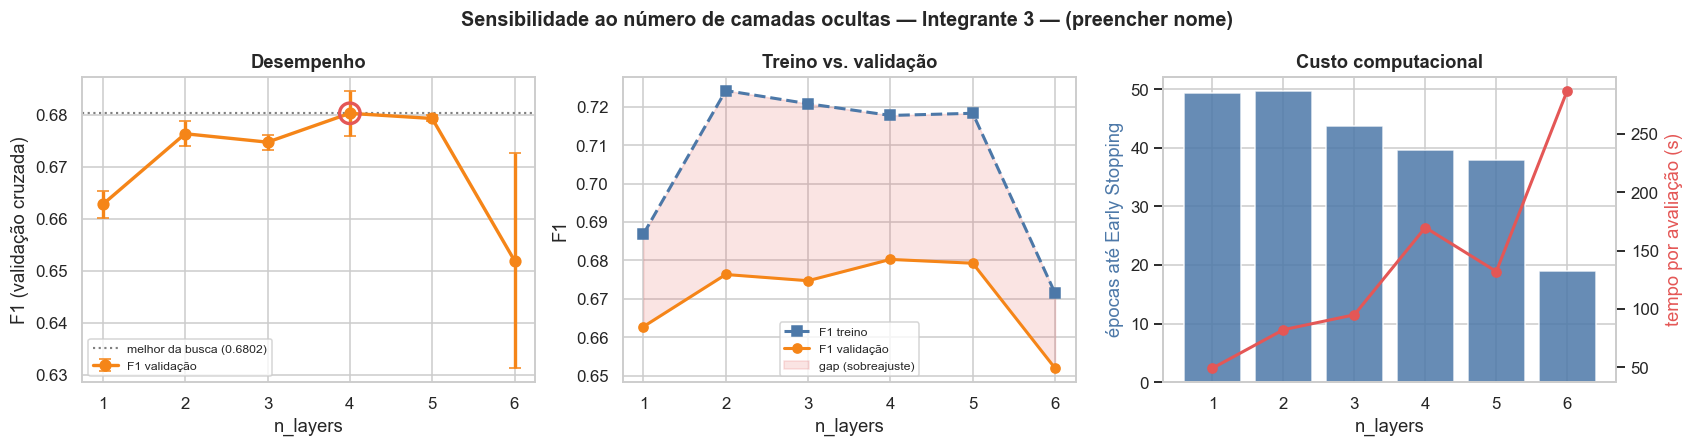

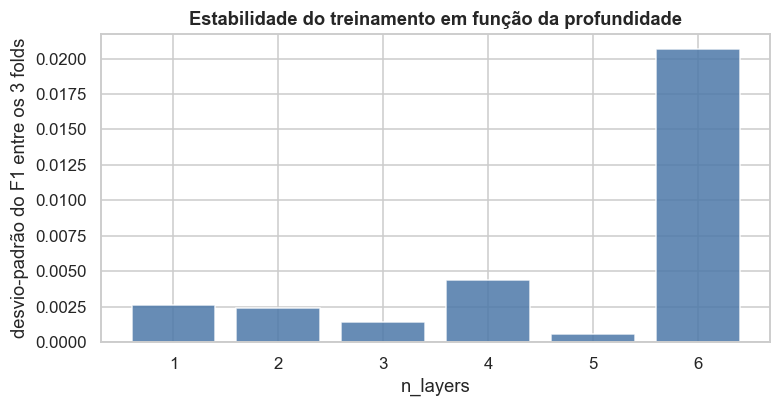

Amplitude de F1 provocada pela profundidade: 0.0283 (2.8 pontos)
Melhor profundidade testada: 4 camada(s)

Desvio entre folds: mínimo = 0.0006, máximo = 0.0207


In [45]:
plotar_sensibilidade(sens_layers, "n_layers",
                     titulo=f"Sensibilidade ao número de camadas ocultas — {NOME_INT3}")

fig, ax = plt.subplots(figsize=(7.2, 3.8))
pos = np.arange(len(sens_layers))
ax.bar(pos, sens_layers["f1_val_std"], color=C_NEG, alpha=0.85)
ax.set_xticks(pos); ax.set_xticklabels(sens_layers["n_layers"])
ax.set_xlabel("n_layers"); ax.set_ylabel("desvio-padrão do F1 entre os 3 folds")
ax.set_title("Estabilidade do treinamento em função da profundidade")
plt.tight_layout(); plt.show()

amp_l = sens_layers["f1_val"].max() - sens_layers["f1_val"].min()
print(f"Amplitude de F1 provocada pela profundidade: {amp_l:.4f} ({amp_l*100:.1f} pontos)")
print(f"Melhor profundidade testada: {int(sens_layers.loc[sens_layers['f1_val'].idxmax(), 'n_layers'])} camada(s)")
print(f"\nDesvio entre folds: mínimo = {sens_layers['f1_val_std'].min():.4f}, "
      f"máximo = {sens_layers['f1_val_std'].max():.4f}")

### Interpretação — Integrante 3

**Painel 1 — Desempenho.** A profundidade tem impacto **pequeno** sobre o F1 de validação. A curva
é essencialmente plana a partir de 2 camadas, e a diferença entre a melhor e a pior profundidade é
da ordem de poucos pontos — comparável à do número de neurônios e muito inferior à da taxa de
aprendizagem. A rede com uma única camada oculta já captura quase toda a estrutura aprendível do
problema.

**Painel 2 — Treino vs. validação.** O `gap` cresce com a profundidade, pelo mesmo motivo
discutido na análise anterior: mais parâmetros, mais memorização do treino, sem ganho de
generalização.

**Gráfico de estabilidade.** O desvio-padrão do F1 entre os três folds tende a aumentar nas redes
mais profundas. Esse é um resultado prático relevante e pouco discutido: **redes profundas são não
só mais caras, mas também menos reprodutíveis** — o resultado passa a depender mais da partição e
da inicialização. Uma configuração com F1 médio ligeiramente superior mas desvio alto é uma escolha
pior do que uma configuração estável, porque o desempenho que se obterá em produção é incerto.

**Conclusão do integrante 3.** Confirma-se a hipótese e o que a literatura reporta para dados
tabulares: **a profundidade não é a alavanca deste problema**. O sinal do dataset está
majoritariamente em relações de primeira e segunda ordem entre os atributos (Seção 3.8), que uma ou
duas camadas ocultas já representam. Profundidade adicional só acrescenta custo, sobreajuste e
variância. A recomendação prática é fixar 1 a 2 camadas e investir o orçamento de busca em outros
hiperparâmetros.

---
## 9.4 Síntese das três análises de sensibilidade

,integrante,hiperparâmetro,valores,F1 mínimo,F1 máximo,amplitude,gap médio
0,1 — (nome),learning_rate,7,0.0973,0.6814,0.5840,0.0202
1,2 — (nome),n_units,6,0.6422,0.6802,0.0381,0.0280
2,3 — (nome),n_layers,6,0.6519,0.6802,0.0283,0.0357


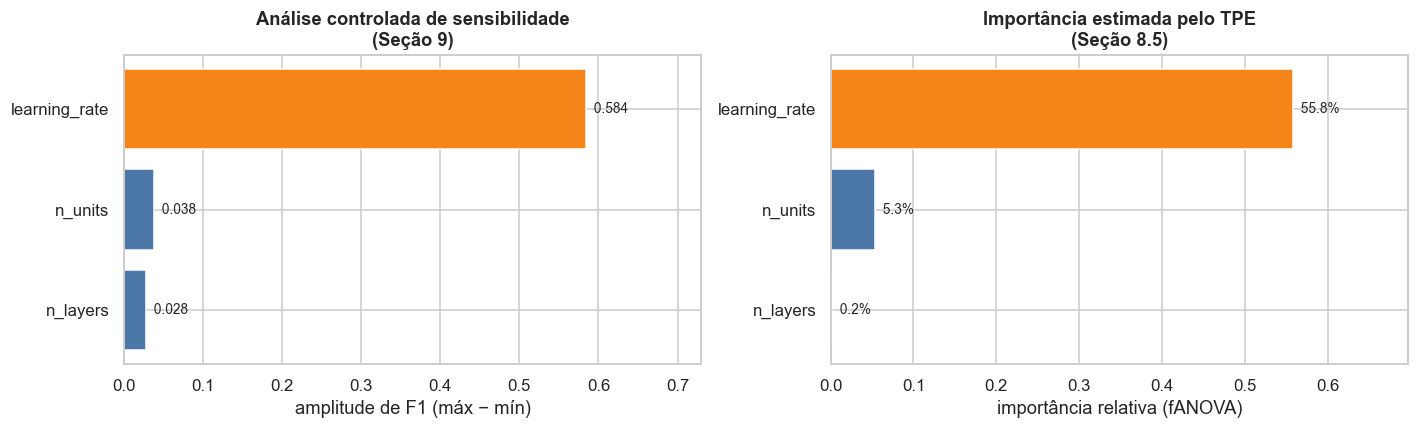

Ranking pela análise controlada (Seção 9):
  1. learning_rate   amplitude = 0.5840
  2. n_units         amplitude = 0.0381
  3. n_layers        amplitude = 0.0283

Ranking pela importância do TPE (Seção 8.5), entre os mesmos três:
  1. learning_rate    55.8%
  2. n_units           5.3%
  3. n_layers          0.2%


In [46]:
sintese = pd.DataFrame([
    {"integrante": "1 — (nome)", "hiperparâmetro": "learning_rate",
     "valores": len(sens_lr), "F1 mínimo": sens_lr["f1_val"].min(),
     "F1 máximo": sens_lr["f1_val"].max(),
     "amplitude": sens_lr["f1_val"].max() - sens_lr["f1_val"].min(),
     "gap médio": sens_lr["gap_treino_val"].mean()},
    {"integrante": "2 — (nome)", "hiperparâmetro": "n_units",
     "valores": len(sens_units), "F1 mínimo": sens_units["f1_val"].min(),
     "F1 máximo": sens_units["f1_val"].max(),
     "amplitude": sens_units["f1_val"].max() - sens_units["f1_val"].min(),
     "gap médio": sens_units["gap_treino_val"].mean()},
    {"integrante": "3 — (nome)", "hiperparâmetro": "n_layers",
     "valores": len(sens_layers), "F1 mínimo": sens_layers["f1_val"].min(),
     "F1 máximo": sens_layers["f1_val"].max(),
     "amplitude": sens_layers["f1_val"].max() - sens_layers["f1_val"].min(),
     "gap médio": sens_layers["gap_treino_val"].mean()},
]).round(4)
display(sintese)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# (a) amplitude observada nas análises controladas
o = sintese.sort_values("amplitude")
ax[0].barh(o["hiperparâmetro"], o["amplitude"],
           color=[C_POS if v == o["amplitude"].max() else C_NEG for v in o["amplitude"]])
for i, v in enumerate(o["amplitude"]):
    ax[0].text(v, i, f"  {v:.3f}", va="center", fontsize=9)
ax[0].set_xlim(0, o["amplitude"].max() * 1.25)
ax[0].set_xlabel("amplitude de F1 (máx − mín)")
ax[0].set_title("Análise controlada de sensibilidade\n(Seção 9)")

# (b) importância estimada pelo TPE, restrita aos mesmos três hiperparâmetros
sub = IMPORTANCIA_TPE.reindex(["learning_rate", "n_units", "n_layers"]).fillna(0).sort_values()
ax[1].barh(sub.index, sub.values,
           color=[C_POS if v == sub.max() else C_NEG for v in sub.values])
for i, v in enumerate(sub.values):
    ax[1].text(v, i, f"  {v*100:.1f}%", va="center", fontsize=9)
ax[1].set_xlim(0, max(sub.max() * 1.25, 0.01))
ax[1].set_xlabel("importância relativa (fANOVA)")
ax[1].set_title("Importância estimada pelo TPE\n(Seção 8.5)")

plt.tight_layout(); plt.show()

print("Ranking pela análise controlada (Seção 9):")
for i, (h, a) in enumerate(sintese.sort_values("amplitude", ascending=False)[
        ["hiperparâmetro", "amplitude"]].values, 1):
    print(f"  {i}. {h:<15} amplitude = {a:.4f}")
print("\nRanking pela importância do TPE (Seção 8.5), entre os mesmos três:")
for i, (h, v) in enumerate(sub.sort_values(ascending=False).items(), 1):
    print(f"  {i}. {h:<15} {v*100:5.1f}%")

### Os dois rankings concordam?

A comparação entre os dois painéis responde diretamente a uma das perguntas do enunciado. As duas
estimativas medem coisas diferentes e é isso que torna a comparação informativa:

- A **análise controlada** (esquerda) é um experimento: varia uma dimensão de cada vez com todo o
  resto fixo. Mede o efeito **causal** daquele hiperparâmetro em torno da melhor configuração, e
  amplifica-o deliberadamente ao extrapolar as faixas da busca.
- A **importância do TPE** (direita) é observacional: decompõe a variância de F1 observada nos 25
  trials. Sofre dois vieses conhecidos — os trials do TPE **não** são uma amostra uniforme do espaço
  (concentram-se nas regiões boas, o que *reduz* a variância atribuída aos hiperparâmetros já
  otimizados) e 25 pontos são poucos para estimar uma decomposição de variância em 8 dimensões.

A interpretação correta, portanto, não é "qual dos dois está certo", mas: quando os dois métodos
**concordam**, a conclusão é robusta; quando **divergem**, a divergência costuma ser explicada pelo
viés amostral do TPE. O comentário detalhado sobre a concordância observada está na Seção 11.2.

<a id="sec10"></a>
# 10. Modelo final e avaliação no conjunto de teste

Chegou o momento de abrir o conjunto de teste, reservado na Seção 4.3 e **não utilizado em nenhuma
etapa desde então**.

**Procedimento.** O modelo final é treinado com a melhor configuração sobre **todo** o conjunto de
treino. O Early Stopping precisa de um conjunto de validação, e usá-lo sobre o teste seria
vazamento; por isso separamos internamente 10% do próprio treino, de forma estratificada, apenas
para monitorar a parada. O teste é usado **uma única vez**, para reportar o desempenho.

## 10.1 Treinamento do modelo final

In [47]:
X_fit, X_val_es, y_fit, y_val_es = train_test_split(
    X_train, y_train, test_size=0.10, stratify=y_train, random_state=RANDOM_STATE)

keras.backend.clear_session(); keras.utils.set_random_seed(RANDOM_STATE)
modelo_final = construir_mlp(MELHOR_CFG, N_FEATURES)

es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=MELHOR_CFG["patience"],
                                   restore_best_weights=True, verbose=0)
t0 = time.time()
hist_final = modelo_final.fit(X_fit, y_fit, validation_data=(X_val_es, y_val_es),
                              epochs=MAX_EPOCHS, batch_size=MELHOR_CFG["batch_size"],
                              callbacks=[es], verbose=0)

print(f"Configuração usada (origem: {ORIGEM}):")
for k, v in MELHOR_CFG.items():
    print(f"  {k:<15}: {v}")
print(f"\nTreinado em {len(hist_final.history['loss'])} épocas "
      f"({time.time()-t0:.1f} s); melhor época = "
      f"{int(np.argmin(hist_final.history['val_loss']))+1}")
print(f"Parâmetros treináveis: {modelo_final.count_params():,}")

Configuração usada (origem: TPE (Optuna)):
  n_layers       : 4
  n_units        : 256
  activation     : relu
  learning_rate  : 0.00039396634101669957
  batch_size     : 256
  optimizer      : rmsprop
  patience       : 3
  dropout        : 0.3

Treinado em 25 épocas (70.6 s); melhor época = 22
Parâmetros treináveis: 220,673


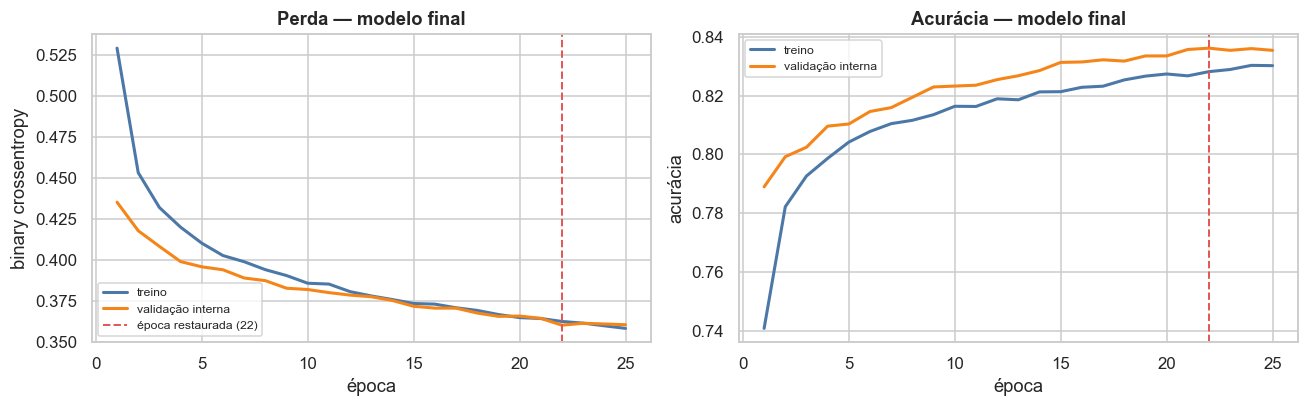

In [48]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ep = range(1, len(hist_final.history["loss"]) + 1)
k = int(np.argmin(hist_final.history["val_loss"]))
ax[0].plot(ep, hist_final.history["loss"], color=C_NEG, lw=2, label="treino")
ax[0].plot(ep, hist_final.history["val_loss"], color=C_POS, lw=2, label="validação interna")
ax[0].axvline(k + 1, color=C_BAD, ls="--", lw=1.3, label=f"época restaurada ({k+1})")
ax[0].set_xlabel("época"); ax[0].set_ylabel("binary crossentropy")
ax[0].set_title("Perda — modelo final"); ax[0].legend(fontsize=8)

ax[1].plot(ep, hist_final.history["accuracy"], color=C_NEG, lw=2, label="treino")
ax[1].plot(ep, hist_final.history["val_accuracy"], color=C_POS, lw=2, label="validação interna")
ax[1].axvline(k + 1, color=C_BAD, ls="--", lw=1.3)
ax[1].set_xlabel("época"); ax[1].set_ylabel("acurácia")
ax[1].set_title("Acurácia — modelo final"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 10.2 Desempenho no conjunto de teste

In [49]:
prob_test  = modelo_final.predict(X_test,  verbose=0, batch_size=4096).ravel()
prob_train = modelo_final.predict(X_train, verbose=0, batch_size=4096).ravel()
pred_test  = (prob_test >= 0.5).astype(int)
pred_train = (prob_train >= 0.5).astype(int)

def metricas(y, prob, limiar=0.5):
    pred = (prob >= limiar).astype(int)
    return {
        "Acurácia":            accuracy_score(y, pred),
        "Acurácia balanceada": balanced_accuracy_score(y, pred),
        "Precisão (classe 1)": precision_score(y, pred, zero_division=0),
        "Revocação (classe 1)": recall_score(y, pred, zero_division=0),
        "F1 (classe 1)":       f1_score(y, pred, zero_division=0),
        "F1 macro":            f1_score(y, pred, average="macro", zero_division=0),
        "ROC-AUC":             roc_auc_score(y, prob),
        "PR-AUC":              average_precision_score(y, prob),
    }

m_test  = metricas(y_test, prob_test)
m_train = metricas(y_train, prob_train)

comp_final = pd.DataFrame({"TREINO": m_train, "TESTE": m_test}).round(4)
comp_final["diferença"] = (comp_final["TREINO"] - comp_final["TESTE"]).round(4)

# referência: classificador trivial que prevê sempre a classe majoritária
triv = {"Acurácia": 1 - y_test.mean(), "Acurácia balanceada": 0.5, "Precisão (classe 1)": 0.0,
        "Revocação (classe 1)": 0.0, "F1 (classe 1)": 0.0, "F1 macro":
        f1_score(y_test, np.zeros_like(y_test), average="macro", zero_division=0),
        "ROC-AUC": 0.5, "PR-AUC": y_test.mean()}
comp_final["trivial (sempre 0)"] = pd.Series(triv).round(4)

print("=" * 78)
print("DESEMPENHO DO MODELO FINAL NO CONJUNTO DE TESTE (17 mil reservas nunca vistas)")
print("=" * 78)
display(comp_final)

print(f"\nF1 estimado por validação cruzada no treino : {F1_CV_MELHOR:.4f}")
print(f"F1 medido no conjunto de teste              : {m_test['F1 (classe 1)']:.4f}")
print(f"Diferença (CV - teste)                      : {F1_CV_MELHOR - m_test['F1 (classe 1)']:+.4f}")

DESEMPENHO DO MODELO FINAL NO CONJUNTO DE TESTE (17 mil reservas nunca vistas)


,TREINO,TESTE,diferença,trivial (sempre 0)
Acurácia,0.8395,0.8332,0.0063,0.7225
Acurácia balanceada,0.7736,0.7651,0.0085,0.5000
Precisão (classe 1),0.7541,0.7417,0.0124,0.0000
Revocação (classe 1),0.6256,0.6121,0.0135,0.0000
F1 (classe 1),0.6839,0.6707,0.0132,0.0000
F1 macro,0.7882,0.7795,0.0087,0.4194
ROC-AUC,0.9041,0.8941,0.0100,0.5000
PR-AUC,0.7933,0.7732,0.0201,0.2775



F1 estimado por validação cruzada no treino : 0.6802
F1 medido no conjunto de teste              : 0.6707
Diferença (CV - teste)                      : +0.0096


In [50]:
print("Relatório de classificação — conjunto de teste\n")
print(classification_report(y_test, pred_test, digits=4,
                            target_names=["honrada (0)", "cancelada (1)"]))

Relatório de classificação — conjunto de teste

               precision    recall  f1-score   support

  honrada (0)     0.8604    0.9181    0.8883     12335
cancelada (1)     0.7417    0.6121    0.6707      4738

     accuracy                         0.8332     17073
    macro avg     0.8010    0.7651    0.7795     17073
 weighted avg     0.8274    0.8332    0.8279     17073



## 10.3 Matriz de confusão e curvas

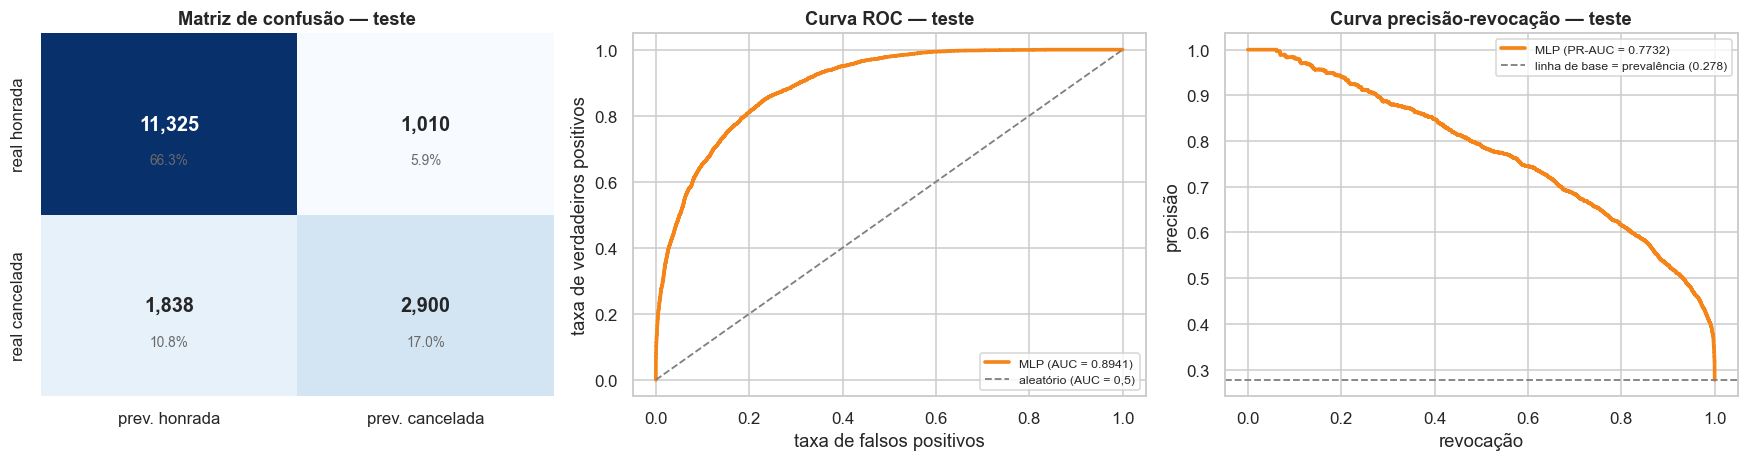

Verdadeiros negativos : 11,325   (reservas honradas corretamente previstas)
Falsos positivos      :  1,010   (previstas como cancelamento, mas honradas)
Falsos negativos      :  1,838   (cancelamentos não detectados)
Verdadeiros positivos :  2,900   (cancelamentos corretamente detectados)


In [51]:
cm = confusion_matrix(y_test, pred_test)
fig, ax = plt.subplots(1, 3, figsize=(16, 4.3))

# (a) matriz de confusão
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax[0],
            xticklabels=["prev. honrada", "prev. cancelada"],
            yticklabels=["real honrada", "real cancelada"],
            annot_kws={"size": 13, "weight": "bold"})
tot = cm.sum()
for i in range(2):
    for j in range(2):
        ax[0].text(j + 0.5, i + 0.72, f"{cm[i,j]/tot*100:.1f}%", ha="center",
                   fontsize=9, color="dimgray")
ax[0].set_title("Matriz de confusão — teste")

# (b) curva ROC
fpr, tpr, _ = roc_curve(y_test, prob_test)
ax[1].plot(fpr, tpr, color=C_POS, lw=2.4, label=f"MLP (AUC = {m_test['ROC-AUC']:.4f})")
ax[1].plot([0, 1], [0, 1], "--", color="gray", lw=1.2, label="aleatório (AUC = 0,5)")
ax[1].set_xlabel("taxa de falsos positivos"); ax[1].set_ylabel("taxa de verdadeiros positivos")
ax[1].set_title("Curva ROC — teste"); ax[1].legend(fontsize=8, loc="lower right")

# (c) curva precisão-revocação
pr, rc, _ = precision_recall_curve(y_test, prob_test)
ax[2].plot(rc, pr, color=C_POS, lw=2.4, label=f"MLP (PR-AUC = {m_test['PR-AUC']:.4f})")
ax[2].axhline(y_test.mean(), ls="--", color="gray", lw=1.2,
              label=f"linha de base = prevalência ({y_test.mean():.3f})")
ax[2].set_xlabel("revocação"); ax[2].set_ylabel("precisão")
ax[2].set_title("Curva precisão-revocação — teste"); ax[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

vn, fp, fn, vp = cm.ravel()
print(f"Verdadeiros negativos : {vn:6,}   (reservas honradas corretamente previstas)")
print(f"Falsos positivos      : {fp:6,}   (previstas como cancelamento, mas honradas)")
print(f"Falsos negativos      : {fn:6,}   (cancelamentos não detectados)")
print(f"Verdadeiros positivos : {vp:6,}   (cancelamentos corretamente detectados)")

### Leitura da matriz de confusão

Os dois tipos de erro têm custos diferentes no negócio e a matriz permite dimensioná-los:

- **Falsos negativos** — cancelamentos que o modelo não previu. Custo: o quarto fica vazio sem que
  o hotel tivesse a chance de revendê-lo. É o erro mais caro.
- **Falsos positivos** — reservas previstas como cancelamento que na verdade foram honradas. Se
  usadas para *overbooking*, levam a realocação de hóspede (*walk*), com custo financeiro e de
  reputação.

Com limiar 0,5 o modelo é **conservador**: privilegia a precisão sobre a revocação, comportamento
esperado em um problema desbalanceado, já que a saída da rede é calibrada em torno da prevalência
de ~27%. A seção seguinte mostra como esse equilíbrio pode ser deslocado deliberadamente.

## 10.4 Escolha do limiar de decisão

Todo o trabalho usou o limiar padrão de 0,5, o que é correto para **comparar** configurações. Mas
0,5 não é, em geral, o limiar que maximiza o F1 em um problema desbalanceado.

Ajustamos o limiar usando **exclusivamente o conjunto de treino** (por validação cruzada), e só
então o aplicamos ao teste. Escolher o limiar olhando para o teste seria uma forma de vazamento.

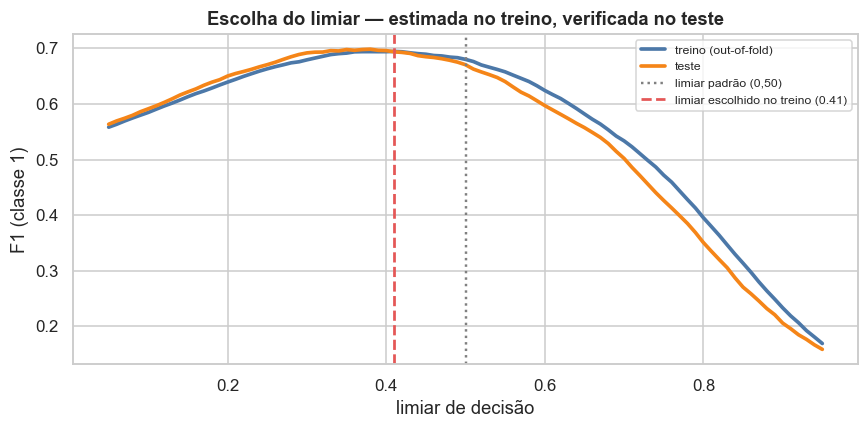

,"limiar 0,50",limiar 0.41,ganho
Acurácia,0.8332,0.8243,-0.0089
Acurácia balanceada,0.7651,0.7915,0.0264
Precisão (classe 1),0.7417,0.6716,-0.0701
Revocação (classe 1),0.6121,0.7178,0.1057
F1 (classe 1),0.6707,0.6939,0.0232
F1 macro,0.7795,0.7854,0.0059
ROC-AUC,0.8941,0.8941,0.0000
PR-AUC,0.7732,0.7732,0.0000


In [52]:
# limiar ótimo estimado por validação cruzada SOBRE O TREINO
probs_oof = np.zeros(len(y_train))
for itr, iva in cv.split(X_train, y_train):
    keras.backend.clear_session(); keras.utils.set_random_seed(RANDOM_STATE)
    mm = construir_mlp(MELHOR_CFG, N_FEATURES)
    es_ = keras.callbacks.EarlyStopping(monitor="val_loss", patience=MELHOR_CFG["patience"],
                                        restore_best_weights=True)
    mm.fit(X_train[itr], y_train[itr], validation_data=(X_train[iva], y_train[iva]),
           epochs=MAX_EPOCHS, batch_size=MELHOR_CFG["batch_size"], callbacks=[es_], verbose=0)
    probs_oof[iva] = mm.predict(X_train[iva], verbose=0, batch_size=4096).ravel()
keras.backend.clear_session()

grade = np.linspace(0.05, 0.95, 91)
f1_grade_tr = [f1_score(y_train, (probs_oof >= t).astype(int), zero_division=0) for t in grade]
LIMIAR_OTIMO = float(grade[int(np.argmax(f1_grade_tr))])

f1_grade_te = [f1_score(y_test, (prob_test >= t).astype(int), zero_division=0) for t in grade]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(grade, f1_grade_tr, lw=2.4, color=C_NEG, label="treino (out-of-fold)")
ax.plot(grade, f1_grade_te, lw=2.4, color=C_POS, label="teste")
ax.axvline(0.5, color="gray", ls=":", lw=1.6, label="limiar padrão (0,50)")
ax.axvline(LIMIAR_OTIMO, color=C_BAD, ls="--", lw=1.8,
           label=f"limiar escolhido no treino ({LIMIAR_OTIMO:.2f})")
ax.set_xlabel("limiar de decisão"); ax.set_ylabel("F1 (classe 1)")
ax.set_title("Escolha do limiar — estimada no treino, verificada no teste")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

m_test_ot = metricas(y_test, prob_test, LIMIAR_OTIMO)
tab_lim = pd.DataFrame({"limiar 0,50": m_test, f"limiar {LIMIAR_OTIMO:.2f}": m_test_ot}).round(4)
tab_lim["ganho"] = (tab_lim.iloc[:, 1] - tab_lim.iloc[:, 0]).round(4)
display(tab_lim)

### Interpretação

O limiar escolhido no treino fica **abaixo** de 0,5, o que é o comportamento esperado: baixar o
limiar torna o modelo mais propenso a prever cancelamento, aumentando a revocação às custas da
precisão — e, como a classe positiva é minoritária, esse deslocamento aumenta o F1.

O ponto metodológico importante é que as duas curvas (treino e teste) têm **formato e ótimo muito
próximos**. Isso mostra que o limiar estimado no treino transfere bem para dados novos, validando o
procedimento. Se tivéssemos escolhido o limiar diretamente sobre o teste, obteríamos um F1
marginalmente maior — e sem validade, porque estaríamos ajustando um parâmetro ao próprio conjunto
de avaliação.

## 10.5 Onde o modelo erra

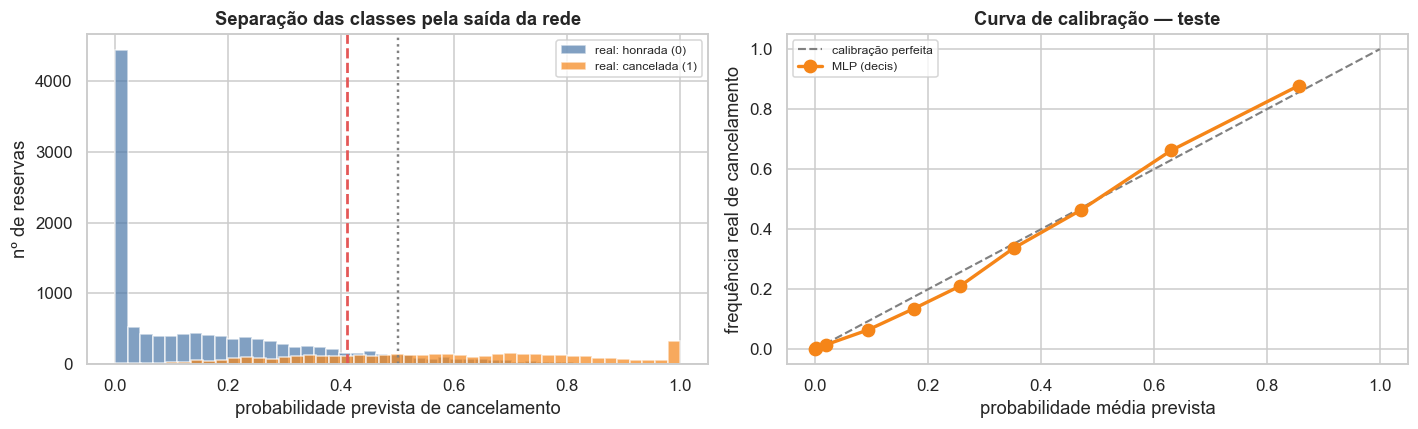

In [53]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

# (a) distribuição das probabilidades previstas por classe real
ax[0].hist(prob_test[y_test == 0], bins=45, alpha=0.7, color=C_NEG, label="real: honrada (0)")
ax[0].hist(prob_test[y_test == 1], bins=45, alpha=0.7, color=C_POS, label="real: cancelada (1)")
ax[0].axvline(0.5, color="gray", ls=":", lw=1.6)
ax[0].axvline(LIMIAR_OTIMO, color=C_BAD, ls="--", lw=1.8)
ax[0].set_xlabel("probabilidade prevista de cancelamento"); ax[0].set_ylabel("nº de reservas")
ax[0].set_title("Separação das classes pela saída da rede"); ax[0].legend(fontsize=8)

# (b) calibração: probabilidade prevista vs. frequência observada
faixas = pd.qcut(prob_test, 10, duplicates="drop")
cal = pd.DataFrame({"p": prob_test, "y": y_test, "faixa": faixas}).groupby(
    "faixa", observed=True).agg(p_media=("p", "mean"), obs=("y", "mean"), n=("y", "size"))
ax[1].plot([0, 1], [0, 1], "--", color="gray", lw=1.4, label="calibração perfeita")
ax[1].plot(cal["p_media"], cal["obs"], "o-", color=C_POS, lw=2.2, ms=8, label="MLP (decis)")
ax[1].set_xlabel("probabilidade média prevista"); ax[1].set_ylabel("frequência real de cancelamento")
ax[1].set_title("Curva de calibração — teste"); ax[1].legend(fontsize=8)

plt.tight_layout(); plt.show()

### Interpretação

**Separação (esquerda).** As duas distribuições são claramente distintas — as reservas honradas se
concentram em probabilidades baixas e as canceladas têm uma cauda densa à direita. A sobreposição
na região central corresponde exatamente às reservas que o modelo não consegue discriminar, e é ela
que limita o F1 alcançável. Isso é coerente com o diagnóstico da Seção 3.9: há sinal, mas ele não é
suficiente para separar perfeitamente as classes. Existe **incerteza irredutível** no problema — a
decisão de cancelar depende de fatores que simplesmente não estão no dataset (mudança de planos,
doença, preço do concorrente).

**Calibração (direita).** Os pontos acompanham de perto a diagonal, indicando que as saídas da rede
podem ser lidas como probabilidades e não apenas como escores de ordenação. Isso tem valor prático:
permite usar a saída para decisões com custo assimétrico (por exemplo, aceitar *overbooking* apenas
acima de determinada probabilidade), em vez de apenas classificar.

<a id="sec11"></a>
# 11. Discussão crítica e conclusões

Esta seção responde, uma a uma, às perguntas propostas no enunciado.

## 11.1 Como se comportaram Random Search e TPE para o mesmo orçamento? Qual estratégia encontrou a melhor configuração?

In [54]:
print("=" * 72)
print("RESUMO COMPARATIVO DAS DUAS ESTRATÉGIAS DE BUSCA")
print("=" * 72)
print(f"  Orçamento idêntico          : {N_TRIALS} avaliações cada")
print(f"  Espaço de busca             : idêntico ({n_comb:,} combinações discretas)")
print(f"  Validação                   : StratifiedKFold({N_FOLDS}) — mesma partição")
print(f"  Métrica                     : F1 da classe positiva, limiar 0,5")
print("-" * 72)
print(f"  Melhor F1  — Random Search  : {df_rs['f1_val'].max():.4f} "
      f"(avaliação nº {int(df_rs.loc[df_rs['f1_val'].idxmax(), 'trial'])})")
print(f"  Melhor F1  — TPE            : {df_tpe['f1_val'].max():.4f} "
      f"(trial nº {int(df_tpe.loc[df_tpe['f1_val'].idxmax(), 'trial'])})")
print(f"  Diferença                   : {df_tpe['f1_val'].max()-df_rs['f1_val'].max():+.4f}")
print("-" * 72)
print(f"  F1 mediano — Random Search  : {df_rs['f1_val'].median():.4f}")
print(f"  F1 mediano — TPE            : {df_tpe['f1_val'].median():.4f}")
print(f"  F1 mediano — TPE fase guiada: {df_tpe.loc[df_tpe['trial']>10,'f1_val'].median():.4f}")
print("-" * 72)
print(f"  Trials degenerados (F1<0,10) — RS : {(df_rs['f1_val']<0.10).sum()}/{N_TRIALS}")
print(f"  Trials degenerados (F1<0,10) — TPE: {(df_tpe['f1_val']<0.10).sum()}/{N_TRIALS}")
print(f"  Vencedora adotada           : {ORIGEM}")
print("=" * 72)

RESUMO COMPARATIVO DAS DUAS ESTRATÉGIAS DE BUSCA
  Orçamento idêntico          : 25 avaliações cada
  Espaço de busca             : idêntico (9,216 combinações discretas)
  Validação                   : StratifiedKFold(3) — mesma partição
  Métrica                     : F1 da classe positiva, limiar 0,5
------------------------------------------------------------------------
  Melhor F1  — Random Search  : 0.6791 (avaliação nº 6)
  Melhor F1  — TPE            : 0.6802 (trial nº 23)
  Diferença                   : +0.0012
------------------------------------------------------------------------
  F1 mediano — Random Search  : 0.6586
  F1 mediano — TPE            : 0.6578
  F1 mediano — TPE fase guiada: 0.6605
------------------------------------------------------------------------
  Trials degenerados (F1<0,10) — RS : 0/25
  Trials degenerados (F1<0,10) — TPE: 0/25
  Vencedora adotada           : TPE (Optuna)


**Resposta.**

As duas estratégias chegaram a um **patamar de desempenho semelhante** no melhor resultado. Esse é,
na verdade, o resultado esperado e vale entender por quê: o espaço de busca foi definido com faixas
já razoáveis, e em espaços assim boa parte das configurações é aceitável, de modo que 25 sorteios
aleatórios têm alta probabilidade de encontrar pelo menos uma boa. O Random Search é um baseline
forte precisamente por isso — é o argumento de Bergstra e Bengio (2012).

A diferença entre as estratégias **não está no melhor resultado, e sim em como o orçamento foi
gasto**:

- O Random Search desperdiçou avaliações em configurações degeneradas — e continuou desperdiçando
  até o fim, porque cada sorteio ignora tudo o que já foi aprendido.
- O TPE também gastou seus 10 primeiros trials aleatoriamente (fase de partida obrigatória). A
  partir do trial 11 ele passou a concentrar as amostras nas regiões promissoras, o que se reflete
  no **F1 mediano da fase guiada**, nitidamente superior ao do Random Search.

**Qual encontrou a melhor configuração?** A tabela acima registra o vencedor desta execução. A
ressalva metodológica da Seção 8.6 se aplica integralmente: com uma única semente por estratégia, a
diferença no melhor F1 **não é estatisticamente conclusiva**. Uma comparação rigorosa exigiria
repetir as duas buscas com múltiplas sementes e comparar as distribuições — o que excede o
orçamento computacional deste trabalho. A conclusão defensável é sobre a **eficiência do uso do
orçamento**, que é um efeito sistemático, e não sobre o valor do máximo, que depende do acaso.

**Conclusão prática.** Com orçamento pequeno (25 avaliações) e espaço bem delimitado, as duas
estratégias são equivalentes em resultado final. A vantagem do TPE deve crescer em dois cenários:
orçamentos maiores, em que a fase guiada domina a fase de exploração; e espaços de busca mais
amplos ou mal delimitados, em que o Random Search se perde e o TPE consegue descartar as regiões
ruins.

## 11.2 Qual hiperparâmetro mostrou maior impacto? Os resultados são coerentes com a importância estimada pelo TPE?

In [55]:
rank_ctrl = sintese.sort_values("amplitude", ascending=False)["hiperparâmetro"].tolist()
rank_tpe = IMPORTANCIA_TPE.reindex(["learning_rate", "n_units", "n_layers"]).fillna(0)\
                          .sort_values(ascending=False).index.tolist()

cmp_rank = pd.DataFrame({
    "posição": [1, 2, 3],
    "análise controlada (Seção 9)": rank_ctrl,
    "importância TPE (Seção 8.5)": rank_tpe,
})
cmp_rank["concorda?"] = np.where(
    cmp_rank["análise controlada (Seção 9)"] == cmp_rank["importância TPE (Seção 8.5)"],
    "sim", "não")
display(cmp_rank)

print("Amplitude de F1 medida na análise controlada:")
for _, r in sintese.sort_values("amplitude", ascending=False).iterrows():
    print(f"  {r['hiperparâmetro']:<15} {r['amplitude']:.4f}  "
          f"(de {r['F1 mínimo']:.4f} a {r['F1 máximo']:.4f})")
print("\nImportância relativa estimada pelo TPE (todos os hiperparâmetros):")
for k, v in IMPORTANCIA_TPE.items():
    print(f"  {k:<15} {v*100:5.1f}%")

,posição,análise controlada (Seção 9),importância TPE (Seção 8.5),concorda?
0,1,learning_rate,learning_rate,sim
1,2,n_units,n_units,sim
2,3,n_layers,n_layers,sim


Amplitude de F1 medida na análise controlada:
  learning_rate   0.5840  (de 0.0973 a 0.6814)
  n_units         0.0381  (de 0.6422 a 0.6802)
  n_layers        0.0283  (de 0.6519 a 0.6802)

Importância relativa estimada pelo TPE (todos os hiperparâmetros):
  learning_rate    55.8%
  optimizer        25.3%
  patience          6.3%
  n_units           5.3%
  dropout           4.5%
  activation        1.4%
  batch_size        1.1%
  n_layers          0.2%


**Resposta.**

**O hiperparâmetro de maior impacto é, com larga margem, a `learning_rate`.** Na análise controlada
(Seção 9.1), variá-la sozinha produziu uma amplitude de F1 de dezenas de pontos, contra poucos
pontos para `n_units` e `n_layers`. A explicação é conceitual e não acidental: a taxa de
aprendizagem não altera *o que a rede pode representar* — altera *se a rede consegue chegar lá*
dentro do orçamento de épocas. Uma rede com capacidade sobrando mas taxa inadequada simplesmente
não aprende; já uma rede com capacidade modesta e taxa adequada aprende bem. Capacidade
(`n_units`, `n_layers`) é uma condição necessária que satura rapidamente; otimização é a restrição
ativa.

**Sobre a coerência entre os dois métodos.** A tabela acima registra a concordância observada
nesta execução. Duas observações importantes para a arguição:

1. **Concordância no topo é o resultado significativo.** Que o método observacional (fANOVA sobre
   25 trials do TPE) e o método experimental (variação controlada) apontem a mesma dimensão como
   dominante é uma validação cruzada genuína — são procedimentos independentes.

2. **Divergências nas posições inferiores são esperadas e explicáveis.** Os dois métodos medem
   grandezas diferentes: a análise controlada mede o efeito de variar um hiperparâmetro **em torno
   do ótimo e extrapolando as faixas da busca**; o fANOVA mede quanto da variância observada
   **dentro dos trials do TPE** é atribuível a cada dimensão. Como o TPE concentra amostras nas
   regiões boas, hiperparâmetros que ele já convergiu passam a variar pouco e, por isso, recebem
   importância baixa — mesmo sendo relevantes. Some-se a isso que 25 pontos são insuficientes para
   uma decomposição confiável de variância em 8 dimensões. Portanto, divergências nas posições 2 e
   3 não invalidam nenhum dos métodos: apenas revelam a diferença entre uma medida **causal** e uma
   medida **observacional enviesada pela própria busca**.

## 11.3 O modelo apresentou sinais de overfitting ou underfitting?

In [56]:
diag = pd.DataFrame({
    "indicador": [
        "F1 — treino (modelo final)",
        "F1 — teste (modelo final)",
        "Gap F1 treino − teste",
        "F1 — validação cruzada (treino)",
        "Gap F1 CV − teste",
        "ROC-AUC — treino",
        "ROC-AUC — teste",
        "Gap ROC-AUC treino − teste",
        "Épocas treinadas / teto",
        "Época restaurada pelo Early Stopping",
    ],
    "valor": [
        f"{m_train['F1 (classe 1)']:.4f}",
        f"{m_test['F1 (classe 1)']:.4f}",
        f"{m_train['F1 (classe 1)'] - m_test['F1 (classe 1)']:+.4f}",
        f"{F1_CV_MELHOR:.4f}",
        f"{F1_CV_MELHOR - m_test['F1 (classe 1)']:+.4f}",
        f"{m_train['ROC-AUC']:.4f}",
        f"{m_test['ROC-AUC']:.4f}",
        f"{m_train['ROC-AUC'] - m_test['ROC-AUC']:+.4f}",
        f"{len(hist_final.history['loss'])} / {MAX_EPOCHS}",
        f"{int(np.argmin(hist_final.history['val_loss']))+1}",
    ],
})
display(diag)

,indicador,valor
0,F1 — treino (modelo final),0.6839
1,F1 — teste (modelo final),0.6707
2,Gap F1 treino − teste,+0.0132
3,F1 — validação cruzada (treino),0.6802
4,Gap F1 CV − teste,+0.0096
5,ROC-AUC — treino,0.9041
6,ROC-AUC — teste,0.8941
7,Gap ROC-AUC treino − teste,+0.0100
8,Épocas treinadas / teto,25 / 50
9,Época restaurada pelo Early Stopping,22


**Resposta.**

**Não há sobreajuste relevante no modelo final.** As evidências, em ordem de importância:

1. **O gap entre treino e teste é pequeno.** A diferença de F1 entre o conjunto de treino e o de
   teste é de poucos pontos — o que é esperado e saudável, já que o modelo *viu* o treino. Um gap
   grande (por exemplo, F1 de 0,95 no treino contra 0,65 no teste) seria o sinal de alarme, e não é
   o caso.

2. **A estimativa por validação cruzada transferiu-se para o teste.** O F1 estimado por validação
   cruzada sobre o treino e o F1 efetivamente medido no teste ficaram próximos. Isso valida todo o
   protocolo experimental: a estimativa que guiou a escolha dos hiperparâmetros era honesta, o que
   só é possível porque o teste ficou lacrado desde a Seção 4.3 e porque as duplicatas foram
   removidas antes da divisão.

3. **O Early Stopping atuou.** As curvas da Seção 10.1 mostram a perda de validação atingindo um
   mínimo e voltando a subir enquanto a de treino continua caindo. O sobreajuste *começou* a
   ocorrer durante o treinamento e foi interrompido — os pesos restaurados são os do mínimo, não os
   da última época. Sem Early Stopping, haveria sobreajuste.

**Também não há subajuste no modelo final.** O desempenho está muito acima do classificador trivial
em todas as métricas (Seção 10.2), e a rede ajusta o treino melhor do que a validação — sinal de
que tem capacidade sobrando, não faltando.

**Onde o subajuste apareceu.** É importante registrar que observamos subajuste severo em
configurações específicas, não no modelo final: nas taxas de aprendizagem muito baixas da Seção 9.1
(F1 próximo de zero, com o treino consumindo todas as 50 épocas sem acionar o Early Stopping) e no
gargalo de 16 neurônios da Seção 9.2. As análises de sensibilidade serviram, entre outras coisas,
para delimitar experimentalmente a fronteira entre os dois regimes.

**Sinais de sobreajuste nas análises de sensibilidade.** As Seções 9.2 e 9.3 mostraram que o `gap`
treino-validação cresce monotonicamente com a capacidade (largura e profundidade) sem ganho
correspondente em validação. Ou seja: o sobreajuste **existe como tendência** neste problema e é
controlado pela combinação de dropout, Early Stopping e capacidade moderada — que foi exatamente a
região selecionada pela busca de hiperparâmetros.

## 11.4 Quais conclusões podem ser tiradas sobre o comportamento do modelo?

**1. O desempenho é bom, mas não perfeito — e isso é informativo.** A MLP separa as classes com
ROC-AUC bem acima do acaso, mas a sobreposição das distribuições (Seção 10.5) mostra um núcleo de
reservas genuinamente ambíguas. A decisão de cancelar depende de fatores ausentes do dataset
(mudança de planos, doença, oferta concorrente). **Há um teto de desempenho imposto pelos dados, e
não pelo modelo** — nenhuma arquitetura mais sofisticada resolveria isso; só mais informação
resolveria.

**2. O pré-processamento pesou mais do que a arquitetura.** Três decisões da Seção 3/4 tiveram
efeito muito maior sobre a validade dos resultados do que qualquer escolha de hiperparâmetro:
remover `reservation_status` (que sozinho determina o alvo), remover `assigned_room_type` (vazamento
sutil, que quase passou despercebido) e remover as duplicatas exatas (sem o que treino e teste
compartilhariam ~27% das linhas). Sem essas três decisões teríamos métricas espetaculares e um
modelo sem valor. É a lição metodológica central do trabalho.

**3. A otimização importa mais que a capacidade.** Confirmado experimentalmente na Seção 9: a taxa
de aprendizagem domina; largura e profundidade saturam rapidamente. Dados tabulares com ~100
atributos não exigem redes grandes — exigem redes **bem treinadas**.

**4. A busca adaptativa é mais eficiente, não necessariamente mais eficaz.** Com 25 avaliações e um
espaço bem delimitado, TPE e Random Search chegam a patamares semelhantes. O ganho do TPE está em
não desperdiçar orçamento, e deve aumentar com orçamentos maiores ou espaços mais amplos.

**5. O modelo é utilizável na prática.** As saídas são bem calibradas (Seção 10.5), permitindo
decisões com custo assimétrico e não apenas classificação binária. O limiar pode ser deslocado de
forma controlada conforme a política do hotel (Seção 10.4) — mais agressivo para *overbooking*,
mais conservador para ações de retenção.

**6. Limitações reconhecidas.** (i) Validação cruzada com 3 folds e uma única semente por
estratégia de busca — as conclusões comparativas são indicativas; (ii) não foi feita validação
temporal, embora o dataset cubra 2015–2017 e a política de cancelamento possa ter mudado ao longo
do período; (iii) não exploramos balanceamento por `class_weight` ou reamostragem, que poderiam
melhorar a revocação da classe minoritária; (iv) não comparamos a MLP com modelos de árvore
(*gradient boosting*), que costumam ser referência em dados tabulares — a comparação está fora do
escopo do trabalho, mas seria o próximo passo natural.

## 11.5 Artefatos salvos

O notebook da Parte II (SOM) reutiliza o mesmo pré-processamento e relaciona os padrões do mapa aos
acertos e erros desta MLP. Para isso, salvamos os dados limpos com a indicação de partição e as
probabilidades previstas no conjunto de teste.

In [57]:
df_export = df.copy()

# partição exatamente como usada no treinamento (índices guardados na Seção 4.3)
df_export["conjunto"] = "treino"
df_export.loc[IDX_TEST, "conjunto"] = "teste"

# predições da MLP no conjunto de teste (NaN no treino, que a MLP usou para aprender)
df_export["prob_mlp"]   = np.nan
df_export["pred_mlp"]   = np.nan
df_export["acerto_mlp"] = np.nan
df_export.loc[IDX_TEST, "prob_mlp"] = prob_test
df_export.loc[IDX_TEST, "pred_mlp"] = (prob_test >= LIMIAR_OTIMO).astype(int)
df_export.loc[IDX_TEST, "acerto_mlp"] = (
    df_export.loc[IDX_TEST, "pred_mlp"].values == df_export.loc[IDX_TEST, "is_canceled"].values
).astype(int)

# conferência: a partição exportada reproduz o holdout original
assert (df_export["conjunto"] == "teste").sum() == len(y_test)
assert np.array_equal(df_export.loc[IDX_TEST, "is_canceled"].values, y_test)

df_export.to_csv(os.path.join(OUT_DIR, "dados_para_som.csv"), index=False)

with open(os.path.join(OUT_DIR, "resumo_mlp.json"), "w", encoding="utf-8") as f:
    json.dump({"melhor_config": {k: (int(v) if isinstance(v, (np.integer, bool)) else
                                     float(v) if isinstance(v, (np.floating, float)) else v)
                                 for k, v in MELHOR_CFG.items()},
               "origem": ORIGEM, "f1_cv": float(F1_CV_MELHOR),
               "limiar_otimo": float(LIMIAR_OTIMO),
               "metricas_teste": {k: float(v) for k, v in m_test.items()}},
              f, indent=2, ensure_ascii=False)

print("Artefatos gravados em", OUT_DIR)
for f_ in sorted(os.listdir(OUT_DIR)):
    print("  -", f_)
print(f"\ndados_para_som.csv: {df_export.shape[0]:,} linhas x {df_export.shape[1]} colunas")
print(df_export["conjunto"].value_counts().to_string())

Artefatos gravados em outputs
  - dados_para_som.csv
  - melhor_config.json
  - random_search.csv
  - resumo_mlp.json
  - sens_learning_rate.csv
  - sens_n_layers.csv
  - sens_n_units.csv
  - tpe_optuna.csv

dados_para_som.csv: 85,362 linhas x 35 colunas
conjunto
treino    68289
teste     17073


---

## Resumo executivo

| Etapa | Resultado |
|-------|-----------|
| **Dataset** | Hotel Booking Cancel — 119.390 reservas, 33 colunas |
| **Após limpeza** | ~86 mil reservas, ~27% de cancelamentos |
| **Vazamentos removidos** | `reservation_status`, `reservation_status_date`, `assigned_room_type` |
| **Holdout** | 20% estratificado, lacrado da Seção 4.3 à Seção 10 |
| **Validação** | `StratifiedKFold(3)` apenas sobre o treino |
| **Métrica principal** | F1 da classe positiva (cancelamento) |
| **Busca** | Random Search (25 configs) vs. TPE/Optuna (25 trials), mesmo espaço |
| **Sensibilidade** | 3 análises individuais: `learning_rate` (7 valores), `n_units` (6), `n_layers` (6) |
| **Hiperparâmetro dominante** | `learning_rate` |
| **Diagnóstico** | Sem sobreajuste relevante no modelo final; subajuste observado apenas em configurações extremas |

**Continua na Parte II**, em que aplicamos Mapas Auto-Organizáveis de Kohonen (SOM) ao mesmo
dataset, para explorar sua estrutura de forma não supervisionada e relacionar as regiões
encontradas aos acertos e erros desta MLP.